In [ ]:
"""
SBI based posterior inference for alpha and rho parameters of the gamma distribution of rate variation across sites.
This script uses existing training data (features + true parameters) to train a neural network model that can predict alpha and rho from features.
1. Trains a neural network using sbi (NPE) to learn the posterior distribution of alpha and rho given the features.
2. present the results with the script visualize_posteriors.py, which will show how well the model can recover the true parameters on a test set and visualize the learned posterior distributions.
"""
from copyreg import pickle
from dataclasses import dataclass
import math
import random
import pickle
import pathlib
import torch
from sbi.utils import BoxUniform
from sbi.inference import NPE
from sbi.inference import simulate_for_sbi

from ete3 import Tree
import numpy as np

from msasim import protocol, simulator as sim
from msasim.msa import Msa
from msasim.distributions import ZipfDistribution
from msasim.constants import SITE_RATE_MODELS
from msasim.constants import MODEL_CODES

import prior
from features_calculator import calculate_all_features

@dataclass
class SimulationParams:
    """Parameters controlling the shape of simulated MSAs."""
    min_taxa: int = 20
    max_taxa: int = 200
    min_seq_length: int = 500
    max_seq_length: int = 1000


def generate_random_tree(n_taxa: int, scale: float) -> Tree:
    """Generate a random ultrametric tree with n_taxa leaves."""

    tree = Tree()
    tree.populate(n_taxa, random_branches=True)
    for node in tree.traverse():
        if node.dist == 0:
            continue
        node.dist = np.random.exponential(scale=scale)
    return tree


def setup_sim(tree: Tree) -> sim.Simulator:
    """
    Setup the simulator for a given tree and seed.

    Args:
        tree: ete3.Tree object
        sim_seed: Seed for this simulation

    Returns:
        msasim.Simulator object
    """
    newick_string = tree.write(format=1)
    simulation_protocol = protocol.SimProtocol(newick_string)
    # indel model parameters based on mammalian rates from https://doi.org/10.1093/bioinformatics/btaf686
    simulation_protocol.set_insertion_rates(0.007)
    simulation_protocol.set_deletion_rates(0.035)
    simulation_protocol.set_insertion_length_distributions(ZipfDistribution(p=1.53, truncation=50))
    simulation_protocol.set_deletion_length_distributions(ZipfDistribution(p=1.11, truncation=50))
    simulation_protocol.set_site_rate_model(SITE_RATE_MODELS.INDEL_AWARE)
    simulator = sim.Simulator(simulation_protocol, simulation_type=sim.SIMULATION_TYPE.PROTEIN)
    return simulator


prior_dist = BoxUniform(
    low=torch.tensor([prior.ALPHA_RANGE[0], prior.RHO_RANGE[0], math.log10(prior.TREE_SCALE_RANGE[0])]),
    high=torch.tensor([prior.ALPHA_RANGE[1], prior.RHO_RANGE[1], math.log10(prior.TREE_SCALE_RANGE[1])])
)    



def simulate(theta: torch.Tensor):
    """

    Simulate a single an MSA based on a random tree.

    Args:
        theta: torch.Tensor of shape (3,) containing the parameters (alpha, rho, tree_scale) for this simulation
    Returns:
        tuple: (sequences, true_alpha, true_rho, true_tree_scale)
            sequences: list of sequence strings
            true_alpha: float
            true_rho: float
            true_tree_scale: float
    """

    params = SimulationParams()  # Use default simulation parameters for taxa and sequence length ranges
    # go through all params in tensor and simulate for each then return all features as tensor
    # loop through each row of theta and simulate an MSA for each set of parameters, then save features for each MSA and return as tensor
    features_list = []
    for i in range(theta.shape[0]):
        true_alpha, true_rho, true_tree_scale = theta[i].tolist()
        # convert log10 tree_scale back to linear scale
        true_tree_scale = 10 ** true_tree_scale


        n_taxa = random.randint(params.min_taxa, params.max_taxa)
        simulator = setup_sim(generate_random_tree(n_taxa=n_taxa, scale=true_tree_scale))  # Example simulator for testing

        seq_length = random.randint(params.min_seq_length, params.max_seq_length)

        simulator.protocol.set_sequence_size(seq_length)
        simulator.set_replacement_model(
            model=MODEL_CODES.WAG,
            gamma_parameters_alpha=true_alpha,
            gamma_parameters_categories=8,
            site_rate_correlation=true_rho
        )

        msa: Msa = simulator()
        sequences = [msa.get_msa_row(i).split("\n")[1] for i in range(msa.get_num_sequences())]

        stats = calculate_all_features(sequences)
        features_list.append(torch.tensor(list(stats.values()), dtype=torch.float32))

    # return tensor of features for this simulation
    return torch.stack(features_list)

In [3]:
theta_0 = prior_dist.sample((1,))
feature_0 = simulate(theta_0)

# print theta and features for this example simulation
print("Sampled parameters (alpha, rho, tree_scale):", theta_0)


Sampled parameters (alpha, rho, tree_scale): tensor([[ 0.1834,  0.1334, -1.5713]])


In [4]:

# print("Calculated features:", feature_0)
num_simulations = 5000
thetas, features = simulate_for_sbi(simulate, prior_dist, 
                                    num_simulations=num_simulations,
                                    num_workers=7)  # Simulate MSAs and calculate features for each

inference = NPE(prior=prior_dist)


inference.append_simulations(thetas, features).train()

posterior = inference.build_posterior()
print(posterior)

x_obs = feature_0
samples = posterior.sample((1000,), x=x_obs)

# mean and std of samples
print("Posterior samples mean:", samples.mean(dim=0))
print("Posterior samples std:", samples.std(dim=0))

100%|██████████| 5000/5000 [05:01<00:00, 16.59it/s]
/home/pupkolab/envs/sparta/lib/python3.10/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [16] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 88 epochs.Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


1099it [00:00, 57149.20it/s]            

Posterior samples mean: tensor([ 0.1472,  0.2549, -1.5963])
Posterior samples std: tensor([0.0186, 0.0649, 0.0506])


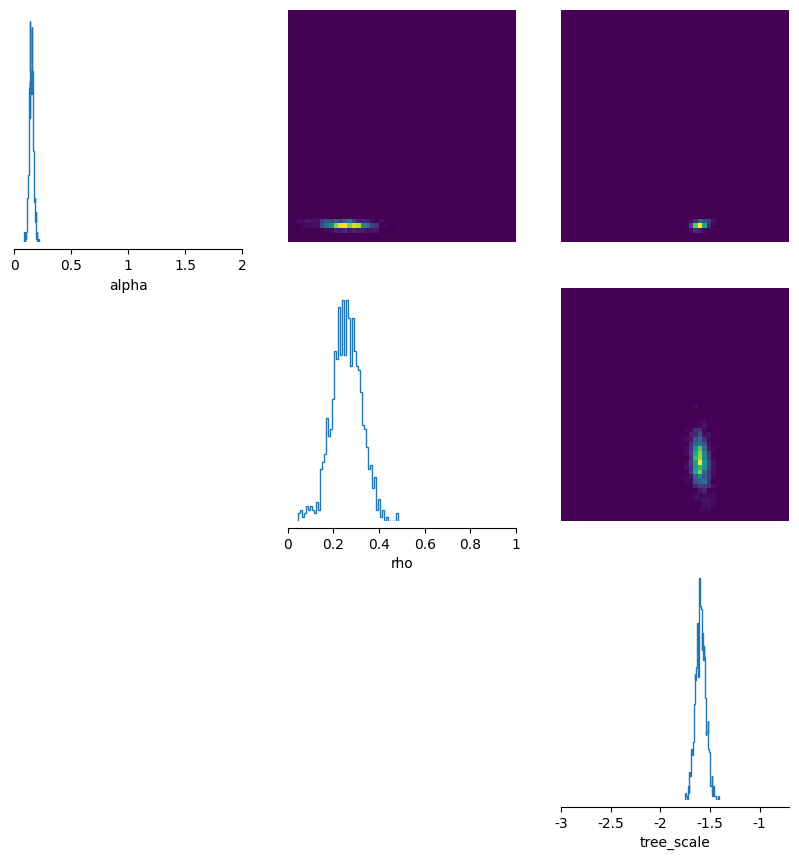

In [9]:

_ = pairplot(samples.numpy(),
              limits=[[0, 2], [0, 1], [np.log10(0.001), np.log10(0.2)]],
              labels=["alpha", "rho", "tree_scale"], show_titles=True)

In [18]:
# test accuracy of model on a new simulation
true_parameters = prior_dist.sample((200,))
infered_params = []

for i in true_parameters:
    print("Testing on parameters (alpha, rho, tree_scale):", i)
    features_test = simulate(i.unsqueeze(0))
    posterior_samples_test = posterior.sample((1000,), x=features_test, show_progress_bars=False)
    infered_params.append(posterior_samples_test.median(dim=0).values)

infered_params = torch.stack(infered_params)


Testing on parameters (alpha, rho, tree_scale): tensor([ 1.3720,  0.0608, -1.8313])
Testing on parameters (alpha, rho, tree_scale): tensor([ 0.7719,  0.1948, -2.7191])
Testing on parameters (alpha, rho, tree_scale): tensor([ 0.0691,  0.5226, -1.7325])
Testing on parameters (alpha, rho, tree_scale): tensor([ 1.7577,  0.7586, -2.6891])
Testing on parameters (alpha, rho, tree_scale): tensor([ 1.7346,  0.2043, -1.8056])
Testing on parameters (alpha, rho, tree_scale): tensor([ 1.1925,  0.3755, -2.2385])
Testing on parameters (alpha, rho, tree_scale): tensor([ 0.3408,  0.7932, -1.6688])
Testing on parameters (alpha, rho, tree_scale): tensor([ 1.9059,  0.8247, -1.8956])
Testing on parameters (alpha, rho, tree_scale): tensor([ 0.2229,  0.1387, -1.6393])
Testing on parameters (alpha, rho, tree_scale): tensor([ 1.4240,  0.1705, -2.9754])
Testing on parameters (alpha, rho, tree_scale): tensor([ 1.2066,  0.4387, -2.0493])
Testing on parameters (alpha, rho, tree_scale): tensor([ 0.4253,  0.3175, -1

In [19]:
# compute R^2 between true parameters (theta_test) and posterior samples median
# fore each parameter (alpha, rho, tree_scale)

R2_alpha = 1 - torch.sum((infered_params[:, 0] - true_parameters[:, 0]) ** 2) / torch.sum((true_parameters[:, 0] - true_parameters[:, 0].median()) ** 2)
R2_rho = 1 - torch.sum((infered_params[:, 1] - true_parameters[:, 1]) ** 2) / torch.sum((true_parameters[:, 1] - true_parameters[:, 1].median()) ** 2)
R2_tree_scale = 1 - torch.sum((infered_params[:, 2] - true_parameters[:, 2]) ** 2) / torch.sum((true_parameters[:, 2] - true_parameters[:, 2].median()) ** 2)

print("Test set R^2 (alpha):", R2_alpha)
print("Test set R^2 (rho):", R2_rho)
print("Test set R^2 (tree_scale):", R2_tree_scale)


Test set R^2 (alpha): tensor(0.7446)
Test set R^2 (rho): tensor(0.8397)
Test set R^2 (tree_scale): tensor(0.9892)


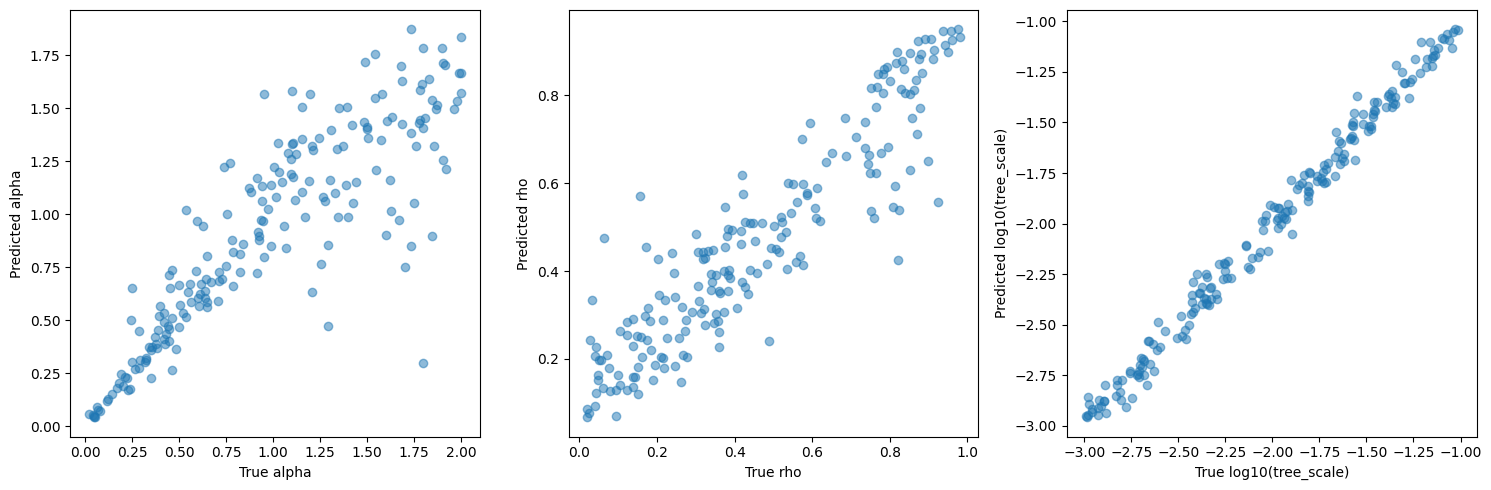

In [20]:
# scatter plot of true vs predicted parameters for test set
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.scatter(true_parameters[:, 0].numpy(), infered_params[:, 0].numpy(), alpha=0.5)
plt.xlabel("True alpha")
plt.ylabel("Predicted alpha")
plt.subplot(1, 3, 2)
plt.scatter(true_parameters[:, 1].numpy(), infered_params[:, 1].numpy(), alpha=0.5)
plt.xlabel("True rho")
plt.ylabel("Predicted rho")
plt.subplot(1, 3, 3)
plt.scatter(true_parameters[:, 2].numpy(), infered_params[:, 2].numpy(), alpha=0.5)
plt.xlabel("True log10(tree_scale)")
plt.ylabel("Predicted log10(tree_scale)")
plt.tight_layout()
plt.show()

[[ 1.31718496e-01  2.03456921e-03  9.19171757e-01]
 [-1.21408257e-01 -1.16277511e-02  8.77376070e-01]
 [-1.74278983e-01 -7.96979345e-03  9.38635386e-01]
 [-1.39345923e-01  5.44646788e-01  6.81683807e-01]
 [-2.00310435e-01 -1.25029818e-03 -8.73211939e-01]
 [-1.54951235e-01  2.05656445e-03 -9.12940270e-01]
 [-6.05136426e-01 -2.04850823e-02 -4.26889263e-01]
 [ 2.49641881e-01  2.67279136e-02 -6.86694379e-02]
 [ 6.83605131e-02 -4.18323653e-03 -8.71256131e-01]
 [ 1.74970273e-01 -1.73094311e-03 -1.49066094e-01]
 [ 1.32002635e-01  1.18616715e-02  5.50232015e-01]
 [ 8.57957229e-02 -4.20543004e-03  6.36709862e-01]
 [ 6.26165620e-02  1.26999568e-02  6.86821629e-01]
 [-6.28925828e-03  8.50316334e-03  6.65077231e-01]
 [-1.09207091e-01  1.29406577e-02  6.27346937e-01]
 [-2.23880649e-01  1.14769909e-02  5.85375879e-01]
 [-3.15216256e-01 -7.86395602e-03  4.82926223e-01]
 [-5.57188252e-02  5.99057217e-01  5.95077180e-01]
 [-2.67495795e-02  5.79069718e-01  5.51654468e-01]
 [ 9.19583873e-04  5.46461751e-

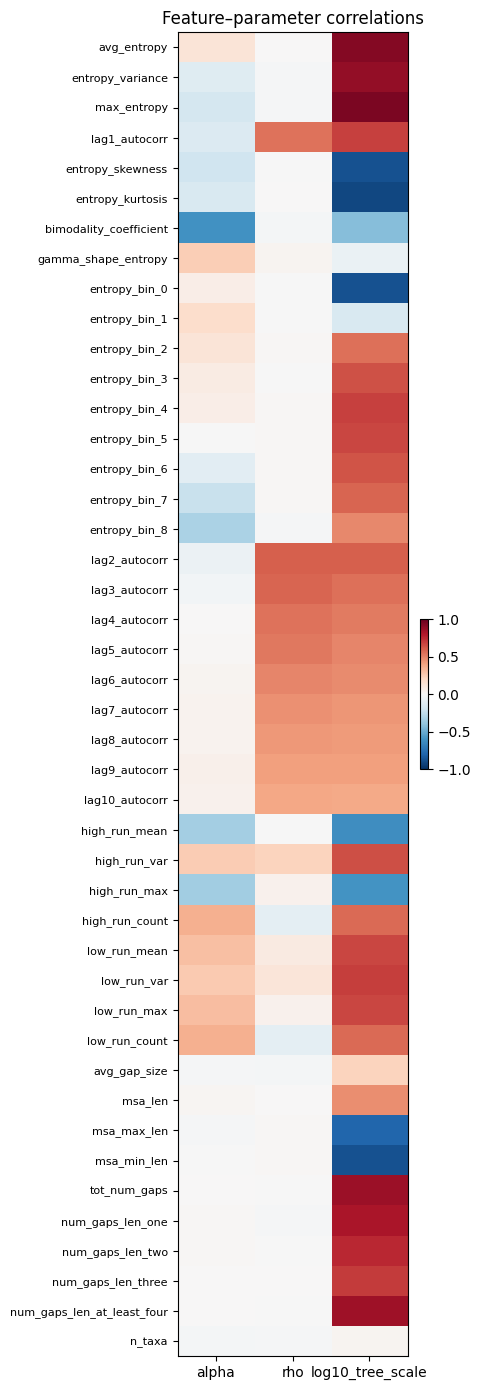

In [21]:
import numpy as np
import matplotlib.pyplot as plt

FEATURE_NAMES = [
    'avg_entropy', 'entropy_variance', 'max_entropy', 'lag1_autocorr',
    'entropy_skewness', 'entropy_kurtosis', 'bimodality_coefficient', 'gamma_shape_entropy',
    'entropy_bin_0', 'entropy_bin_1', 'entropy_bin_2', 'entropy_bin_3', 'entropy_bin_4',
    'entropy_bin_5', 'entropy_bin_6', 'entropy_bin_7', 'entropy_bin_8',
    'lag2_autocorr', 'lag3_autocorr', 'lag4_autocorr', 'lag5_autocorr', 'lag6_autocorr',
    'lag7_autocorr', 'lag8_autocorr', 'lag9_autocorr', 'lag10_autocorr',
    'high_run_mean', 'high_run_var', 'high_run_max', 'high_run_count',
    'low_run_mean',  'low_run_var',  'low_run_max',  'low_run_count',
    'avg_gap_size', 'msa_len', 'msa_max_len', 'msa_min_len', 'tot_num_gaps',
    'num_gaps_len_one', 'num_gaps_len_two', 'num_gaps_len_three', 'num_gaps_len_at_least_four',
    'n_taxa'
]
PARAM_NAMES = ['alpha', 'rho', 'log10_tree_scale']

F = features.numpy()
T = thetas.numpy()
# add new features and parameters from new_thetas and new_features

corr = np.array([[np.corrcoef(F[:, i], T[:, j])[0, 1]
                  for j in range(3)]
                 for i in range(len(FEATURE_NAMES))])
print(corr)
fig, ax = plt.subplots(figsize=(5, 14))
im = ax.imshow(corr, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(PARAM_NAMES)
ax.set_yticks(range(len(FEATURE_NAMES))); ax.set_yticklabels(FEATURE_NAMES, fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.03)
plt.title('Feature–parameter correlations')
plt.tight_layout()
plt.show()

In [22]:
empirical_MSA = """
>Sus_scrofa
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPYALGQENQDPR--LVQK--VSI--Q-RPLV-DSAGPRPKATRQTDPSEKL-VGSTQLRNPLKELRPSPGGQNVD--PRPPT-QTEA-SGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQDARASAYLAPRTPIHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PPS-HLSTRPRFQELRRETGG-GL-T-SVSQASGLLAKTPVQP------EGEH-EIVTHSD-EGGGGPLGLAQRVPLKETREIPHTKDGRDSCPMPS------PGRVVPPAVAR--PSPFGRAQRVPSPGP----TSYS-VLRRLAFRPK--TQFTPLPSASRV-QQA--RWLSG----LSPQPC--PEEPAVPWEQIAVRLFDQESCMRLQEGP-GKPPPVSTPHPSRTPSLQEI-KMQ--RISILQQLLRQEVEGLAGGQCAP-LNGGS-SLDMAELQPLLAEISRTLNAPESNNSGAFQPPRPLHPSA-MPEPCLLEACGE----------------------------------------------------------------------------------------------------------------------------------------------------------EPCPEAEPG-----------------------PPESCPRREPGISEP--------------------------------------STQEQLE----------------------------------------------------------------------------------------------LEPCPP-GAPRPLQACPLGQ-TRPAEPSPK--VET--------ERAPQSPESSLQP-SCGQRAPATTSLTFSSQRPLCASPPIHSLQSLKPPTGQADPHNLAPRTLALRQRLRACLSAIHCFHEARLDDECAFYTSRAPGLTRVCPNPVATLLEWQDA-SFIPVSSAA--PQDSPS
>Cavia_porcellus
MTTIQATKDPLLR---DPTPSKIPVRSRRRPPFLTVKPSAQDQENQDPR--LMEKSQLSI--Q-RNFV-DSAGPSSKATHQTEKSQRS-MAITQLRNPLEELRPSPGEQNSG--LGPPP-QTEA-PGPIEFVADPVALATILSGEGVKSCPMGRQSSLAQRVLVR-ESQGGT-IRRGQVSRASAYLAPRTPMHQLGPARASCFSRLEGSGPRGLTLCPQRLKAL--ALPSG--SF-HASTRPHLQELRRETSG-K--T-SVSQVSGLLLETPAQP------E-EH-ERIPHSD-EGGGALLGLAQRVPLRET---AHPRD---------------PGRVVPPSVTH--PSPFGRAQRVPSPGI------------RLAIRPK--TQFT--PSTPRV-QQA--QWLSD----LTPQSC--PEELALPWEQIAVRLFDQDSGVRLQEQS-GK-PAVASPHPNGALNFQEL-KMQ--RISILQQLLRQEVEGLAVDKYAH-LNGSC-SLDMAELQPLLAEISRTLNAPK-HNSGTSHLPELSQHSK-LPEPCPSEECG-----------------------QPCSG-EP-------------------------------------------------------------------------------------------------------------------------DVIQPCPPMEPG-----------------------PPESCSEVRPETPES--------------------------------------PSQKQPE----------------------------------------------------------------------------------------------AEPCPP-VEPGPLQPSPQGQ-TVSEEACPT--VGL-GT----CCLEPKCLEASPWR-CCSQRAAATTSLTFSSQRPLCASPPICSLQSTRPLTGQAGPSSLAPQTLALRQRLKACLTAIHCSHEARLDDECAFYTSRVPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--SQSSPS
>Nannospalax_galili
MTTLQTTKDPRLR-GVHPTPSKIPVLSQRCPEFSTVKPCSLDQENQDPR--LVQKPPLGT--Q-RSLV-DPAGLRSTVLHQTEKSQRL-MG-TQPRNPLEELTPSPGVQNVG--FGHPP-QTEA-TGAIEFVADPAALATILSGEGVKSCPLGRQSSLAQRVLVR-GNKGGT-IRRGQSARSSAYMAPRTPIHRLDPARASCFSRLEGPGPRGQTLCPQRLEAL--NPPSG-LAF-HPSTRLSLQELRRETCG-S--T-SVIQASRLHPETPAQP------EGEH-ESVPHSD-EGGGALLGLAQRVPLRETQVIMHTRGSSESLPMPS---------VMPP-VIR--PSPFGQAQRVPSPGL----NSYS-SLRRFAIRPK--TQFTPIRSAPRV-QKA--QWLRG----LSPHSC--PEEPPLPWEQIAVRLFDQDSCITLQEGS-GK-LPVASPHPNKTPNFQEL-KVQ--RISILQQLLRHEVEGLVVDKCAP-LNGGS-ALDMTELQPLLATISRTLNVPK-HNSGTSHLPGLSKCSE-LPELCLAEECE-----------------------QPCPGDEG-------------------------------------------------------------------------------------------------------------------------KVAQPCPPTEPE--------------------------------LELSEP--------------------------------------S-QEQPE----------------------------------------------------------------------------------------------LESSPP-SLP-----SPQGQ-AGPPEACPR--IEL-RASAA-HFLEARSPESSPLP-SCSQGPPATTSLTFSSQSPLCASLPIHSFQSLRPQTGQSGPSSLAPRTLALRQRLKACLAAIHCSHEARLDDECAFYTSRTPGPTRVCTNPVAMLLEWQDA-CFIPVGSVV--PQGSPS
>Acomys_russatus
MTTLQTRKDPHLR-GVSPTPSKIPVLSQRCPDSPSVKSCPLDQENQDPR--LAQKPPL-----------DTAGLRPKTLHQTEKSQKL--GTTQIRNPLGEIKPRSGGSN--------P-QTEA-TGAIEFVADPAALATILSGEGVKSCPLGFRSSLAQRVLVR-GSKGGT-TRRGQSARCSAYLAPRTPVHQLDPARASCFSRLEGPGPRDRTLC----EAS--NQPSG-PSF-YPSAHPGLQELRRETCG----T-SASQAPRLFPKTPVHP-------GEQ-EAAPHAD-GEGKALLGLAKRVLVRES--PTHTR------------------------------------------------TAYS-SLKRCTPRPK--TQLTPLRSVPRA-QQA--QWLSG---HLSPHTS--PEEPALPWEQIAVRLFEQESCITLQKGS-GK-APVASTHSNRTSNHQEI-KMQ--RISILQQLLRKEVEGLAADRRAP-LNGAS-ALELTELQPLMAEVSRTLSQAS--------LLGLSKHSG-GTEPLPAEGCEEPQP--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------EPCPP-ALPGPLLPSCQGQ-SGPPEACPS--IEL-GASAA-CAVEGRSPECIPKS-CCSQGPPATTSLTFVSQSPLCASPPICSLQASRSPTGHSGPHSLVPRTLALRQHLQACLTALHCFHESRLDDECAFYTSRTPGPTRICTNPVATMLDWQDT-HFIPVGSVV--PQDSPA
>Cercocebus_atys
MTTRQATRDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCALDQENQDPR--WLQKPPLNI--Q-RPLV-DSAGPRPKAKHQAETSQRL-VGIPQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQSSLAKRVLVR-GSQGGT-TQRGQGVPASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EVVTRSD-EGSVASLGLAQRVPLRENREMTHTRDSRDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VWRRLTIQPK--TRFTPMPSTPRV-QQA--RWLSG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPNLQEV-KIQ--RIGILQQLLRQEIEGLVGGQCAP-LNGGS-SLDMVELQPLLTEISRNLNATE-HNSGTSHLPGLLKCSG-LPKPCLPEECG-----------------------QPCPPAEP----------------------EVPEPCPPAEPRP------------------------------------------------------------------PESCCRSKPEIPEPSRQEQLEVPEPCPPAEPR-----------------------PPESCCRSEPEIPEP--------------------------------------SQQEQLE----------------------------------------------------------------------------------------------PEPCSP-AEPSPLQPSTQGQ-SGPPEPYPR--VEL-GASEP-CTLEHISPESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRTPAGQAGLSSLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGS-A--PRGSPS
>Homo_sapiens
MTTRQATKDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCAVDQENQDPR--WVQKPPLNI--Q-RPLV-DSAGPRPKARHQAETSQRL-VGISQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGT-TQRVQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGER-EVVTHSD-EGGVASLGLAQRVPLRENREMSHTRDSHDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRRLTVQPK--TRFTPMPSTPRV-QQA--QWLRG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPSLQEV-KIQ--RIGILQQLLRQEVEGLVGGQCVP-LNGGS-SLDMVELQPLLTEISRTLNATE-HNSGTSHLPGLLKHSG-LPKPCLPEECG-----------------------QPCPPAEP----------------------EVPEPYPPAEPRP------------------------------------------------------------------LESCCRSEPEIPESSRQEQLEVPEPCPPAEPR-----------------------PLESYCRIEPEIPES--------------------------------------SRQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPGPLQPSTQGQ-SGPPGPCPR--VEL-GASEP-CTLEHRSLESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRPPAGQAGLSNLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQGSPX
>Pan_troglodytes
MTTRQATKDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCAVDQENQDPR--WVQKPPLNI--Q-RPLV-DSAGPRPKARHQAETSQRL-VGITQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGER-EVVTHSD-EGGVASLGLAQRVPLRENREMSHTRDSHDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRRLTVQPK--TRFTPMPSTPRV-QQA--QWLRG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPSLQEV-KIQ--RIGILQQLLRQEVEGLVGGQCVP-LNGGS-SLDMVELQPLLTEISRTLNATE-HNSGTSHLPGLLKHSG-LPKPCLPEECG-----------------------QPCPPAEP----------------------EVPEPYPPAEPRP------------------------------------------------------------------LESCCRSEPEIPESSHQEQLEVPEPCPPAEPR-----------------------PLESYCRSEPEIPES--------------------------------------SRQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPGPLQPSTQGQ-SGPPGPCPR--VEL-GASEP-CTLEHRSLESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRPPAGQAGLSNLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQGSPX
>Pan_paniscus
MTTRQATKDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCAVDQENQDPR--WVQKPPLNI--Q-RPLV-DSAGPRPKARHQAETSQRL-VGITQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGER-EVVTHSD-EGGVASLGLAQRVPLRENREMSHTRDSHDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRRLTVQPK--TRFTPMPSTPRV-QQA--QWLRG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPSLQEV-KIQ--RIGILQQLLRQEVEGLVGGQCVP-LNGGS-SLDMVELQPLLTEISRTLNATE-HNSGTSHLPGLLKHSG-LPKPCLPEECG-----------------------QPCPPAEPGPPEAFCRSEPEIPEPSLQEQLEVPEPYPPAEPRP----------------------------------------------------------------------------------QEQLEVPEPCPPAEPR-----------------------PLESYCRSEPEIPES--------------------------------------SRQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPGPLQPSTQGQ-SGPPGPCPR--VEL-GASEP-CTLEHRSLESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRPPAGQAGLSNLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCINPVATLLEWQDA-CFIPVGSAA--PQGSPX
>Vulpes_vulpes
MPTLQATKDPLPR-GVSPTPSKIPVRSQRRPPLPTVKSCVLDQENQDPK--LVQK--LSI--Q-CP-V-DSAGPRPKVTHQTEKSERS-LGSTQLRNPLEELRPSPGGQNVG--PKPPS-QTEA-PGTVEFVADPTALATILSGEGIKSCLLGRQPSLAQRILIR-GSQGGT-TRRGQGARASAYLAPRTPAHRLDPTRASCFSRLEGPGPRSRTLCSQRLEAL--IPPSG-PSF-HPSTHPRFQELRRVTGG-S--T-LVSQTSGLLLETPVQP------EGEH-EVVTRSD-EGGGGPLGLAQRVPLR---ERTHTRDTSASHLIPS------PGHGGPPSIKH--PSPFGQAQRVPSPGP----TSYS-VLRRLAIRPQ--TQFTPILSGPRV-QQA--PCLTG----LSPQSC--PEEPALPWEQIAVRLFDQESCRKVQEGP-GN-PPVATPHPGTTPTLQEL-KLQ--RINILQQLLRQEVEGLAGDKCAP-HNGGS-SLDMVELQPLLAEVSRTLNAPE-HNAGDLHLPGLSQHSG-LPEPCLPEECE-----------------------QPCPEAKL-------------------------------------------------------------------------------------------------------------------------EIAQSCPPTEPG-----------------------PPESGHRREPGMLGP--------------------------------------SAQEEPE----------------------------------------------------------------------------------------------SEPCPP-VEPGCLQVDSHRQ-TGLLEASPR--IEP-GASEA-GPLEPRSPEASPQP-CCRQWTPATTSLTFSSQRPLCASPPIHSLQSLRPPTGQAGPSGLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGSSRVCTNPVATLLEWQDA------------------
>Canis_lupus_dingo
MPTLQATKDPLPR-GVSPTPSKIPVRSQRRPPLPTVKSCVLDQENQDPK--LVQK--FSI--Q-CP-V-DSAGPRPKVTHQTEKSERS-LGSTQLRNPLEELRPSPGVQNVG--PKPPP-QTEA-PGTVEFVADPAALATILSGEGVKSCLLGRQPSLAQRILVR-GSQGGT-TRRGQGARASAYLAPRTPAHRLDPTRASCFSRLEGPGPRSRTLCSQRLEAL--IPPSG-PSF-HPSTHPSFQELRRVTGG-S--T-SVSQTSGLLLETPVQP------EGEH-EVVTRSD-EGGGGPLGLAQRVPLR---ERTHTRDTSASHLIPS------PGHGGPPSISH--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPQ--TQFTPILSGPRV-QQA--PCLTG----LSPQSC--PEEPALPWEQIAVRLFDQESCRKVQEGP-GN-PPVATPHPGTTPTLQEL-KLQ--RINILQQLLRKEVEGLAGDKCAP-HNGGS-SLDMVELQPLLAEVSRTLNAPE-HNAGDLHLPGLSQHSG-LPEPCLPEECE-----------------------QPCPEAKL-------------------------------------------------------------------------------------------------------------------------EIAQSCPPAEPG-----------------------PSESGHRREPGMPGP--------------------------------------SAQEEPE----------------------------------------------------------------------------------------------SEPCPP-VEPGCLQVDSHRQ-IGLLEASPR--IEP-GASEA-GPLEPRSPEASPQP-CCRQWTPATTSLTFSSQRPLCASPPIHSLQSLRPPTGQAGPSGLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGSPRVCTNPVATLLEWQDA-CFIPVGPAA--PQDSLS
>Vulpes_lagopus
MPTLQATKDPLPR-GVSPTPSKIPVRSQRRPPLPTVKSCILDQENQDPK--LVQK--LSI--Q-CH-V-DSAGPRPKVTHQTEKSERS-LGSTQLRNPLEELRPSPGGQNVG--PKPPS-QTEA-PGTVEFVADPAALATILSGEGIKSCLLGRQPSLAQRILIR-GSQGGT-TRRGQGARASAYLAPRTPAHRLDPTRASCFSRLEGPGPRNRTLCSQRLEAL--IPPSG-PSF-HPSTHPHFQELRRVTGG-S--T-LVSQTSGLLLDTPVQP------EGEH-EVVTRSD-EGGGGPLGLAQRVPLR---ERTHTRDTSASHLIPS------PGHGGPPSIKH--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPQ--TQFTPILSGPRV-QQA--PCLTG----LSPQSC--PEEPALPWEQIAVRLFDQETCRKVQEGP-GN-PPVATPHPGTTPTLQEL-KLQ--RINILQQLLRQEVEGLAGDKCAP-HNGGS-SLDMVELQPLLAEVSRTLNAPE-HNTGDLHLPGLSQHSG-LPEPCLPEERE-----------------------QPCPEAKL-------------------------------------------------------------------------------------------------------------------------EIAQSCPPAEPG-----------------------PPESGHRREPGMPGP--------------------------------------SAQEEPE----------------------------------------------------------------------------------------------SEPCPP-VEPGCLQVDSHRQ-TGLLDASPR--IEP-GASEA-GPLEPRSPEASPQP-CCRQWTPATTSLTFSSQRPLCASPPIHSLQSLRPPTGQAGPSGLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGSPRVCTNPVATLLEWQDA-CFIPVGPAA--PQDSLS
>Meles_meles
MTTLQATKDPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--PN----------DSACPRPKVTHQTEKSERS-VGSTQLRNPLEELRPSPGGQNAG--PRHPP-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGI-TRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLEAL--IPPSG-PSF-HPSAHPSFQELRRMTGG-G--T-SVSQTSGLLLETPVPP------EEEH-EVVTCSD-EGGGGPLGLAQRVPLR---EITHTRDNSASHLISS------PGRVVPPSITH--PSPFGRAQRIPSPGP----PSYS-VLRRLAIRPK--TQFTPIRAAPRV-QQA--QGLSG----LSPQLC--PEEPALPWEQIAVRLFDQESCTRVQEGP-GK-PPVA---------LQEL-KMQ--RISILQELLRQEVEGLAGGKCAP-LNGGS-SLEMVELQPLLAEISRTRNAPE-QNSGALHLPGLFQHPG-LPEPRAPEECG-----------------------QPCPGAKP-------------------------------------------------------------------------------------------------------------------------EAAQPCLPAEPG-----------------------SPESSHSREPGIPEP--------------------------------------SVQEQPV----------------------------------------------------------------------------------------------SEPCPP-VEPGHLQADSHRH-TGLLEPSPR--IEP-GASEV-CFPEPRSPESSPQP-CHSQWAPETTTLIFSSQHPLCASPPIHSLQSLRPPTDQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPSRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSLS
>Enhydra_lutris_kenyoni
MTTLQATKDPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--PN----------DSAGPGPKVTHQTEKSERS-VGSTQLRNPLEELRPSPGGQNAG--PRHPP-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-TRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLEAL--IPPSG-PSF-HPSAHPSFQELRRVTGG-S--T-SVSQTSGLLLETPVPP------EGEH-EVVTRSD-EGGGGPLGLAQRVPLR---EITHTRDNSASHLISS------PGRVVPPSITH--PSPFGRAQRIPSPGP-----SYS-VLRRLAIRPK--TQFTPIRAAPRV-QQA--QGLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCTRVQEGP-GK-PPVAA-DPSTPATLQEL-KMQ--RISILQELLRQEVEGLAGGKCAP-LNGGS-SLEMVELQPLLAEISRTRNAPE-QNSGALHLPGLFQRPG-LPEPCVPEECG-----------------------QPCPGAKP-------------------------------------------------------------------------------------------------------------------------EAAQPCLAAEPE-----------------------SPESSHSREPEIPEP--------------------------------------SVQEQPV----------------------------------------------------------------------------------------------SEPCPP-VEPGHLQADSHRH-AGLLEPSPR--IEP-GASEA-CFPEP-SLESSPQP-CRSQWAPETTTLIFSSQHPLCASPPIHSLQSLRPPTGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGSSRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSLS
>Mustela_erminea
MTTFQGTKDPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--PN----------DSAGPRPKVTHQTEKSERS-VGSTQLRNPLEELRPSPGGQNAG--PRHPP-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-TRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLEAL--IPPSG-PSF-HPSAHPSFQELRRVTGG-S--T-SVSQTSGLLLETPVPP------EGEH-EVVTRSD-EGGGGPLGLAQRVPLR---EITHTRDNSASHLTSS------PGRAVPPSITH--PSPFGRAQRIPSPGP----PSYS-VLRRLAIRPK--TQFTPIRAAPRV-QQA--QGLTG----LSPQSC--PEEPALPWEQIAVRLFDQESCTRVQEGP-GK-PPVAA-DPSTPATLQEL-KMQ--RISILQELLRQEVEGLAGGKCAS-LNGGS-SLEMVEFQPLLAEISRTRNAPE-QNSGDLHLPGLFQRPG-LPEPYVPEECG-----------------------QPCPGAKP-------------------------------------------------------------------------------------------------------------------------EAAQPCLAAEPG-----------------------SPESSHSREPGIPEP--------------------------------------SVQEQPV----------------------------------------------------------------------------------------------SEPCPA-VEPGHLQADSQRH-TGLLEPSPR--IEP-GASEA-CFLEPRSPESSPQP-CRSQWAPETTTLIFSSQHPLCASPPIHSLQSLRSPTGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPARVCTNPVATLLEWQDA-CFIPVGSAA--PX----
>Mustela_putorius_furo
MTTFQGRKDPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--PN----------DSAGPRPKVTHQTEKSERS-VGSTQLRNPLEELRPSPGGQNAG--PGHPP-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-TRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLEAL--IPPSG-PSF-HPSAHPSFQELRRVTGG-S--T-SVSQTSGLLLETPVPP------EGEH-EVVTRSD-EGGGGPLGLAQRVPLR---EISHTRDNSASHLTSS------PGRVVPPSITH--PSPFGRAQRIPSPGP----PSYS-VLRRLAIRPK--TQFTPIQAAPRV-QKA--QGLTG----LSPQSC--PEEPALPWEQIAVRLFDQESCTRVQEGP-GK-PPVAA-DPSTPATLQEL-KMQ--RISILQELLRQEVEGLAGGKCAS-LNGGS-SLEMVELQPLLAEISRTRNAPE-QNSGALHLPGLFQHPG-LPEPYVPEECG-----------------------QPCPGAKP-------------------------------------------------------------------------------------------------------------------------EAAQPCLAAEPG-----------------------SPESSHSREPGIPEP--------------------------------------SVQEQPV----------------------------------------------------------------------------------------------SEPCPP-VEPGHLQADSQRH-TGLLEPSPR--IEP-GASKA-CFPEPRSPESSPQP-CRSQWAPETTTLIFSSQHPLCASPPIHSLQSLRSPTGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPARVCTNPVATLLEWQDA-CFIPVGSAA--PX----
>Neogale_vison
MTTFQATKDPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--PN----------NSAGPRPKVTRQTEKSERS-VGSTPLRNPLEELRSSPGGQNAG--PRHPH-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGN-THRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLEAL--IPPSR-PSF-HPSAHPSFQELRRMTGG-G--T-SVSQTSGLLLETPVPP------EGEH-EVVTRSD-EGGGGPLGLAQRIPLS---EITHTRDNSASHLTSS------PGRVVPPSITH--PSPFGRAQRIPSPGP----PSYS-VLRRLAIRPK--TQFTPIRAAPRV-QQA--QGLSG----LSPQSC--REEPALPWEQIAVRLFDQESCTRVQERP-GK-PPVA---------LQEL-KMQ--RISILQELLRQEVEGLAGGKCAS-LNGGS-SLEMVELQPLLAEISRTQNAPE-QNSGALHLPGLFQHPG-LPEPYVPEECG-----------------------QPCPGAKP-------------------------------------------------------------------------------------------------------------------------EAAQPCLAAEPG-----------------------SPESSHSREPGIPEP--------------------------------------SVQEQPM----------------------------------------------------------------------------------------------SEPCPP-VEPGHLQADSQRH-TGLPEPSPR--IEP-GASEA-CFPEPRSPESSPQP-CRRQWAPETTTLIFSSQHPLCASPPIHSLQSLRPPTGQAGPSSLAPRTLALRQRLKSCLTAIHCFHEARLDDECAFYTSRAPGPARVCTNPVATLLEWQDA-CFIPVGSAA--PQDSLS
>Lontra_canadensis
MTTLQATKDPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--PN----------DSAGPGPKVTHQTEKSERS-VGSTQLRNPLEELRPSPGGQNAG--PRHPP-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-TRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLEAL--IPPSG-PSF-HPSAHPSFLELRRVTGG-S--T-SVSQTSGLLLETPV--------------------------------------------------SHLISS------PGRVVPPSITH--PSPFGRAQRIPSPGP-----SYS-VLRRLAIRPK--TQFTPIRATPRV-QQA--QGLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCTIVQEGP-RK-APVAA-DPSTPATLQEL-KMQ--RISILQELLRQEVEGLAGGKCAP-LNGGS-SLEMVELQPLLAEISRTRNAPE-QNSGALHLPGLFQRPG-LPEPCVPEECG-----------------------QPCPEAKP-------------------------------------------------------------------------------------------------------------------------EAVQPCLAAEPG-----------------------SPESSHSREPGIPEP--------------------------------------SVQEQPV----------------------------------------------------------------------------------------------SEPCPP-VEPGHLQADSHRH-AGLLEPSPR--IEP-GASKA-CFLEPRSPESSPQP-CHSQWAPEITTLIFSSQHPLCASPPIHSLQSLRPPTGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGSARVCTNPVATLLEWQDA-CFIPVGSAA--PQDSLS
>Chinchilla_lanigera
MTTIQDSKDPLLR-GVSPTPSKIPVRSQRRPPFLAVKPSAEDQENQDPG--LVQKPQLST--Q-RTLV-DSAGPRSKATHQTEKSQKS-MAITQLRNPLEELRPSPGGQNAG--LGPPP-QTEA-PGPIEFVADPAALATILSGEGVKSCPMGRQSSLAQRVLIR-GSQGGA-IRRGQNARASAYLASRTPIHQPGPARASCFSRLEGSGPRGRTLCPERLQAL--VPPSG-PSF-HPSTRPSLQELRRETGG-S--TASVSQVSGLLLQTPVQP------E-EH-ESVPHSD-EEGGTLLGLAQRVPLGETRETAHPRDAHDSRLMAS------PGRVVPPSVTH--PSPFGRAQRVPSPGI----TSYS-LLRRLAIRPK--TQFT--PSTPRA-QRA--RWLSG----LTPQSC--PEEPALPWEQIAVRLFDQDSGVRLQEQP-GR-LAVTSPHP----NFQEL-KMQ--RISILQQLLRQEVEGLAVGKYAP-LTGGC-SLDMVELQPLLADISRTLNAPE-QNPGTSHLPGLPQHSE-QPEPCPPEDCR-----------------------QPCSGA---------------------------------------------------------------------------------------------------------------------------EVTQPYPPTEPG-----------------------PPESCCRARPETAEP--------------------------------------SSQEQPE----------------------------------------------------------------------------------------------AKPCPP-AEPAPLQPRPQGQ-SASQEACAR--VGL-GASDA-CYLEPECLESSPWS-CCSQGAPATTDLTFSSQRPLCASPPICSLQSPRPPIGQAGPGSLAPRTMALRQRLKACLTAIHCSHEARLDDECAFYTSRVPGPTRVCTNPVATVLEWQDA-GFIPVVSAA--PQSSPS
>Octodon_degus
MTTVQATKDPLLR-GVSPTPSKIPVRSKRCPPFLTVKPSSQDQENQDPG--LVQKPQLSI--Q-RTLV-DSAGPRSKATYQKEKSQKS-MAITQLRNPLEELRPSPGGQNAG--LKPPP-QTEA-PGPLEFVADPAALATILSGEGVKSYPLGRQSSLARRVLVR-GSQGCS-IRRGQGARASAYLAPRTPIHRLGPGRASCFSRLEGSGPQSQTLCPQRLETL--VLPSG-SSF-HSPTRPSLQELRRETGG-R--T-SVSHVSGLLLEIPVQP------E-EH-KNVLHSD-EGTEALLGLAQQVPLGETRERAHPRDAHDSQLVAS------PGRMAPP-VIH--SSPFGRAQRVPSPGI----TSYS-LLRRPTIRPK--SQFTPF--TPRL-QRA--QWLSG----FTPQSC--PEEPGLPWEQIAIRLFEQDSGANLQEQP-GK-------------NFQEL-KLQ--RIGILQQLLRQEVEGLAVSKCSP-LNGGC-SLNMVELQPLLAEISRTLNAPE-HNSGTSHLPGLSQHSE-LPEPCLPEECG-----------------------QLCSG-EP-------------------------------------------------------------------------------------------------------------------------AVTQLCPPTESG-----------------------PPESCSKARPETREP--------------------------------------SSQEQPE----------------------------------------------------------------------------------------------TEPCPP-AEPGPVQPQPQRQ-TASEEACRR--VIL-GTSDT-CSLEPKCLKSSPWH-CCGQGAPAATSLTFSSQHPLCASPPICSLQSPRPLIGQAGPSNLGPRTLALRQRLKACLTAIHCSHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVVSAA--PQSSPS
>Fukomys_damarensis
MTTIQATEDPLLR-GVSPTPSKIPVRCKRRPPFPTVKSSTQDQENQDPR--LVQKPPISI--Q-HTLV-DSEGTRSKGMQRTEKSQKW-TATTQLRNPLEELRPSPVAQNVG--LRPPP-PTVA-PGAIEFVADPAALATILSGEGVKSYPMGRQSSLAQRVLVR-GSQGGT-IRRGQGTQASVYVAPRTPIHQPGPARASCFSRLEGSGPRGRTLCPQRLQAL--VPPSR-SSF-HPSTRPSLQDLRRETGG-S--T-SVSQASGLRLETPVQP--------EH-ESVPHSG-EGGGALLGLAQRVPLRETKE--------DSHLMPS------PGRVVTPSATH--PSPFGRAQRVPSPGL----TSYS-LLRRLTIRPK--TQFT--PSTPRV-KQT--RWLSG----LTPQSC--PEESAVPWEKIAVRLFDQDSGVKLQEQP-GK-PAVASPHSYGTLNFQEL-KMQ--RINILQQLLRQEVEGLAAGKYAP-PNGGS-SLDMVELKPLLAEISRTLNVPD-HNSGTSHLPGLSQHSK-LPEPCPLEERG-----------------------QPCSGAEP-------------------------------------------------------------------------------------------------------------------------EVTQLCPPTEPG-----------------------PPEFCPKARPETPVP--------------------------------------SSQEQPE----------------------------------------------------------------------------------------------AEPCPS-VEPGLLQPRPQRQ-AVSEEACPR--VGL-RASEA-HSLEPKSLESSPWR-CCSQGAPATTSLTFCSQRPLCASPRICSLQSPRPPTGQAGRSSLAPGTLALRQRLKACLSAIHCSHEARLDDECAFYTSRVPGPTRICTNPVATVLEWQDA-CFIPVGSAA--PQSSPH
>Heterocephalus_glaber
MTTIQATKDPLLR-GVSPTPSKIPVRCQRRPPFPTVKSSTQDQENQDPR--LVQKPPLSI--Q-HTLV-DSAGGRSKAIHQTEKSQKL-MAITQLRNPLEELRPSHVGQNVG--LRPPP-QTEA-PGAIEFVADPAALATILSGEGVKSYPMGRQSSLAQRVLVR-GNQGGT-VRRGQGAWASVYVAPRTPIHQLGPARASCFSRLEGSGPRGQTFCPQ--------PSSR-SSF-HPSTRPSLQDLRREIGG-S--T-SVSQASGLHLETPVQP--------EH-ESVPHSD-EGGGALLGLAQRVPVRETRERIHTGDAQDSHLMPS-------GRVVPPSVTH--PSPFGRAQRVHSPGF----TSYS-LLRRLGIQPK--TQFT--PSTPRV-QQA--QWLSG----LTPQSC--TEEPALPWEQIAVRLFDQDSGVRLQEQP-GK-PAVASPHPYRTFNFQEL-KMQ--RISILQQLLRQEVEGLAVGKYAP-PNGDS-SLDMVEFHPLLAEISRTLKAPG-HNSGTSYLPGLSQHPE-LPEPCPPEECE-----------------------PPCFGAEP-------------------------------------------------------------------------------------------------------------------------EVTQPCPPAETG-----------------------PPESCSKARPGIPAP--------------------------------------SSREQPE----------------------------------------------------------------------------------------------AEPCPP-AESGLLQPRPQGQ-TASKKACPR--IEL-RASEA-HSLEPKSLESSPWR-CCSQGAPATT------------SPPICSLQSPRPPTGQAGPGQLAPRTLALRQRLKACLTAIHCSHEARLDDECAFYTSRVPGPTRVCTNPVATVLEWQDA-CFIPVGSAA--PQSSPY
>Orcinus_orca
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPR--LVQK--LSS--Q-RPLV-DSAGPRPKATHQTEQSERL-VGSTQLRNPLEELRPSPGRQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GNQGGT-IRRRQDARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSS-HPSAPPGFQELRRETGG-N--T-SVSQASGLLLETLVKP------EGEY-EVVTHSD-ERGGGPLGLAQRVPLKETREITHTKDGRDSCLMPS------PGQVIPPAITR--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TQFTPLPSAPRA-QQA--QWLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGIRLQEAP-GK-PPVSTPHPSRTPNLQEL-KLQ--RISILQQLLRQEVEGLADGKCAP-LHGGF-SLDVVELQPLLAEISRTLNAPE-NKSGAFHLPGMLQHSG-LPKPYLPEGCG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVALPCPPAEPG-----------------------PPESYHRRGPEISEP-------------------------------------------------------------------------------------------------------------------------------------------SEPCPL-GEPGPLQACPQGQ-TGLPEPSPR--VEP-GVSEA-CSLEPRSPESSPWS-CCSQWAPATTSLTFSSQRPLCASPPIHSLQSLKPPTGQAGPSNLAPRTLALRQRLKACLTAIHRFHEARLDDECAFYTSRAPGLTRVCTNPVATLLERQDAL-----------------
>Balaenoptera_acutorostrata_scammoni
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPR--LVQK--LSS--Q-RPLV-DSAGPRLKATRQTEQSERL-VGSTQLRNPLEELRPSPGRQNVG--PRPPL-QKEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GNQGGT-IRRGQDARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSS-HPSAPPRIQELRRETGG-N--T-SVSQASGLLLETLVQP------EGEY-EVVTHSD-ERGGGPLGLAQRVPLKETREITHTKDGRDSCLMRS------PGQVMPPAITR--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TQFTPLSSAPRV-QQA--QWLSG----LSPQPC--PEEPALPWEQIAVRLFDQESCIRLQEGP-GK-PPVSTPHCSRTPNLQEM-KMQ--RISILQQLLRQEVEGLAEGKCAP-LNGGS-SLDMVELQPLLAEISRTLNVPE-NKSGAFHLSGMLQHSG-LPKPYLPEGCG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVSLPCPPAEPG-----------------------PPESYHRRGPEISEL--------------------------------------STQEQPE----------------------------------------------------------------------------------------------SEPCPL-GEPGPLQACPQGQ-TGLPEPSPR--VEP-GVSEA-CSLEPRSPESSPWP-CCSQWAPATTSLTFSSQRPLCASPPIHSLQSLKPPTGQAGPSNLAPRTLALRQRLKACLTAIHHFHEVRLDDECAFYTSRAPGLTRVCTNPVATLLERQDA-CFIPVGS-A--PQDSPS
>Delphinapterus_leucas
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPR--LVQK--LSS--Q-RPLV-DSAGPRPKATHQTEQSERL-VGSIQLRNPLEELRPSPGRQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GNQGGT-IRRGQDARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSS-HPSAPPGFQELRRETGG-N--T-SVSQASGLLLETLVKP------EGEY-EVVTHSD-ERGGGPLGLAQRVPLKETREITHTKDGRDSCLMPS------PGQVIPPAITR--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TQFTPLPSAPRA-QQA--QWLSG----LSPHPC--PEEPALPWEQIAVRLFDQESGIRLQEGP-GK-PPVSTSHPSRTPNLQEL-KLQ--RISILQQLLRQEVEGLAEGKCAP-LNGGS-SLDMVELQPLLAEISRTLNAPE-NKSGAFHLPGMLQHSG-LPKPYLPEGCG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVALLCPPAEPG-----------------------PPESYHRRGPEISEP-------------------------------------------------------------------------------------------------------------------------------------------SEPCPL-GEPGPLQACPQGQ-TGLPEPSPR--VEP-GVSEA-CSREPRSPESSPWS-CCSQWAPATTSLTFSSQRPLCASPPIHSLQSLKPPTGQAGPSNLAPRTLALRQRLKACLTAIHRFHEARLDDECAFYTSRAPGLTRVCTNPVATLLEWQDA-CFIPVSSAA--PQDSPS
>Lipotes_vexillifer
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPR--LVQK--LSS--Q-RPLV-DSAGPRPKATHQTEQSERF-VGSTQLRNPLEELRPSPGRQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GNQGGA-IRRGQDARASAYSAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSS-HPS----FQELRRETGG-N--T-SVSQASGLLLETLVKP------EGEY-EVVTHSD-ERGGGPLGLAQRVPLKETREITHTKDGRDSCLMPS------PGQVIPPAITR--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TQFTPLPSAPRA-QQA--QWLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGIRLQEGP-GK-PPMSTPHPSRTPNLQEL-KMQ--RISILQQLLRQEVEGLAEGKCAP-LNGGS-SLDMVELQPLLAEISRTLNAPE-NKSGAFHLPGMLQHSG-PPKPYLPEGCG-----------------------EPCPAAEP-------------------------------------------------------------------------------------------------------------------------EVALPCPPAEPG-----------------------PPESYHRRGPEISEP-------------------------------------------------------------------------------------------------------------------------------------------SEPCPL-GEPGPLQACPQGQ-TGLPEPSPR--VEP-GVSEA-CSPEPRSPESSPWP-CCSQWAPATTSLTSSSQRPLCASPPIHSRQSLKPPTGQAGPSNLAPRTLALRQRLKACLTAIHRFHEARLDDECAFYTSRAPGLTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSPS
>Physeter_catodon
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPR--LVQK--LGS--Q-RPLV-DSAGPRPKATHQTEQSERL-VGSTQLRNPLEELRPSPGRQNVG--PGPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GNQGGT-IRRGQDARASAYLAPRTPTHRMDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSS-HPSAPPGFQELRRETGG-N--T-SVSQASGLLLETLVQP-------GEY-EVVTHSD-ERGGGPLGLAQRVPLKETRDITRTKDGRDSCLMPS------PGQVMPPAITR--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TQFTPLPSAPRA-QKA--QWLSG----LSPQPC--PEEPALPWEQIAVRLFDQESCVRLQEGP-GK-PPVSTPHPNRTPNLQEL-KMQ--RISILQQLLRQEVEGLAEGKCAP-LNGGS-SLDMVELQPLLAEISRTLNAPE-NKSGAFHLPEMLQHSG-LPKPYLPEACG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVALPCPPAEPE-----------------------PPESYHRRGPEISEP--------------------------------------STQEQPE----------------------------------------------------------------------------------------------SEPCPL-GEPEPLQACPQGQ-TGLPEPSPR--VEP-GVSEA-CSLEPRSPESIPRP-CCSQWAPATTSLTF-SQRPLCASPPIHSLQSLKPPTGQAGPSNLAPRTLALRQRLKACLTAIHRFHEARLDDECAFYTSRAPGLTRVCTNPVATLLEWQDA-CFIPVSSAA--PQDSPS
>Monodon_monoceros
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPR--LVQK--LSS--Q-RPLV-DSAGPRPKATHQTEQSERL-VGSTQLRNPLEELRPSPGRQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GNQGGT-IRRGQDARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSS-HPSAPPGFQELRRETGG-N--T-SVSQASGLLLETLVKP------EGEY-EVVTHSD-ERGGGPLGLAQRVPLKETREITHTKDGRDSCLMPS------PGQVIPPAITR--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TQFTPLPSAPRA-QQA--QWLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGIRLQEGP-GK-PPVSTSHPSRTPNLQEL-KLQ--RISILQQLLRQEVEGLAEGKCAP-LNGGS-SLDMVELQPLLAEISRTLNAPE-NKSGAFHLPGMLQHSG-LPKPYLPEGCG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVALPCPPAEPG-----------------------PPESYHRRGPEISEP-------------------------------------------------------------------------------------------------------------------------------------------SEPCPL-GEPGPLQACPQGQ-TGLPEPSPR--VEP-GVSEA-CSREPRSPESSPWS-CCSQWAPATTSLTFSSQRPLCASPPIHSLQSLKPPTGQAGPSNLAPRTLALRQRLKACLTAIHRFHEARLDDECAFYTSRAPGLTRVCTNPVATLLEWRDA-CFIPVSSAA--PQDSPS
>Neophocaena_asiaeorientalis_asiaeorientalis
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPR--LVQK--LSS--Q-RPLV-DSAGPRPKATHQTEQSERL-VGSTQLRNPLEELRPSPGRQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GNQGGT-IRRGQDARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSS-HPSAPPGFQELRRETGG-N--T-SVSQASGLLLETLVKP------EGEY-EVVTHSD-ERGGGPLGLAQRVPLKETREITHTKDGRDSCLMPS------PGQVIPPAITR--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TQFTPLPSAPRA-QQA--QWLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGVRLQEGP-GK-PPVSTPHPSRTPNLQEL-KLQ--RISILQQLLRQEVEGLAEGKCAP-LNGGS-SLDMVELQPLLAEISKTLNAPE-NKSGAFHLPGMLQHSG-LPKPYLPEGCG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVALPCPPAEPG-----------------------PPESYHRRGPEISEP-------------------------------------------------------------------------------------------------------------------------------------------SEPCSL-GEPGPLQACPQGQ-TGLPEPSPR--VEP-GVSEA-CSREPRSPESSPWS-CCSQWAPATTSLTFSSQRPLCASPPIHSLQSLKPPTGQAGPSNLAPRTLALRQRLKACLTAIHRFHEAQLDDECAFYTSRAPGLTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSPS
>Phocoena_sinus
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPR--LVQK--LSS--Q-RPLV-DSAGPRPKATHQTEQSERL-VGSTQLRNPLEELRPSPGRQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GNQGGT-IRRGQDARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSS-HPSAPPGFQELRRETGG-N--T-SVSQASGLLLETLVKP------EGEY-EVVTHSD-ERGGGPLGLAQRVPLKETREITHTKDGRDSCLMPS------PGQVIPPAITR--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TQFTPLPSAPRA-QQA--QWLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGVRLQEGP-GK-PPVSTPHPSRTSNLQEL-KLQ--RISILQQLLRQEVEGLAEGKCAP-LNGGS-SLDMVELQPLLAEISKTLNAPE-NKSGAFHLPGMLQHSG-LPKPYLPEGCG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVALPCPPAEPG-----------------------PPESYHRRGPEISEP-------------------------------------------------------------------------------------------------------------------------------------------SEPCPL-GEPGPLQACPQGQ-TGLPEPSPR--VEP-GVSEA-CSREPRSPESSPWS-CCSQWAPATTSLTFSSQRPLCASPPIHSLQSLKPPTGQAGPSNLAPRTLALRQRLKACLTAIHRFHEAQLDDECAFYTSRAPGLTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSPS
>Globicephala_melas
MTTLQTTKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPR--LVQK--LSS--Q-RPLV-DSAGPRPKATHQTEQSERL-VGSTQLRNPLEELRPSPGRQNVG--PRPPL-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GNQGGT-IRRRQDARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSS-HPSAPPGFQELRRETGG-N--T-SVSQASGLLLETLVKP------EGEY-EVVTHSD-ERGGGPLGLAQRVPLKETRETTHTKDGSDSCLMPS------PGQVIPPAITR--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TQFTPLPSAPRA-RQA--QWLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGIRLQEGP-GK-PPVSTPHPSRTPNLQEL-KLQ--RISILQQLLRQEVEGLVDGKCAP-LHGGS-SLDVVELQPLLAEISRTLNAPE-NKSGAFHLPGMLQHSG-LPKPYLPEGCG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVALPCPPAEPG-----------------------PPESYHRRGPEISEP-------------------------------------------------------------------------------------------------------------------------------------------SEPCPL-GEPGPLQACPQGQ-TGLPEPSPR--VEP-GVSEA-CSLEPRSPESSPWS-CCSQWAPATTSLTFSSQRPLCASPPIHSLQSLKPPTGQAGPSHLAPRTLALRQRLKACLTAIHHFHEARLDDECAFYTSRAPGLTRVCTNPVATLLERQDA-CFIPVGSAA--PQDSPS
>Tursiops_truncatus
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPR--LVQK--LSS--Q-RPLV-DSAGPRPKATHQTEQSERL-VGSTQLRNPLEELRPSPGRQNVG--PRPPL-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GNQGGT-IRRRQDARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSS-HPSAPPGFQELRRETGG-N--T-SVSQASGLLLETLVKP------EGEY-EVVTHSD-ERGGGPLGLAQRVPLKETRETTHTKDGRDSCLMPS------PGQVIPPAITR--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TQFTPLPSAPRA-RQA--QWLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGIRLQEGP-GK-PPVSTPHPSRTPNLQEL-KLQ--RISILQQLLRQEVEGLVDGKCAP-LHGGS-SLDVVELQPLLAEISRTLNAPE-NKSGAFHLPGMLQHSG-LPKPYLPEGCG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVALPCPPAEPG-----------------------PPESYHRRGPEISEP-------------------------------------------------------------------------------------------------------------------------------------------SEPCPL-GEPGPLQACPQGQ-TGLPEPSPR--VEP-GVSEA-CSLEPRSPESSPWS-CCSQWAPATTSLTFSSQRPLCASPPIHSLQSLKPPTGQAGPSNLAPRTLALRQRLKACLTAIHHFHEARLDDECAFYTSRAPGLTRVCTNPVATLLERQDA-CFIPVGSAA--PQDSPS
>Balaenoptera_musculus
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPR--LVQK--LSS--Q-RPLV-DSAGPRPKATRQTEQSERL-VGSTQLRNPLEELRPSPGRQNVG--ARPPL-QKEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GNQGGT-IRRGQDARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSS-HPSAPPRIQELRRETGG-N--T-SVSQASGLLLETLVQP------EGEY-EVVTHSD-ERGGGPLGLAQRVPLKETREITHTKDGRDSCLMRS------PGQVMPPAITR--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TQFTPLSSAPRV-QQA--QWLSG----LSPQPC--PEEPALPWEQIAVRLFDQESCIRLQEGP-GK-PPVSTPHCSRTPNLQEM-KMQ--RIGILQQLLRQEVEGLAEGKCAP-LNGGS-SLDMVELQPLLAEISRTLNVPE-NKSGAFHLSGMLQHSG-LPKPYLPEGCG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVSLPCPPAEPG-----------------------TPESYHRRGPEISEL--------------------------------------STQEQPE----------------------------------------------------------------------------------------------SEPCPL-GEPGPLQACPQGQ-RGLPEPSPR--VEP-GVSEA-CSLEPRSPESSPWP-CCSQWAPATTSLTFSSQRPLCASPPIHSLQSLKPPTGQAGPSNLAPRTLALRQRLKACLTAIHHFHEVRLDDECAFYTSRAPGLTRVCTNPVATLLERQDA-CFIPVGSAA--PQDSPS
>Lagenorhynchus_obliquidens
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQD----LVQK--LSS--Q-RPLV-DSAGPRPKATHQTEQSERL-VGSTRLRNPLEELRPSPGRQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GNQGGT-IRRRQDARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSS-HPSAPPGFQELRRETGG-N--T-SVSQASGLLLETLVKP------EGEY-EVVTHSD-ERGGGPLGLAQRVPLKETREITHTKDGRDSCLMPS------PGQVIPPAITR--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TQFTPLPSAPRA-QQA--RWLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGIRLQEAP-GK-PPVSTPHPSRTPNLQEL-KLQ--RINILQQLLRQEVEGLADGKCAP-LHGGS-SLDVVELQPLLAEISRTLNAPE-NKSGAFHLPGMLQHSG-LPKPYLPEGCG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVALPCPPAEPG-----------------------PPESYHRRGPEISEP-------------------------------------------------------------------------------------------------------------------------------------------SEPCPL-GEPGPLQACPQGQ-TGLPEPSPR--VEP-GVSEA-CSLEPRSPESSPWS-CCSQWAPATTSLTFSSQRPLCASPPIHSLQSLKPPTGQAGPSNLAPRTLALRQRLKACLTAIHRFHEARLDDECAFYTSRAPGLTRVCTNPVATLLERQDA-CFIPVGSAA--PQDSPS
>Camelus_bactrianus
MTTLQTTKDPLLR-SVSPTPSKIPVRSQRRPPLPTAKLCALDQENQDPR--LVQK--LSI--Q-PPLA-DSAGPRPKATLQTDQSEKS-VGSTQLRNPLEELRPSPGGQNVG--PRLPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-ARRGQHARASAYLAPRTPTHRLDPARASCFSRLEGPGPRSRTFCPQRLEAL--IPPSG-PSS-HPSARPHFQELRKETGG-S--T-SVSQASGLLREIPVQP------EGEH-EVVIHSD-EGGGGPLGLAKRVLLKETRETTHSRDGCGSCLMPS------PGRVVPPSVTR--PSPFGRAQRVPSPGP----TSYS-VLRRLAFRPK--TQFTPLPSAPRV-PQA--RWLSG----LSPQPC--PEEPALPWEQIAVRLFDQESCIRLPEGS-GK-PPMAT-HPNRTPNLQEL-KMQ--RISILQQLLRQEVEGLAEGKCAS-LSGGS-SLDMVELQPLLAEISRTLNAPE-HNPGSIHLPGLLQHSG-QPEPHLPEECG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVAQPCPPAEPG-----------------------TRESHQRREPETPEP--------------------------------------STPEQPE----------------------------------------------------------------------------------------------PEPCPP-GEPGPLQACPQGQ-TGLPEPSPR--IEP-GVSEA-CSPEPRSPESSRHP-CCSQWAPATTTLTFSSQHPLCASPPIHSLQSLRPPPGQADLSSLAPRTLALRQRLKSCLTAIHCFHEARLDDECAFYTSRAPGLTRVCTNPVATLLEWQDA-SFIPVGSPA--PQDSPS
>Camelus_ferus
MTTLQTTKDPLLR-SVSPTPSKIPVRSQRRPPLPTAKLCALDQENQDPR--LVQK--LSI--Q-PPLA-DSAGPRPKATLQTDQSEKS-VGSTQLRNPLEELRPSPGGQNVG--PRLPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-ARRGQHARASAYLAPRTPTHRLDPARASCFSRLEGPGPRSRTFCPQRLEAL--IPPSG-PSS-HPSARPHFQELRKETGG-S--T-SVSQASGLLREIPVQP------EGEH-EVVIHSD-EGGGGPLGLAKRVLLKETRETTHSRDGCGSCLMPS------PGRVVPPSVTR--PSPFGRAQRVPSPGP----TSYS-VLRRLAFRPK--TQFTPLPSAPRV-PQA--RWLSG----LSPQPC--PEEPALPWEQIAVRLFDQESCIRLPEGS-GK-PPMAT-HPNRTPNLQEL-KMQ--RISILQQLLRQEVEGLAEGKCAS-LSGGS-SLDMVELQPLLAEISRTLNAPE-HNPGSIHLPGLLQHSG-QPEPHLPEECG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVAQPCPPAEPG-----------------------TRESHQRREPETPEP--------------------------------------STPEQPE----------------------------------------------------------------------------------------------PEPCPP-GEPGPLQACPQGQ-TGLPEPSPR--IEP-GVSEA-CSPEPRSPESSRHP-CCSQWAPATTTLTFSSQHPLCASPPIHSLQSLRPPPGQADLSSLAPRTLALRQRLKSCLTAIHCFHEARLDDECAFYTSRAPGLTRVCTNPVATLLEWQDA-SFIPVGSPA--PQDSPS
>Camelus_dromedarius
MTTLQTTKDPLLR-SVSPTPSKIPVRSQRRPPLPTAKLCALDQENQDPR--LVQK--LSI--Q-PPLA-DSAGPRPKATLQADQSEKS-VGSTQLRNPLEELRPSPGGQNVG--PRLPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-ESQGGT-ARRGQHARASAYLAPRTPTHRLDPARASCFSRLEGPGPRSRTFCPQRLEAL--IPPSG-PSS-HPSARPHFQELRKETGG-S--T-SVSQASGLLREIPVQP------EGEH-EVVIHSD-EGGGGPLGLAKRVLLKETRETTHSRDGCGSCLMPS------PGRVVPPSVTR--PSPFGRAQRVPSPGP----TSYS-VLRRLAFRPK--TQFTPLPSAPRV-PQA--RWLSG----LSPQPC--PEEPALPWEQIAVRLFDQESCIRLPEGS-GK-PPMAT-HPNRTPNLQEL-KMQ--RISILQQLLRQEVEGLAEGKCAS-LSGGS-SLDMVELQPLLAEISRTLNAPE-HNPGSIHLPGLLQHSG-QPEPHLPEECG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVAQPCPPAEPG-----------------------TRESHQRREPETPEP--------------------------------------STREQPE----------------------------------------------------------------------------------------------PEPCPP-GEPGPLQACPQGQ-TGLPEPSPR--IEP-GVSEA-CSPEPRSPESSRHP-CCSQWAPATTTLTFSSQHPLCASPPIHSLQSLRPPPGQADLSSLAPRTLALRQRLKSCLTAIHCFHEARLDDECAFYTSRAPGLTRVCTNPVATLLEWQDA-SFIPVGSPA--PQDSPS
>Vicugna_pacos
MTTLQATKDPLLR-SVSPTPSKIPVRSQRRPPLPTAKLCALDQENQDPR--LVQK--LSI--Q-PPLV-DSAGTRPKATLQTEQSEKS-VGSTQLRNPLEELRPSPGGQNVG--PRLPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-ARRGQHARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTFCPQRLEAL--IPPSG-PLS-HPSARPHFQELRKETGS-S--T-SVSQASGLLREIPVQP------EGEH-EVVIHSD-EGGGGPLGLAKRVLLKETRETTHSRDGCGSCLMPS------PGRVVPPSVIR--PSPFGRAQRVPSPGP----TSYS-VLRRLAFRPK--TQFTPLPSAPRV-PQA--RWLSG----LSPQPC--PEEPALPWEQIAVRLFDQESCIRLPEGS-GK-PPMAT-HPNRTPNLQEL-KMQ--RISILQQLLRQEVEGLAEGKCAS-LSGGS-SLDMVELQPLLAEISRTLNAPE-HNPGSIHLPGLLQHSG-QPEPHLPEECG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVAQPCPPAEPG-----------------------TGESHQRREPETPEP--------------------------------------STREQPE----------------------------------------------------------------------------------------------PEPCPP-GEPGPLQACPQGQ-TGLPEPSPR--IEP-RVSEA-CSPEPRSPESSRHP-CCSQWAPATTTLTFSSQHPLCASPPIHSLQSLRPPPGQADLSSLAPRTLALRQRLKSCLTAIHCFHEARLDDECAFYTSRAPGLTRVCTNPVATLLEWQDA-SFIPVGSPA--PQDSPS
>Hyaena_hyaena
MTTLQTTKDPLPR-GVSPTPSKIPVRSQRRPPLSTVKPCVLDQENQDPK--LVQK--LNI--Q-HP-L-NSAGPTLKVTHKKEKSEGS-LGSTQLRNPLEELRPSPGRQNLE--SRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSF-HPSAHPSFQELRRGTGG-S--T-LVKQTSGLPLETSVQP------EGEH-EVVTHSD-EGGGGPLGLAQRVPLR---EITHTRDGRASHLIPS------PGRVVTPSMAH--PSPFGRAQRVPSPGA----TSYS-VLRRLAIRPK--IQFTPIPSAPRA-QQA--QCLSG----LSPQPC--PEEPALPWEQIAVRLFDQESCVSLHEGP-GK-PAVAAPRPGTTPKLQEL-KMQ--RINILQQLLRQEVEGLPEGTYVP-LNGGS-TLDMVELQPLLAEISSTPNAPK-QNSGALHLPGVLQNPG-LPKPCLPEECG-----------------------HPCPGAKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPAAEPG-----------------------PPEPSHSKEPGIPEP--------------------------------------SVQEQPE----------------------------------------------------------------------------------------------SEPCPP-GEPGPLPADSHGQ-IGLLEPSPR--IDP-GASEA-CSLEPRSPEFSPKP-CCRQWAPATTSLIFSSQHPLCASPPIHSLRS----TGQAGPSNLAPRTLALRQRLKACLTAIHGFHEARLDDECAFYTSRAPGPTRACTNPVATLLEWQDA-CFIPVGSAA--PQD---
>Ailuropoda_melanoleuca
MTTLQAAKDPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--LS----------DSAGPGPKVTHQTEKSERS-VGSTQLRNPLEELRPSPGGQNVG--PTCPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-IRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLEAL--IQPTG-PSF-HPSAHPSFQELRRVTGG-S--T-SVSQTSGLLLETPVQS------EGEH-EVSTRSD-EGGGGPLGLAQRVPLR---EITHTRGSNASHPIPS------PGRVVPPSITH--PSPFGRAQRVPSPSP----ASYS-VLRRLAMRPK--TQFTPILSAPRV-QQA--QGVRS----LSPQSC--PEEPALPWEQIAVRLFDQESCIRVQDGP-GK-APVAT-HPGTTPRLQEL-KMQ--RINILQQLLREEVEGLTGDKCAP-LNGGS-SLDMAELQPLLAEISGTPSAPE-QNSGALHLPRLSQCSE-LPEPCLPAEGG----------------------------------------------------------------------------------------------------------------------------------------------------------AQPCPPAEPG-----------------------PPESSPRREPGIPEP--------------------------------------CAQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGCLKADSHRQ-AGLLEPSRR--IEP-GASEA-GSLEPKSVESSPQP-CRSPWAPATTTLIFSSQRPLCANPPIHSLQSQRPPTGQAGPSNLAPRTLALRQRLKACLTAIHSFHEACLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA------------------
>Ursus_maritimus
MTTLQATKNPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LMQK--LS----------DSAGPGPKVTHQTEKSERS-VGSTQLQNPLEELRPSPGGQNVG--PTCPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-IRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLEAL--IQPSG-PSF-HPSAHPSFQELRRVTGG-S--T-SVSQNSGLLLETPVQS------EGEH-EVSTRSD-EGGGGPLGLAQRVPLR---EITHTRDSNASHPIPS------PGRVVPPSITH--PSPFGRAQRVPSPSP----ASYS-VLRRLAMRPK--TQFTPILSAPRV-QQA--QGLRG----LSPQSC--PEEPALPWEQIAVRLFDQESCIRVQEGP-GK-APVAT-HPGTTPKLQEL-KMQ--RINILQQLLREEVEGLTGDKCAP-LNGGS-SLDMVELQPLLAEISRTLSAPE-QNSGALHLPGLSQRSE-LPEPCLPAEGG-----------------------QPCPGAKL-------------------------------------------------------------------------------------------------------------------------GLAQPCPPAEPG-----------------------PPESSPRREPGIPEP--------------------------------------SAQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGCLQADSHRQ-AGLLEPSPR--IEP-GTSEA-GSLEPRSAESSPQP-CCSPWAPATTSLIFSSQRPLCANPPIHSLQSQRPPTGQAGPSNLAPRTLALRQRLKACLTAIHSFHEARLDDECAFYTSRAPGPTRVCTNPVAALLEWQDA-CFIPVGSAA--PQD---
>Ursus_arctos
MTTLQATKNPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--LS----------DSAGPGPKVTHQTEKSERS-VGSTQLQNPLEELRPSPGGQNVG--PTCPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-IRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLEAL--IQPSG-PSF-HPSAHPSFQELRRVTGG-S--T-SVSQNSGLLLETPVQS------EGEH-EVSTRSD-EGGGGPLGLAQRVPLR---EITHTRDSNASHPIPS------PGRAVPPSITH--PSPFGRAQRVPSPSP----ASYS-VLRRLAMRPK--TQFTPILSAPRV-QQA--QGLRG----LSPQSC--PEEPALPWEQIAVRLFDQESCIRVQEGP-GK-APVAT-HPGTTPKLQEL-KMQ--RINILQQLLREEVEGLTGDKCAP-LNGGS-SLDMVELQPLLAEISRTLSAPE-QNSGALHLPGLSQRSE-LPEPCLPAEGG-----------------------QPCPGAKL-------------------------------------------------------------------------------------------------------------------------GLAQPCPPAEPG-----------------------PPESSPRREPGIPEP--------------------------------------SAQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGCLQADSHRQ-AGLLEPSPR--IEP-GASEA-GSLEPRSAESSPQP-CCSPWAPATTSLIFSSQRPLCANPPIHSLQSQRPPTGQAGPSNLAPRTLALRQRLKACLTAIHSFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQD---
>Zalophus_californianus
MTTLQATKDPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--LS----------DSAGPRRKVTHQTEKSERL-VGSTQLRNPLEELRPSPGGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-IRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLETL--IPPSG-PSF-HPSAHPSFQELRRVTGG-G--T-SVNQTSGLLLETPVQP------EGEH-EVVTRSD-EGGGGPLGLAQRVPLR---EITYTRDSSASHLIPS------PGRGAPP-ITH--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TQFTPILSAPRV-QQA--QGLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCMRAQEGP-GN-PPVAT-HPSTTPKLQEL-KMQ--RISILQQLLRQEVEGLAGGKCAP-LNGGS-SLEMVELQLLLAEISRTLNAPE-QNSGALHLPELLQGSG-LAEPCLPDKCE-----------------------QPCPGAKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPSAEPG-----------------------PPESGHRRE-------------------------------------------------------------------------------------------------------------------------------------------------SEPCPL-VEPGRLQGDSHRP-TGLLEPSPR--IEP-GASEA-CSLEPRSPESSPQP-CCSQWAPATTSLIFSSQRPLCASPPIHSLQSLRPPRGQAG-KEL---------------------------------------------------------------------------
>Callorhinus_ursinus
MTTLQATKDPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--LS----------DSAGPRPKVTHQTEKSERL-VGSTQLRNPLEELRPSPGGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-IRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLETL--IPPSG-PSF-HPSAHPSFQELRRVTGG-G--T-SVNQTSGLLLETPVQP------EGEH-EVVTRSD-EGGGGPLGLAQRVPLR---EITYTRDSSASHLIPS------PGRVAPPSITH--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TQFTPILSAPRV-QQA--QGLSG----LSPQPC--PEEPALPWEQIAVRLFDQESCMRAQEGP-GN-PPVAT-HPSTTPKLQEL-KMQ--RISILQQLLRQEVEGLAGGKCAP-LNGGS-SLEMVELQLLLAEISRTLNAPE-QNSGALHLPELLQGSG-LAEPCLPDKCE-----------------------QPCPGAKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPSAEPG-----------------------PPESGHRRE-------------------------------------------------------------------------------------------------------------------------------------------------SEPCPL-VEPGRLQADSHRQ-TGLLEPSPR--IEP-GASEA-CSLEPRSPESSPQP-CCSQWAPATTSLIFSSQRPLCASPPIHSLQSLRPPRGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFTPVGSAA--PQDSLS
>Eumetopias_jubatus
MTTLQATKDPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--LS----------DSAGPRRKVTHQTEKSERL-VGSTQLRNPLEELRPSPGGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-IRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLETL--IPPSG-PSF-HPSAHPSFQELRRVTGG-G--T-SVHQTSGLLLETPVQP------EGEH-EVVTRSD-EGGGGPLGLAQRVPLR---EITYTRDSSASHLIPS------PGRGAPPSITH--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TQFTPILSAPRV-QQA--QGLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCMRAQEGP-GN-PPVAT-HPSTTPKLQEL-KMQ--RISILQQLLRQEVEGLAGGKCAP-LNGGS-SLEMVELQLLLAEISRTLNAPE-QNSGALHLPELLQGSG-LAEPCLPDKCE-----------------------QPCPGAKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPSAEPG-----------------------PPESGHRRE-------------------------------------------------------------------------------------------------------------------------------------------------SEPCPL-VEPGRLQGDSHRQ-TGLLEPSPR--IEP-GASEA-CSLEPRSPESSPQP-CCSQWAPATTSLIFSSQRPLCASPPIHSLQSLRPPRGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFTPVGSAA--PQDSLS
>Odobenus_rosmarus_divergens
MSTLQATKAPVLR-GVSPTPSKIPVRSQRRPPFPTVKPCALDQENQDPK--LVQK--IS----------DSAGPRPKVTHQTEKSERL-VGSTQLRNPLEELRPSPGGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-IRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLETL--IPPSG-PSF-HPSAHPSFQELRRVTGG-G--T-SVSQASGLLLETPVQP------EGEH-EVVTRSD-EGGGGPLGLAQRVPLR---EITYTRDSSASRLIPS------PGHVAPPSITH--PSPFGRAQRVPSPGP----TSYS-VLRRLAIRPK--TPFTPILSAPRV-QQA--QGLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCMRAQEGP-GN-PPVAT-HPSTTPKLREL-KMQ--RISILQQLLRQEVEGLAGGKCAP-LNGGS-SLEMVELQLLLAEISRTLNAPE-QNSGTLHLPELLQGSG-LAEPCLPDKCE-----------------------QPCPGAKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPSAEPG-----------------------PPESGHRRE-------------------------------------------------------------------------------------------------------------------------------------------------SEPCPP-VEPGRLQADSHRQ-TGLLEHPPR--IEP-GASEP-CSLEPRRPESSPQP-CCSQWAPATTSLIFSSQRPLCASPPIHSLRSLRPPRGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFTPVGSAA--PQDSLS
>Halichoerus_grypus
MTTLQVTKDPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--LS----------DSAGPRPKVTHQTEKSERL-VGSTQLRNPLEELRPSPRGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-IRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLETL--IPPSG-PSF-HPSAHRNFQELRRVTGG-G--T-SVSQTSGLLLETPIQP------EGEH-EGVTRSD-EGGGGPLGLAQRVPLR---ERTYAGDSSASHLIPS------PGRVAPPSITH--PSPFGRAQRVPSPSP----TSYS-VLRRLAIRPK--TQFTPILSAPRV-QQA--QGLSG----LSPQSC--LEEPALPWEQIAVRLFDQESCMRAQEGP-GN-PPVAT-HPSTSPKLREL-KIQ--RISILQQLLRQEVEGLTGDKCAP-LNGGS-SLEMVELQPLLAEISRTLKAPE-QNSGALHLPGLFQGSG-IAESCLPEKCE-----------------------QPCPGAKL-------------------------------------------------------------------------------------------------------------------------GIAQPRPPAELG-----------------------PPESGHRREPGIPES--------------------------------------SAQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGRLQADSHRR-TGLLEPSPR--LEP-GASQA-CSLEPRSPESSPQP-CCSQWAPATTSLIFSSQRPLCASPRIHSLQSLRPPRGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFTPVGSAA--PQDSLS
>Phoca_vitulina
MTTLQVTKDPVLR-GVSPTPSKIPVRSQRCPPLPTVKPCALDQENQDPK--LVQK--LS----------DSAGPRPKVTHQTEKSERL-VGSTQLRNPLEELRPSPRGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-IRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLETL--IPPSG-P----PSAHPNFQELRRVTGG-G--T-SVSQTSGLLLETPIQP------EGEH-EGVTRSD-EGGGGPLGLAQRVPLR---ERTYARDSSASHLIPS------PGRVAPPSITH--PSPFGRAQRVPSPSP----TSYS-VLRRLAIRPK--TQFTPILSAPRV-QQA--QGLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCMRAQEGA-GN-PPVAT-HPSTSPKLREL-KIQ--RISILQQLLRQEVEGLAGDKCAP-LNGGS-SLEMVELQPLLAEISRTLKAPE-QNSGALHLPGLFQGSG-IAESCLPEKCE-----------------------QPCPGAKL-------------------------------------------------------------------------------------------------------------------------GIAQPRPPAELG-----------------------PPESGHRREPGIPES--------------------------------------SAQEQPK----------------------------------------------------------------------------------------------SEPCPP-VEPGRLQADSHRR-TGLLEPSPR--LEP-GASQA-CSLEPRSPESSPQP-CCSQWAPATTSLIFSSQRPLCASPRIHSLQSLRPPRGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFTPVGSAA--PQDSLS
>Leptonychotes_weddellii
MTTLQVTKDPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--LS----------DSAGPRPKVTHQTEKSERL-VGNTQLRNPLEELRPSPRGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-IRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLETL--MPPSG-PSF-HPSAHPNFQELRRVTGG-G--T-SVSQTSGLLLETPIQP------EGEH-EGVTRSD-EGGGGPLGLAQRVPLR---ERTYARDSSAFHLIPS------PGRVAPPSITH--PSPFGRAQRVPSPSP----TSYS-VLRRLAIRPK--TQFTPILSAPRV-QQA--QGLSG----LSPQSC--PEEPALPWERIAVRLFDQESCMRAQEGP-GN-PPVAT-HPSTSPKLQEL-KMQ--RISILQQLLRQEVEGLAGGKCAP-LNGGS-SLEMVELQPLLAEISRTLKAPE-QNSGALHLPGLFQGSG-IAESCLPEKCE-----------------------QPCPGAKL-------------------------------------------------------------------------------------------------------------------------GIAQPRPPAELG-----------------------PPESGHRREPGIPEF--------------------------------------SAQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGRLQADSHRR-TGLLEPSPR--LEP-GASEA-CSLEPRSPESSPQP-CCSQWAPATTSLIFSSQRPLCASPRIHSLQSLRPPRGQAGPSCLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFTPVGSAA--PQDSLS
>Mirounga_angustirostris
MTTLQVTKDPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--LS----------DSAGPRPKVTHQTEKSERL-VGSTQLRNPLEELRPSPRGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-IRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLETL--IPPSG-PSF-HPSAHPNFQELRRVTGG-G--T-SVSQASGLLLETPIQP------EGEH-EGVTRSD-EGGGGPLGLAQRVPLR---ERTYARDSSASHLIPS------PGRVAPPSITH--PSPFGRAQRVPSPSP----TSYS-VLRRLAIRPK--TQFTPILSAPSV-QQA--QGLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCMRAQEGP-GN-PPVAT-HPSTSPKLREL-KMQ--RISILQQLLRQEVEGLAGGKCAP-LNGGS-SLEMVELQPLLAEISRTLKASE-QNSGALHLPGLFQGSG-IAESCLPEKCE-----------------------QPCPGAKL-------------------------------------------------------------------------------------------------------------------------GIAQPRPSAELG-----------------------PPESGHRREPGIPEF--------------------------------------SAQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGRLQADSHRQ-TGLLEPSPR--LEP-GASEA-CSLEPRSPESSPQP-CCSQWAPATTSLIFSSQHPLCASPRIHSLQSLRPPRGQAGPSCLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFTPVGSAA--PQDSLS
>Mirounga_leonina
MTTLQVTKDPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--LS----------DSAGPRPKVTHQTEKSERL-VGSTQLRNPLEELRPSPRGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-IRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLETL--IPPSG-PSF-HPSAHPNFQELRRVTGG-G--T-SVSQASGLLLETPIQP------EGEH-EGVTRSD-EGGGGPLGLAQRVPLR---ERTYARDSSASHLIPS------PGRVAPPSITH--PSPFGRAQRVPSPSP----TSYS-VLRRLAIRPK--TQFTPILSAPRV-QQA--QGLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCMRAQEGP-GN-PPVAT-HPSTSPKLREL-KMQ--RISILQQLLRQEVEGLAGGKCAP-LNGGS-SLEMVELQPLLAEISRTLKASE-QNSGALHLPGLFQGSG-IAESCLPEKCE-----------------------QPCPGAKL-------------------------------------------------------------------------------------------------------------------------GIAQPRPPAELG-----------------------PPESGHRREPGIPEF--------------------------------------SAQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGRLQADSHRQ-TGLLEPSPR--LEP-GASEA-CSLEPRSPESSPQP-CCSQWAPATTSLIFSSQHPLCASPRIHSLQSLRPPRGQAGPSCLAPRALALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFTPVGSAA--PQDSLS
>Neomonachus_schauinslandi
MTTLQVTKDPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--LS----------DSAGPRPKVTHQTEKSERL-VGSTQLRNPLEELRPSPRGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-IRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLETL--IPPSG-PSF-HPSAHPNFQELRRVTGG-G--T-SVSQTSGLLLETPIQP------EGEH-EGVTRSD-EGGGGPLGLAQRVPLR---ERTYARDSSASHLIPS------PDRVAPPSITH--PSPFGRAQRVPSPSP----TSYS-VLRRLAIRPK--TQFTPILSAPRV-QQA--KGLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCMRAQEGP-GN-PPVAT-HPSTSPKLREL-KMQ--RISILQQLLRQEVEGLTGGKCAP-LNGGS-SLEMVELQPLLAEISRTLKAPE-QNSGALHLPGLFQGSG-IAESCLPEKCE-----------------------QPRPGAKL-------------------------------------------------------------------------------------------------------------------------GIAQPRPPAELG-----------------------PPESGHRREPGIPEF--------------------------------------SAQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGRLQADSHRR-TGLLEPSPR--PEP-GASEA-SSLEPRSPESSPQP-CCSQWAPATTSLIFSSQRPLCASPRIHSLQSLRPPRGQAGPSCLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFTPVGSAA--PRDSRS
>Ursus_americanus
MTTLQATKNPVLR-GVSPTPSKIPVRSQRRPPLPTVKPCALDQENQDPK--LVQK--LS----------DSAGPGPKVTHQTEKSERS-VGSTQLQNPLEELRPSPGGQNVG--PTCPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-IRRGQGARASAYLAPRTPAHRLDPARASCFSRLEGPGPRGRTLCSQRLEAL--IQPSG-PSF-HPSAHPSFQELRRVTGG-S--T-SVSQNSGLLLETPVQS------EGEH-EVSTRSD-EGGGGPLGLAQRVPLR---EITHTRDSNASHPIPS------PGRVVPPSITH--PSPFGRAQRVPSPSP----ASYS-VLRRLAMRPK--TQFTPILSAPRV-QQA--QGLRG----LSPQSC--PEEPALPWEQIAVRLFDQESCIRVQEGP-GK-APVAT-HPGTTPKLQEL-KMQ--RINILQQLLREEVEGLTGDKCAP-LNGGS-SLDMVELQPLLAEISRTLSAPE-QNSGALHLPGLSQRSE-LPEPCLPAEGG-----------------------QPCPGAKL-------------------------------------------------------------------------------------------------------------------------GLAQPCPPAEPG-----------------------PPESSPRREPGIPEP--------------------------------------SAQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGCLQADSHRQ-AGLLEPSPR--IEP-GASEA-GSLEPRSAESSPQP-CCSPWAPATTSLIFSSQRPLCANPPIHSLQSQRPPTGQA--------------------------------------------------------------------------------
>Acinonyx_jubatus
MTTLQATKEPLLR-GVSPTPSKIPVRSQRRQPLPTVKPRVLDRENQDPK--LVQK--LSI--Q-RP-V-DSAGPTPKVTHQTEKSERS-LESTQLRNPLEELRPSPGGQNVG--PRPPP-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-RSF-HPSAHPSFQELRRGTGG-S--T-SGSQTSELLLETSVQP------EGEH-EVVTHSD-EGGGGPLGLAQRVPLR---EITHTRDGRASHLIPS------PGRVVPPSIAH--PSPFGQAQRVPSPHT----TSYS-VLRRLAIRPK--TQFTPILSAPRV-QQA--QCLSG----LSPQSC--PEDPALPWEQIAIRLFDQESCVSLHEGP-GK-PAVAAPHPGTTPKLQEL-KMQ--RISILQQLLRQEVEGLTGGKCVP-LNGGS-SLDMVELQPLLAEMSRTLNAPE-KNSGDLHPPGLLQNPG-LPKPCLPEECG-----------------------QPCPGTKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPATEPG-----------------------PPESSHSREPGIPES--------------------------------------PVQEQPE----------------------------------------------------------------------------------------------SEPRPP-VEPGPLQADSHGQ-TGLLEPSPR--IEP-GASEA-CFLEPRSPESSPRP-CCSPWAPATTNLIFSSQRPLCASPPIHSLRSLRPPTGQAGPSNLAPRTLALRQRLKACLTAIHCFYEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSLS
>Puma_concolor
MTTLQATKEPLLR-GVSPTPSKIPVRSQRRQPLPTVKPRVLDQENQDPK--LVQK--LSI--Q-RP-V-DSAGPTPKVTHQTEKSERS-LESTQLRNPLEELRPSPGGQNVG--PRPPP-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-RSF-HPSAHPSFQELRRGTGG-S--T-SGSQTSELLLETSVQP------EGEH-EVVTHSD-EGGGGPLGLAQRVPLR---EITHTRDGRASHLIPS------PGRVVPPSIAH--PSPFGQAQRVPSPRT----TSYS-VLRRLAVRPK--TQFTPILSAPRV-QQA--QCLSG----LSPQSC--PEDPALPWEQIAIRLFDQESCMSLHEGP-GK-PAVAAPHPGTTPKLQEL-KMQ--RISILQQLLRQEVEGLTGGKCVP-LNGGS-SLDMVELQPLLAEMSRTLNAPE-KNSGDLHPPGLLQNPG-LPKPCLPEECG-----------------------QPCPGTKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPAAEPG-----------------------PPESSHSREPGIPES--------------------------------------PVQEQPE----------------------------------------------------------------------------------------------SEPRPP-VEPGPLQADSHGQ-TGLLEPSPR--IEP-GASEA-CFLEPRSPESSPRP-CCSPWAPATTNLIFSSQRPLCASPPIHSLRSLRPPTGQAGPSNLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSLS
>Puma_yagouaroundi
MTTLQATKEPLLR-GVSPTPSKIPVRSQRRQPLPTVKPRVLDQENQDPK--LVQK--LSI--Q-RS-V-DSAGPRPKVTHQTEKSERS-LESTQLRNPLEELRPSPGGQNVG--PRPPP-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-RSF-HPSVHPSFQELRRGTGG-S--T-SGSQTSELLLETSVQP------EGEH-EVVTHSD-EGGGGPLGLAQRVPLR---EITHTRDGRASHLIPS------PARVVPPSIAH--PSPFGQAQRVPSPRT----TSYS-VLRRLAVRPK--TQFTPILSAPRV-QQA--QCLSG----LSPQSC--PEDPALPWEQIAIRLFDQESCVSLHEGP-GK-PAVAAPHPGTTPKLQEL-KMQ--RISILQQLLRQEVEGLTGGKCVP-LNGGS-SLDMVELQPLLAEMSRTLNAPE-KNSGDLHPPGLLQNPG-LPKPCLPEECG-----------------------QPCPGTKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPAAEPG-----------------------PPESSHSREPGIPES--------------------------------------PVQEQPE----------------------------------------------------------------------------------------------SEPRPP-VEPGPLQADSHGQ-TGLLEPSPR--IEP-GASEA-CFLEPRSPESSPRP-CCSPWAPATTNLIFSSQRPLCASPPIHSLRSLRPPTGQAGPSNLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSLS
>Felis_catus
MTTLQATKEPLLR-GVSPTPSKIPVRSQRRQPLPTVKPRVLDQENQDPK--LVQK--LSI--Q-RP-V-DSAGPTPKVTHQTEKSERS-LESTQLRNPLEELRPSPGGQNVG--PRPPP-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-RSF-HPSVHPSFQELRRGTGG-S--T-SVSQTSGLLLETSVQP------EGEH-EVVTHSD-EGGGGPLGLAQRVPLR---EITHTRDGRASHLIPS------PGRVVPPSIAH--PSPFGQAQRVPSPRT----TSYS-VLRRLAVRPK--TQFTPILSAPRV-QQA--QCLSG----LSPQSC--PEDPALPWEQIAIRLFDQESCVSLHEGP-GK-PAVAAPHPGTTPKLQEL-KMQ--RISILQQLLRQEVEGLTGGKCVP-LNGGS-SLDMVELQPLLAEMSRTLNAPE-KNSGDLHPPGRLQNPG-LPKPCLPEECG-----------------------QACPGTKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPATEPG-----------------------PPESSQSREPGIPES--------------------------------------PVQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGPLQADSHGQ-TGLLEPSPR--IEP-GASEA-CFLEPRSPESSPRP-CCSPWAPATTNLIFSSQRPLCASPPIHSLRSLRPPTGQAGPSNLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSLS
>Lynx_canadensis
MTTLQATKEPLLR-GVSPTPSKIPVRSQRRQPLPTVKPHVLDQENQDPK--LVQK--LSI--Q-RP-V-DSAGPTPKVTHQTEKSERS-LESTQLRNPLEELRPSPGGQNVG--PRPPP-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-RSF-HPSAHPSFQELRRGTGG-S--T-SVSQTSGLLLETSVQP------EGEH-EVVTHSD-EGGGGPLGLAQRVPLR---EITHTRDGRASHLIPS------PGRVVPPSIAH--PSPFGQAQRVPSPRT----TSYS-VLRRLAVRPK--TQFTPILSAPRV-QQA--QCLSG----LSPQSC--PEDPALPWEQIAIRLFDQESCVSLHEGP-GK-PAVAAPHPGTTPKLQEL-KMQ--RISILQQLLRQEVEGLTGGKCVP-LNGGS-SLDMVELQPLLAEMSRTLNAPE-KNSGDLHPPGLLQNPG-LPKPCLPEECG-----------------------QPCPGTKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPATEPG-----------------------PPESSHSREPGIPES--------------------------------------PVQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGPLQADSHGQ-TGLLEPSPR--IEP-GASEA-CFLEPRSPESSPRP-CCSPWAPATTNLIFSSQRPLCASPPIHSLRSLRPPTGQAGPSNLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSLP
>Prionailurus_bengalensis
MTTLQATKEPLLR-GVSPTPSKIPVRSQRRQPLPTVKPRVLDQENQDPK--LVQK--LSI--Q-RP-V-DSAGPTPKVTHQTEKSERS-LESTQLRNPLEELRPSPGGQNVG--PRPPP-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-RSF-HPSAHPSFQELRRGTGG-S--T-SVSQTSGLLLETSVQP------EGEH-EVVTHSD-EGGGGPLGLAQRVPLR---EITHTRDGRASHLIPS------PGRVVPPSIAH--PSPFGQAQRVPSPRT----TSYS-VLRRLAVRPK--TQFTPILSAPRV-QQA--QCLSG----LSPQSC--PEDPALPWEQIAIRLFDQESCVSLHEGP-GK-PTVAAPHPGTTPKLQEL-KMQ--RISILQQLLRQEVEGLTGGKCVP-LNGGS-SLDMVELQPLLAEMSRTLNAPE-KNSGDLHPPGLLQNPG-LPKPCLPEECG-----------------------QACPGTKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPATEPG-----------------------PPESSHSREPGIPES--------------------------------------PVQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGPLQADSHGQ-TGLLEPSPR--IEP-GASEA-CFLEPRSPESSPRP-CCSPWAPATTNLIFSSQRPLCASPPIHSLRSLRPPTGQAGPSNLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSLS
>Panthera_leo
MTTLQATKDPFLR-GVSPTPSKIPVRSQRRQPLPTVKPRILDQENQDPK--LVQK--LSI--Q-HP-V-DSAGPTPKVTHQTEKSERS-LESTQLRNPLEELRPSPGGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSV-HPSAHPSFQELRRGTGG-S--T-SVSQTSGLLLETSVQP------EGEH-EVVTHSD-EGGGGPLGLAQRVPLR---EITHTRDGRASHLIPS------PGRVVPPSITH--PSPFGQAQRVPSPRT----TSYS-VLRRLAVRPK--TQFTPILSAPRV-QQA--QCLSG----LSPQSC--PEDPALPWEQIAIRLFDQEGCVSLHEGP-GK-PAVAAPHPGTTPKLQEL-KMQ--RISILQQLLRQEVEGLTGGKCVP-LNGGS-SLDMVELQPLLAEMSRTLNAPE-KNSGDLHPPGLLQNPG-LPKPCLPEECG-----------------------QPCPGTKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPATEPG-----------------------PPESSHSREPGIPES--------------------------------------PVQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGPLQADSHGQ-TGLLEPSPR--IEP-GASEA-CFLEPRSPESSPRP-CCSPWAPATTNLIFSSQRPLCASPPIHSLRSLRPPTGQAGPSNLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSLS
>Panthera_tigris
MTTLQATKDPFLR-GVSPTPSKIPVRSQRRQPLPTVKPRILDQENQDPK--LVQK--LSI--Q-HP-V-DSAGPTPKVTHQTEKSERS-LESTQLRNPLEELRPSPGGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSV-HPSAHPSFQELRRGTGG-S--T-SVSQTSGLLLETSVQP------EGEH-EVVTHSD-EGGGGPLGLAQRVPLR---EITHTRDGRASHLIPS------PGRVVPPSITH--PSPFGQAQRVPSPRT----TSYS-VLRRLAVRPK--TQFTPILSAPRV-QQA--QCLSG----LSPQSC--PEDPALPWEQIAIRLFDQESCVSLHEGP-GK-PAVAAPHPGTTPKLQEL-KMQ--RISILQQLLRQEVEGLTGGKCVP-LNGGS-SLDMVELQPLLAEMSRTLNAPE-KNSGDLHPPGLLQNPG-LPKPCLPEECG-----------------------QPCPGTKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPATEPG-----------------------PPESSHSREPGIPES--------------------------------------PVQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGPLQADSHGQ-TGLLEPSPR--IEP-GASEA-CFLEPRSPESSPRP-CCSPWAPATTNLIFSSQRPLCASPPIHSLRSLRPPTGQAGPSNLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSLS
>Panthera_pardus
MTTLQATKDPFLR-GVSPTPSKIPVRSQRRQPLPTVKPRILDQENQDPK--LVQK--LSI--Q-HP-V-DSAGPTPKVTHQTEKSERS-LESTQLRNPLEELRPSPGGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPRTPTHQLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSV-HPSAHPSFQELRRGTGG-S--T-SVSQTSGLLLETSVQP------EGEH-EVVTHSD-EGGGGPLGLAQRVPLR---EITHTRDGRASHLIPS------PGRVVPPSITH--PSPFGQAQRVPSPRT----TSYS-VLQRLAVRPK--TQFTPILSAPRV-QQA--QCLSG----LSPQSC--PEDPALPWEQIAIRLFDQESCVSLHEGP-GK-PAVAAPHPGTTPKLQEL-KMQ--RISILQQLLRQEVEGLTGGKCVP-LNGGS-SLDMVELQPLLAEMSRTLNAPE-KNSGDLHPPGLLQNPG-LPKPCLPEECG-----------------------QPCPGTKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPATEPG-----------------------PPESSHSREPGIPES--------------------------------------PVQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGPLQADSHGQ-TGLLEPSPR--IEP-RASEA-YFLEPRSPESSPRP-CCSPWAPATTNLIFSSQRPLCASPPIHSLRSLRPPTGQAGPSNLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSLS
>Panthera_uncia
MTTLQATKDPFLR-GVSPTPSKIPVRSQRRQPLPTVKPRILDQENQDPK--LVQK--LSI--Q-HP-V-DSAGPTPKVTHQTEKSERS-LESTQLRNPLEELRPSPGGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSV-HPSAHPSFQELRRGTGG-S--T-SVSQTSGLLLETSVQP------EGEH-EVVTHSD-EGGGGPLGLAQRVPLR---EITHTRDGRASHLIPS------PGRVVPPSITH--PSPFGQAQRVPSPRT----TSYS-VLRRLAVCPK--TQFTPILSAPRV-QQA--QCLSG----LSPQSC--PEDPALPWEQIAIRLFDQESCVSLHEGP-GK-PAMAAPHPGTTPKLQEL-KMQ--RISILQQLLRQEVEGLTGGKCVP-LNGGS-SLDMVELQPLLAEMSRTLNAPE-KNSGDLHPPGLLQNPG-LPKPCLPEECG-----------------------QPCPGTKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPATDPG-----------------------PPESSHSREPGIPES--------------------------------------PVQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGPLQADSHGQ-TGLLEPSPR--IEP-GASEA-CFLEPRSPESSPRP-CCSPWAPATTNLIFSSQRPLCASPPIHSLRSLRPPTGQAGPSNLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSLS
>Leopardus_geoffroyi
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRQPLPTVKPRVLDQENQDPK--LVQK--LRI--Q-RP-V-DSACPTPKVTHRTEISERS-LESTQLRNPLEELRPSPGGQNVG--PRPPP-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSF-HPSVHPSFQELRRGTGG-S--T-SVSQTSGLLLETSVQP------EGEH-EVVTHSD-EGGGGPLGLAQRVPLR---EITHTRDGRASHLIPS------PGRVVPPSIAH--PSPFGQAQRVPSPRT----TSYS-VLRRLAVRPK--TQFTPILSAPRV-QQA--QCLSG----LSPQSC--PEDPALPWEQIAIRLFDQESCVSLHEGP-GK-PAVAAPHPGTTPKLQEL-KMQ--RISILQQLLRQEVEGLTGGKCVP-LNGGS-SLDMVELQPLLAEMSRTVNAPE-KNSGDLHPPGLLQNPG-LPKPCLPEECG-----------------------QPCPGTKL-------------------------------------------------------------------------------------------------------------------------EIAQPCPATEPG-----------------------PPESSHSREPGIPES--------------------------------------PVREQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGPLQADSHGQ-TGLLEPSPR--IEP-GASEA-CFLEPRSPESSPRP-CCSPWAPATTNLIFSSQRPLCASPPIHSLRSLRPPTGQAGPSNLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSLS
>Suricata_suricatta
MTTLQATKDPLLR-GVSPTPSKIPIRSQRRPPLSTVKRCVRDQENQDPK--LVQK--LSI--Q-HP-V-DSAGPTPKVTHQTEKSEKS-LGSTQLRNPLEELKPSPGGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-TRRGQGARASAYLAPRTPTHRPDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSS-HPSAHPSFQELRRGTGG-S--T-SVNQTSGLLLETSVPP------EGEH-EVVTHSD-EGGGPPLGLAQRVPLR---GITHTRDGRASHLIPS------PGRVVPPSIAH--PSPFGRAQRVPSPGT----TSYS-VLRRLAIRPK--TQFTPTLSAPRV-QQA--RCLSG----LSPQPC--PEEPALPWEQIAVRLFDQESCVSLHEGP-GK-PTVATPHPGTTPKLQEL-KMQ--RISILQQLLRREVEGLAGDKCVP-LNGGS-ALDMVELQPLLAEISRTPNAPE-QNSGALPLPGLLEDPV-LPKPCLPEERV-----------------------QFCTGAKL-------------------------------------------------------------------------------------------------------------------------EIAQ-------------------------------PPEPSDSREPGIPEP--------------------------------------SVQEQPE----------------------------------------------------------------------------------------------SEPCPP-GEPRPLPADPQGQ-TGLLEPSPR--IEP-GASEA-CSLEPTSPESSPQP-CCRQWAPATTCLIFSSQRPLCASPPIHSLRSLRPPTGQAGPSNLAPRTMALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSPS
>Sturnira_hondurensis
MTSFQTKKDPPLR-GVSPTPSKIPVPSKRRPPLPTVKPCVLDQENQDPK--LE-K--ISI--Q-RPLL-DSACPRPKATHQEEKSERL-VGSTLPRNPLEELRPSPRGQNVG--PGPPP-QTEV-PGVIEFVADPEALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLVPRTPQNRLDPARASCFSRLEGPGPRSRTLCAQRLEAV--VPPSR-PSF-HSSAHPSFQKLKRETGG-S--T-SVSQALGSLLETPAQP------EGKH-EVAAHSD-EEGMGPLGLTQWVPLRETQEINHTKDHQDCHPVPS------PGHGLLPSITR--PSPFGLAQRVPSPGP----TSHS-VLRRHAIRPK--TQFTPIPSAPRA-QQV--RCVSG----LSPQSC--PEEPALSWEQIAVRLFDQESCKRWQEGP-GK-PPVATPHPTSTPSFQEL-KMQ--RISILQQLLQQEVEGLAGSKRAP-LNGGS-SLDMVELQPLLAEIPRTLNAPQ-HDPGASHLPELVQHSG-LPKPGPPEECG-----------------------RLCPGAEP-------------------------------------------------------------------------------------------------------------------------VLAQACPPAELG-----------------------PPESCHRREPEIPGP--------------------------------------ATWEWPA----------------------------------------------------------------------------------------------SEACPP-VEPGPLLAC-----------CPG--AEP-GSSKT-GSLEPRSTECSPQP-CCCQPAPATTSVTFSSQHSLCASPPIRSLQSLRPPTGQAGPSSLAPRTLALRQRLKACLAAIHCFHEARLDDECAFYTSRAPGPSRVCTNPVAKLLEWQDA-CFIPIGSAA--PQDSPS
>Phyllostomus_hastatus
MTTLQTKKNPLLR-GVSPTPSKIPVPSKRCPSLPAVKPCALDQENQDPK--LEQK--TSI--Q-RPLL-DSACPRPKATHQEEKSERL-AGSTLLRNPLEELRPSPRAQNVG--PGPPP-QTEV-PGVIEFVADPEALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPRTPQNRLDPARASCFSRLEGPGPRSRTLCAQRLEAV--IPPSG-PSF-HSSARPSFQKLKRETGG-N--T-SVSQALGLLLETPAQP------EGEH-EVATHSD-EEGKGPLGLTQWVPLRETQEITHTKDRRDCHSVPS------PGHVLLPSITR--PSPFGLAQRVPSPGP----TSHS-VLRRHAIRPK--TQFTPTPLAPRA-Q------LSG----LSPQSC--PEEPALSWEQIAVRLFDQESCKRWQEGP-GK-PPVAAPHPTRTPSFQEL-KMQ--RISILQQLLQQEVEGLAGSKHAP-LNGGS-SLDMVELQPLLAEIPRTLNAPQ-HNPGASYLPELLQHSG-LPEPCPPEECG-----------------------QLCPGAEP-------------------------------------------------------------------------------------------------------------------------AVAQACPPAEPG-----------------------PPESCHRREPEIPEP--------------------------------------ATQEQPV----------------------------------------------------------------------------------------------SEACPP-VEPGPLPAC-----------SPW--VEP-GASEA-GSLEPRSTECSPQP-CCCQWAPVTTSVTFSSQHPLCASPPIRSLQSLRPPTGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPSRVCTNPVSKLLEWQDA-CFIPIGSAA--PQDSPS
>Desmodus_rotundus
MTTLQAKKDPLLR-GVSPTPSKIPVPSKRRPPLPTVKSYAVGQENQDPK--LEQK--TSI--Q-HPLV-DSACPRPKATHQAEKSERL-VGSTLLRNPLEELRPSPRGQNVG--PGPPP-QTEV-PGVTEFVADPEALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRVQGTRASAYLAPRTPQNQLDPARASCFSRLEGPGPRSQTLCAQRLEAV--IPPSG-PSF-HSSARPSFRRLKRETGG-S--T-SASQASGLLLETPVQP------EGEH-EVGTHSD-EEEKGPLGLTQWVPLRETQEITHTKDSQDCHPMPS------PGHVLLPSITH--PSPFGLAQRVPSPGP----TSHS-VLRRLAIRPK--TQFTPIPLAPRA-QQV--QCLSG----LSPQSC--PEEPALSWEQIAVRLFDQENCKRGQAGP-GK-PPVATPHPSRTPNFQEL-KMQ--RISILQQLLQQEVEGLSGSKRAP-LNGGS-SLDMVELQPLLAEIPRTLNAPQ-HNPGVSHLPGLLQHSG-LPKPCPPEECG-----------------------QLCPGAEP-------------------------------------------------------------------------------------------------------------------------AVAQACPPAEPG-----------------------PPESCHWRGPETPEP--------------------------------------ATQEQPA----------------------------------------------------------------------------------------------SEACPP-VEPGPLPAC-----------SPG--VEP-GASEA-GSLEPRSTECSLQP-CCCQWAPATASVTFSSQHPLCASHPICSLQSPRPPAGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPSRVCTNPVAKLLEWQDA-CFIPIGTAA--PQDSPS
>Myotis_brandtii
MTTSQTKKDPLLR-GVSPTPSKIPVRSKRRPPLPTLKPCDLDRENQDPK--LEQK--FST--Q-RPLV-DSAGPRPKATHQTQKSERL-VGSTLLRKPLEELRPSPKEQSVG--PGPPP-QKEI-PGAIEFVADPEALATILSGEGVKSCPLGRQPSLAQRVLVR-GSQGGT-IRRGQGTRASTYLAPRTPQHRLDPARASCFSRLEGPGPRSWTLCTQKLEAV--IPPSG-PSF-DPSARPSFQELKRGTGG-S--T-AVSQ--GLHLETPVQP------EGER-EVVTHSD-EGGRGPPGLAQWVPLRESRELTHTKDSPDCHLMPS------PGPVLLPSIPR--PSPFGLAKRVPSPGS----PSYS-VLRRLAIRPK--TQFTPIPSAPKV-QQA--QCLSG----LSPQSC--PEEPALPWEQIAVRLFDQENCKRLQEGS-GK-PPMATPHPSRTPNLQEL-KMQ--RISILKQLLQQEVEGLAESKCAP-LNGGS-SLDMVELRSLLAEIPRTLNAPV-QNSGAFRLPEPLQHSG-LPKPCFPEECG-----------------------QLCPGAEP-------------------------------------------------------------------------------------------------------------------------EAARPCPPAEPG-----------------------PPEPCHSREPEIPEP--------------------------------------TTQKQPE----------------------------------------------------------------------------------------------SEACPP-VEPGSVQPCSQGQ-AGLPEPSPR--VEP-EASEA-CSLEPRSTEPSPQS-CCGQWAPATTSVI-SSQRPFCASPTIHSLQSLRPPAGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYPSRAPGPSRVCTNPVAKLLDWQDA-CFIPIGSAA--PPDSPT
>Myotis_lucifugus
MTTSQT-KDPLLR-GVSPTPSKIPVRSKRRPPLPTLKPCDLDRENQDPK--LEQK--FST--Q-RPLV-DSAGPRPKATHQTQKSEKL-VGSTLLRKPLEELRPSPKEQSVG--PGPPP-QKEI-PGAIEFVADPEALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGTRASTYLAPRTPQHQLDPARASCFSRLEGPGPRSWTLCTQKLEAV--IPPSG-PSF-YPSARPSFQELKRETGG-S--T-AVSQASRLHLETPVQP------EGER-EVVTHSD-EGGRGPPGLAQWIPLRESRELTHTKDSPDCHLMPS------PGPVLLPSIPR--PSPFGLAKRVPSPGS----PSYS-VLRRLAIRPK--TQFTPIPSAPKA-QQA--QCLSG----LSPQSC--PEEPVLPWEQIAVRLFDQENCKRLQEGS-GK-PPMATPHPSRTPNLQEL-KMQ--RISILKQLLQQEVEGLAESKCAP-LNGGS-SLDMVELRSLLAEIPRTLNAPV-QNSGAFRLPEPLQHSG-RPKPCFPEECG-----------------------QLCPGAEP-------------------------------------------------------------------------------------------------------------------------EAARPCPPAEPG-----------------------PPEPCHRREPEIPEP--------------------------------------TTQKQPE----------------------------------------------------------------------------------------------SEACPP-VEPGSVQVCSQGQ-AGLPEPSPR--VEP-EASEA-CSLEPRSTEPSPQS-CCGQWAPATTSVIFSSQRPLCASPTIHSLQSLRPPAGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPSRVCTNPVAKLLDWQDA-CFIPIGSAA--PPDSPT
>Myotis_myotis
MTTSQTKKDPLLR-GVSPTPSKIPVRSKRRPPLPTLKPSDLDRENQDPK--LE-K--FST--Q-RPLV-DSAGPRPKASHQTQKSERL-VGSTLLRKPLEELRPSPKEQSVG--PGPPP-QKEI-PGAIEFVADPEALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGTRASTYLAPRTPQHRLDPARASCFSRLEGPGPRSWTLCTQKLEAV--IPPSG-PSF-YPSARPSFQELRRETGG-S--T-AVSQASGFHLETPVQP------EGER-EVVTHSD-EGGRGPPGLAQWVPLRESRELTHTKDSPDCHLMPS------PGPVLPPSIPR--PSPFGLAKRVPSPGS----PSYS-VLRRLAIRPK--TQFTPIPSAPKA-QQA--QCLSG----LSPQSC--PEEPALPWEQIAVRLFDQENCKRLQEGS-GK-PPIATPHPSRTPNLQEL-KMQ--RISILKQLLQQEVEGLAESKCAP-LSGGS-SLDMVELRSLLAEIPRILNAPV-QNSGALRLPELLQHSG-LPKPCFPEECG-----------------------QLCPGAEP-------------------------------------------------------------------------------------------------------------------------EAARPCPPAEPG-----------------------PPEPCHRREPEIPEP--------------------------------------TTQKQPE----------------------------------------------------------------------------------------------SEACPP-VEPGSVQACSQGQ-AGLPEPSPR--AEP-EASEA-CSLEPRSTEPSPQS-CCGQWAPATTSVIFSSQRPLCASPTIRSLQSLRPPAGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPSRVCTNPVAKLLDWQDA-CFIPIGSAA--PPDSPT
>Rhinolophus_ferrumequinum
MTTFQTKKDPLLR-GVSPTPSKIPVRSKRRPPLPTVKPCALDQENQDPR--LEQK--FSI--Q-RPLV-DSAGPRPKATHQTEKSERL-VGSTQLRNALGELRPSPRRQNVG--PGPSP-QTEV-PGVIEFVADPEALATILSGEGVKNCQLGRQPSLAQRVLVR-GNQGGT-MRRGQGARASAYLAPRTPTHRLDPARVSCFSRLEGPGPRSRTLYAQRLEAP--IPPSE-PSV-YSSARPSFQEPRRETGG-S--T-SVSQASGLLLETPVQS------EGGH-EIVTHPD-E-GGGPLGLAQWVPLRETGEIIHTRDSRACHLMPS------PGRLL-PSVTR--PSPFGLAQRVPSPGP----ASYS-VLRRLAIRPK--TQVTPIPSAPRD-QQA--RCLSG----PSPQSC--PEEPALTWEQIAVRLFDQESCIRLQEGT-GK-PPVATPHPSRTPNLQEL-KMQ--RISILQQLLQQEVEGLAGGQCTP-VNGGS-SLDMAELQPLLAEIPRTLNAPE-HNLGAFHLHESLEHSG-LPKRCLPEESG-----------------------QLCPGAEP-------------------------------------------------------------------------------------------------------------------------EVAQLHPPAEPG-----------------------PPESCQRREPEIPEP--------------------------------------TPQEQPE----------------------------------------------------------------------------------------------SEACPL-VDPGSLQVCLQGQ-TGLPAPSPR--VEP-GTSEV-CSLAPSCPESSPQP-CCSQWAPATTSVIFSSQRPLCASPPICSLQSLRPPTGQAGPSNLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRALGPSRVCTNPVATLLEWQDN-CFIPVGSAA--PQDSPS
>Hipposideros_armiger
---MTTRKDPHLR-GVSPTPSKIPVRSKRCPPLPTVKPSALDQENQDPR--LEQK--FSI--R-HPLV-GSAGPRPKTTHQTEKSERL-VGSTQLRNPLGELRPSPRRQNVG--PGPPP-QTEV-PGVIEFVADPEALATILSGEGVKNCQLGRQPSLAQRVLVR-GNQGGT-IRRGQGARASAYLAPRTPVHRLDPARVSCFSRLEGPGPRSRTLCAQRLEAL--IPPSK-PSF-YSSARPSCQEPRRETGG-G--T-SVSQASGLLLETPLQS------EGEH-EIVTHPD-EGGGGPLGLAQLVPLRETGEINHTRDSHDCHPMPS------PGRLLLPSITH--PSPFGLAQRVPSPGP----TSYS-VLRRLTIRPK--TQFTPIPSAPRA-QQA--RCLSG----LSPQSC--PEEPALTWEQIAVRLFDQESSIRLQEGP-GK-PSVATPHPSRTPNLQEL-KMQ--RISILQQLLQQEVQGLAGGKCAS-LNGGS-SLDMVELQPLLAEIPRTLNAPE-HNSGACHLP---EHSG-LPKPCLPEECE-----------------------QLCPGAEP-------------------------------------------------------------------------------------------------------------------------EVAQLSTPAEPG-----------------------PPESCHRKEPEIPEP--------------------------------------TTQEQPE----------------------------------------------------------------------------------------------SEACPL-VDPGSLQVCRQEQ-TGLPEPSPR--VEL-GASEA-CSLAPRSPESSPQP-CCSQWAPATTSVIFSSQRPLCASPPIRSLQSLRPPTGQTGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPSRVCTNPVAMLLEWQDA-CFIPVGSAA--PQNSPS
>Eptesicus_fuscus
MTTFQTKKDPLLR-GVSPTPSKIPVRSKRRPPLPTRKPCDLDRENQDPK--LEQK--FST--Q-RPLV-DSAGHRPKVTHQTQKSERL-VGSTLLRKPLEELRPSPKEQSVG--PGPPP-QKEI-PGVIEFVADPEALATILSGEGVQSCRLGRQPSLAQRVLVR-ESQGGT-IRRGQGTRASAYLAPRTPQNRLDPARASCFSRLEGPGPRSWTLCPQKLEAV--IPPSG-PSF-HSSARPSFQELKRETGG-S--T-AVSQASGLHLETPDQR------EGEH-EVVTHSD-EGGRGPPGLAQWVPLRDSRGLTHTKDSRDGHLMPS------PGPGLLPSIPR--PSPFGLAKRVPSPAS----PSYS-VLRRLAIRPK--TQFTPIPSAPKA-QQA--QCLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCRRLQEGS-GK-PPVATPHPSRTPNLQEL-KMQ--RISILKQLLQQEVDGLAGSKCAP-PNGGS-SLDMVELQSLLAEIPRTLNAPE-QNSGAFRLPELLQHAG-LPKPCFPEECG-----------------------QLCPGAEP-------------------------------------------------------------------------------------------------------------------------EAAQPCPPAEPG-----------------------PPEPCHRREPEIPEP--------------------------------------TTQKQPE----------------------------------------------------------------------------------------------SEACPP-VEPGSIQACPQRQ-TGLPEPSPR--VEP-EASEV-CSLEPRSTGPSPQS-CCGQWAPATTSVIFSSQRPLCASPTIHSLQSLRPPTGQAGPSSLAPRTLALRQRLKACLTAIHCSHEVRLDDECAFYTRRAPGPSRVCTNPVAKLLDWQDA-CFIPIGSAA--PPDSPT
>Myotis_davidii
MTTSQTKKDPHLR-GVSPTPSKIPVRSKRRPPLPTLKPCDLDRENQDPK--LEQK--FST--Q-RPLV-DSAGPRPKASHQTQKSERL-VGSTLLRKPLEELRPSPKEQSVG--PGPPP-QKEI-PGAIEFVADPEALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGTRASTYLAPRTPQHRLDPARASCFSRLEGPGPRSWTLCTQKLEAV--IPPSG-PSF-YPSARPSFQELKRETGR-S--T-AVSQASGLHLETPVQP------EGER-EVVTHSD-EGGRGPPGLAQWVPLRESWELTHTKDSPACHLMPS------PGPVLLPSIPR--PSPFGLAKRVPSPGS----PSYS-VLRRLAIRPK--TQFTPIPSAPKA-QQA--QCLSG----LSPQSC--PEEPALPWEQIAVRLFDQENCKRLQEGS-GK-PPMATPHPSRTPNLQEL-KMQ--RISILKQLLQQEVEGLAESKCAP-LSGGS-SLDMVELRSLLAEIPRTLNAPV-QNSGAFRLPELLQHSG-LPKPCFPEECG-----------------------QLCPGAEP-------------------------------------------------------------------------------------------------------------------------EAARPCPPAEPG-----------------------PPEPCHRREPEIPEP--------------------------------------ATQKQPE----------------------------------------------------------------------------------------------SEACPP-IEPGSGQACSQGQ-AGLSEPSPR--VEP-EASEA-CSLEPRSTEPSPQS-CCGQWAPATTSVIFSTQRPLCASPAIRSLQSLRPPAGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPSRVCTNPVAKLLDWQDA-CFIPIGSAA--APDSPT
>Artibeus_jamaicensis
MTTFQTKKEPPLR-GVSPTPSKIPVPSKRRPPLPTVKSCALDQENQDPK--LEQK--TSI--Q-RPLL-DSAFPRPKATHQEEKSERL-VGSTLLRNPLEELRPSHRGQHVG--PGPPP-QTEV-PGVIEFVADPEALATILSGEGVKSCGLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPRTPQNRLDPARASCFSRLEGPGPRSRTLCAQRLEAV--IPPSG-PSF-HSSARPSFQRRKRETGG-S--T-SVSHALGLLLETPAQ-------EGEH-EVAAHSD-EEGKGPLGLTGWVPLRETQETTHTKDRRDCHPVPS------PGHGLLPSITR--PSPFGLAQRVPSPGP----TSHS-VLRRHAIRPK--TQFTPIPSAPRA-QQV--RCLSG----LSPQSC--PEEPALSWEQIAVRLFDQESCKRWQEGP-GE-PPVATPHPTRTPSFQEL-KMQ--RISILQQLLQQEVQGLAGSKCAP-LNGSS-SLDMVELQPLLAEIPRTLNAPQ-RDPGASHLPELVQHSG-LPKPCPSEECG-----------------------QLCPGAEP-------------------------------------------------------------------------------------------------------------------------ALAQASPPAELG-----------------------PPESCHRREPEIPGP--------------------------------------ATREQP--------------------------------------------------------------------------------------------------------------------------------EP-GASEA-GSLEPRRTECSPQP-CCCQGAPATTSVTFSSQHPLCASPPIRSLQSLRPPTGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAAGPSRVCTNPVAKLLEWQDA-CFIPIGSAA--LQDSPS
>Phyllostomus_discolor
MTTLQTKKNPLLR-GVSPTPSKIPVPSKRCPPLPAVKPCALDQENQDPK--LEQK--TSI--Q-RPLL-DSACPRPKATHQEEKSERL-AGSTLPRNPLEELRPSPRAQNVG--PGPPP-QTEV-PGVIEFVADPEALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPRTPQNRLDPARASCFSRLEGPGPRSRTLCAQRLEAV--IPPSG-PSF-HSSARPSFQRLKRETGG-N--T-SVSQALGLLLETPAQPGESSVPEGEH-EVATHSD-EEGKGPLSLTQWVPLRETQEITHTKDRRDCHSVPS------PGHVLLPSITR--PSPFGLAQRVPSPGP----TSHS-VLRRHAIHPK--TQFTPIPSAPRA-QQV--RCLSG----LSPQSC--PEEPALSWEQIAVRLFDQESCKRWQEGP-GK-PPVATPHPTRTPNFQEL-KMQ--RISILQQLLQQEVEGLAGSKHAP-LNGGS-SLDMVELQPLLAEIPRTLNAPQ-HNPGASHLPELLQHSG-LPEPCPPEECG-----------------------QLCPGAEP-------------------------------------------------------------------------------------------------------------------------AVAQACPPVESG-----------------------PPESCHRRKPEIPEP--------------------------------------ATQEQPA----------------------------------------------------------------------------------------------SEACPP-VEPGPLPAC-----------SSW--VEP-RASEA-GSLEPRSTECSPQP-CCCQWAPVTTSVTFSSQHPLCASPPIRSLQSLRPPTSQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPSRVCTNPVAKLLEWQDA-CFIPIGSAA--PQDSPS
>Miniopterus_natalensis
MATFQTKKDPLLR-GVSPTPSKIPVRSRRRPPLPTVKPCSLDQENQDPK--LEQK--FTI--Q-RPLV-DSAG-QPKATHQTEKSERL-VGSTLLRNPLEQLRPSPKGQNVG--PGPPS-QTEI-PGVIEFVADPEALATILSGEGVKSCHLGRQPSLAQRVLVR-GSQGGT-VRRGQGTRASTYLAPRTPQNRLDPARASCFSRLEGPGPRSRTLCAQRLETV--IPPAG-PFF-HPSARPSFQELKRETGG-S--T-AVSQASRLHLETPAQP------EGEH-EVVTHSD-EGGRGPLGLAQWVPLRETREITHTRDNHDGHLMAS------PGHVLLPSAPR--PSPFGLAQRVPSPGS----PSYS-VLRRLAIHPK--TQLTPIPLAPRA-QQA--RCLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCKRLQEGP-GK-PPVATPHPSRTPNLQEL-KMQ--RISILKQLLQQEVKGLAGSKCAP-LNGGS-SLDMVELQSLLAEIPRTLNAPE-HNSGAFHLPELLQHSE-LPKPCFP-ECG-----------------------QLCPGAEP-------------------------------------------------------------------------------------------------------------------------DVAQPCPPAEPG-----------------------PPESCHRREPEIPEP--------------------------------------TTQKQPE----------------------------------------------------------------------------------------------SEACPP-VEPGPLQACSQGQ-TGLLEPSPR--VEA-GASEA-CSLEPRSTESSPQP-CCCQWAPATTNVI-PSQRPLCASPPICSLQPLRPPIGQAGPSSLAPRTVALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPSRVCTNPVAMLLEWQDA-CFIPIGSAA--PPDSPT
>Molossus_molossus
MTTFQTKKDPLLR-GVSPTPSKIPVSSKRRPPVPTVKPCTLDQENQDPK--LEQK--FSI--Q-HPLV-DSAGPRPKATHQTEKPERL-VGSTLLRNPLEELRPSPRGQNVG--PGPPP-QTEI-PGATEFVADPEALATILSGEGVKSCRLGRQPSLAQRVLIR-GSQGGT-IRRGQGARASTYLAPRTPQNRLDPARASCFSRLEGPGPRSQTLCKQR--AV--IPPLR-PSF-CPSTRPSFQELKRETGGSS--T-SVIQTSGLLLETPVQP------KGER-KVVTHSD-EGGRGPVSLAQWVPLGQTRELTHMKDNRDCHLMPS------SGHLLLPSNPH--PSPFGLAQRVPSPAS----TSYS-VLRRLAIRPK--TQFTPIPSAPR---QA--RCLSG----LSPQSC--SEEPALPWEQIAVRLFDQESCKRLQEGP-GK-PPVATLHPSRTPNLQEL-KMQ--RISILQQLLQQEVEGLAESKCAP-INGG------------------TLNAPE-HNSGAFHLPELSQHSG-LPKPCFPEECG-----------------------QLCPGAEP-------------------------------------------------------------------------------------------------------------------------EVAQPCPTAEQV-----------------------PPESCCRREPEIPEP--------------------------------------TTQNQPE----------------------------------------------------------------------------------------------SEACPP-VEPGPFQACSQGQ-TGLPEPSAR--VEP-GASKA-CSLEPRSTESSPQP-FCCQRAPATTSVIFSSQRPLCASPPIHSLQSLRPPTGQAGPSSLAPRTLALRQRLKACLTAIHCFHEACLDDECAFYTSRAPGPSRVCTNPVAMFLEWQDA-CFIPIGSAA--APDSPT
>Rousettus_aegyptiacus
MATFQTKRDPLLR-NVSPTPSKIPVRSKRCPPLPTVKACALDQENQDPK--LEQK--FSV--Q-RPHV-DSAGPRRKAAHQTEKSERL-VGSAKLRNPLEELGPSPRGQNVR--PGPSP-QTEV-PGVVEFVADPEALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARVSAYSAPRTPTHRLDPARASCFSRLEGPGPRSRTLRAQRLEAL--IPPSG-PSF-HPSARPSLQELRRETGG-S--T-SVSQASGLLLETPVQS------EGEH-EVVTHSD-EGGGRPLSLAQWAPLRETREIIHTRDSRNCNLMPS------PGSLLLTSIPR--PSPFGLAQRVASPGP----SSYS-ALRRLAIHPK--TQFTPIPSAPRA-Q------LSG----LSPHSC--PEEPAPPWEQIAVRLFDQESCVRLQEGP-GK-PPVTSPHHNTPPNLQEL-KMQ--RISILQQLLQQEVEGLAQGKCAR-LNEAS-SLDMVELQSLLAEIPRTLNVPE-DDSGAFHLPELLQQSG-LPKPCLAEECG-----------------------QCSPRAEP-------------------------------------------------------------------------------------------------------------------------EVAQLCPIADPG-----------------------PPVSCHRREPEIPEP--------------------------------------TTQEQPK----------------------------------------------------------------------------------------------SEAFPQ-VEAGPLQVRPQGQ-TGLSETSSR--AEP-GASEA--SPEPSNPESSPQP-CCSLWAPATTSVIFSSQRPLCASPPIRSLQSMRPPTGQTGPSSLAPGTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPVPSRVCTNPVATLLEWQEA-CFIPVGSAA--LRDSPS
>Pteropus_alecto
MTTFQTKRDPLLR-GVSPTPSKIPVRSKRGPPLPTVKACALDQENQDPK--LEQK--FSI--Q-RPLV-DSAGPRPKATHQTEKSERL-VGSTKHRNPLEELRPSPRGQNVR--PGPSP-QTEV-PGVVEFVADPEALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARVSAYLAPRTPTHRPDPARASCFSRLEGPGPCSRTLCAQRLEAL--IPPSG-PSF-HPSARTSLQELRRETGS-S--T-SVSQASRLLLETPVQS------EGEH-EVVTHSD-EGGGRPLSLAQWVPLRETREITHTRDSRDCNLMPS------PGSLLLPSIPC--PSPFGLAQRVPSPSP----SSYS-VLRRPALHPK--TQFTPIPSAPRA-QQA--RCLSG----LSPHSC--PEEPALPWEQIAVRLFDQESCVRLQEGT-GK-PPVTNPHHSTPPNLQEL-KMQ--RISILQQLLQQEVEGLARGKCAH-LNEAS-SLDMVELQSLLAEIPRTLNGPE-HNSEAFHLPELLQQSG-LPKPCLSEECG-----------------------QCSPRAEP-------------------------------------------------------------------------------------------------------------------------EVAQLCPIAEPG-----------------------PPVSCHRREPEIPEP--------------------------------------TTQEQPK----------------------------------------------------------------------------------------------SEAFPL-VEPGPLQVCPQGQ-TGLSEPSPR--AEP-GASEA-CSLEPRNPESSPQP-CCSLWAPATTSVIFSSQRPLCASPPIRSLQSMRPPIGQAGPSSLAPGTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPVPSRVCTNPVATLLEWQEA-CFIPVGSAA--LRDSPS
>Pteropus_giganteus
MTTFQTKRDPLLR-GVSPTPSKIPVRSKRCPPLPTVKACALDQENQDPK--LEQK--FSI--Q-RPLV-DSAGPRPKATHQTEKSERL-VGSTKHRNPLEELRPSPRGQNVR--PGPSP-QTEV-PGVVEFVADPEALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARVSAYLAPRTPTHRLDPARASCFSRLEGPGPCSRTLCAQRLEAL--IPPSG-PSF-HPSARTSLQELRRETGG-S--T-SVSQASRLLLETPVQS------EGEH-EVVTHSD-EGGGRPLSLAQWVPLRETRDITHTRDSRDCNLMPS------PGSLLLPSIPC--PSPFGLAQRVPSPSP----SSYS-VLRRPALHPK--TQFTPIPSAPRA-QQA--RCLSG----LSPHSC--PEEPALPWEQIAVRLFDQESCVRLQEGT-GK-PPVTTPHHSTPPKLQEL-KMQ--RISILQQLLQQEVEGLARGKCAH-LNEAS-SLDMVELQSLLAEIPRTLNGPE-HNSEAFHLPELLQQSG-LPKPCLSEECG-----------------------QCSPRAEP-------------------------------------------------------------------------------------------------------------------------EVAQLCPIAEPG-----------------------PPVSCHRREPEIPEP--------------------------------------TTQEQPK----------------------------------------------------------------------------------------------SEAFPL-VEPGPLQVCPQGQ-TGLSEPSPR--AEL-GASEA-CSLEPRNPESSPQP-CCSLWAPATTSVIFSSQRPLCASPPIRSLQSMRPPIGQAGPSSLAPGTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPVPSRVCTNPVATLLEWQEA-CFIPVGSAA--LRDSPS
>Pteropus_vampyrus
MTTFQTKRDPLLR-GVSPTPSKIPVRSKRCPPLPTVKACTLDQENQDPK--LEQK--FSI--Q-RPLV-DSAGPRPKATHQTEKSERF-VGSTKHRNPLEELRPSPRGQNVR--PGPSP-QTEV-PGVVEFVADPEALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQGARVSAYLAPRTPTHRLDPARASCFSRLEGPGPCSRTLCAQRLEAL--IPPSG-PSF-HPSARTSLQELRRETGG-S--T-SVSQASRLLLETPVQS------EGEH-EVVTHSD-EGGGRPLSLAQWVPLRETRDITHTRDSRDCNLMPS------PGSLLLPSIPC--PSPFGLAQRVPSPSP----SSYS-VLRRPALHPK--TQFTPIPSAPRA-QQA--RCLSG----LSPHSC--PEEPALPWEQIAVRLFDQESCVRLQEGT-GK-PPVTTPHHSTPPNLQEL-KMQ--RISILQQLLQQEVEGLARGKCAH-LNEAS-SLDMVELQSLLAEIPRTLNGPE-HNSEAFHLPELLQQSG-LPKPCLSEECG-----------------------HCSPRAEP-------------------------------------------------------------------------------------------------------------------------EVAQLCPIAEPG-----------------------PPVSCHRREPEIPEP--------------------------------------TTQEQPK----------------------------------------------------------------------------------------------SEAFPL-VEPEPLQVCPQGQ-TGLSEPSPR--AEP-GASEA-CSLEPRNPESSPQP-CCSLWAPATTSVIFSSQRPLCASPPIRSLQSMRPPIGQAGPSSLAPGTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPVPSRVCTNPVATLLEWQEA-CFIPVGSAA--LRDSPS
>Cervus_canadensis
MTTFQARKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSAVDQENQDPR--LGQK--LSI--Q-RPLA-DSAGPRLKATCQTEQSEKL-VGSPQLRNPLEELRPSHGGQNVG--PRPPP-QTEG-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQDARASAYLAPRTPTHRLDPVRASCFSRLEGPGPRGRTLCPQRLEAL--IPPLG-SSS-HPSAPPCLQELRRETSG-S--T-SVSQALGSLLEQPVQP------EGEP-EVVTQSD-EGGGGPLGLAQRVPLKETRDKTHTRDGCDSCLMPS------PGQAVPPAITR--PSPFGRAQRVPSPGP-----SYS-VLRRLATRPK--TQFTPLPSASRV-QQA--RGLSG----LSPQPC--PEESALPWEQIAVRLFDQESGIRLQEGP-GK-PPVSTPHPSRTPNFQEL-KMQ--RISILQQLLRQEVEGLAEGKCAP-LNGSS-SLDMVELQPLLAEISRTLNAPE-KVPEAFHLPGLLQHPE-LPKPYFPEECG-----------------------EPCPGAKP-------------------------------------------------------------------------------------------------------------------------EVAPPCPPAEPG-----------------------PPESCLGRRPEKPEP--------------------------------------STQEQPE----------------------------------------------------------------------------------------------SEPSPP-VEPGPLQACPQGQ-VGLPEPSTT--VDP-GVSEA-CSLELRNPESSSQP-RTSQWAPATTSLTFSSQRPLCASPRIRSLQSL-------GPSHPAPRTMALRQRLKACLTAIHGFHEACLDDECAFYTSRAPGLTRVCTNPVAMMLEWQDA-CFIPVGSAA--PQDSPS
>Cervus_elaphus
MTTFQARKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSAVDQENQDPR--LGQK--LSI--Q-RPLA-DSAGPRLKATCQTEQSEKL-VGSPQLRNPLEELRPSHGGQNVG--PRPPP-QTEG-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQDARASAYLAPRTPTHRLDPVRASCFSRLEGPGPRGRTLCPQRLEAL--IPPLG-SSS-HPSAPPCLQELRRETSG-S--T-SVSQALGSLLEQPVQP------EGEP-EVVTQSD-EGGGGPLGLAQRVPLKETRDKTHTRDGCDSCLMPS------PGQAVPPAITR--PSPFGRAQRVPSPGP-----SYS-VLRRLATRPK--TQFTPLPSASRV-QQA--RGLSG----LSPQPC--PEESALPWEQIAVRLFDQESGIRLQEGP-GK-PPVSTPHPSRTPNFQEL-KMQ--RISILQQLLRQEVEGLAEGKCAP-LNGSS-SLDMVELQPLLAEISRTLNAPE-KVPEAFHLPGLLQHPE-LPKPYFPEECG-----------------------EPCPGAKP-------------------------------------------------------------------------------------------------------------------------EVAPPCPPAEPG-----------------------PPESCLGRRPEKPEP--------------------------------------STQEQPE----------------------------------------------------------------------------------------------SEPSPP-VEPGPLQACPQGQ-VGLPEPSTT--VDP-GVSEA-CSLELRNPESSSQP-RTSQWAPATTSLTFSSQRPLCASPRIRSLQSL-------GPSHPAPRTMALRQRLKACLTAIHGFHEACLDDECAFYTSRAPGLTRVCTNPVAMMLEWQDA-CFIPVGSAA--PQDSPS
>Capra_hircus
MTTLQATKDPLLR-GVSPTPSKIPIRSQRRPPLPTVKPSALDQENQDPK--LGQK--LNI--Q-RPLA-DSAGPRLKATRQTEQSEKL-LGSTQLRNPLEELRPSHGGQNVG--PRPPP-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQDARASAYLAPRTPTHRLDPVRASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-SSS-HPSAPPCFQELRRETSG-S--T-SVSQASGSLPETSVEP------EGEH-EVVTQSD-EGGGGPLGLAQRVPLKETRDKTHTRDGCDSCLMPS------PGQAVPLAITR--PSPFGRAQRVPSPGP----ISYS-VLRRLATRPK--TQFTPLPSASRV-QQA--RGLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGIRLQEGP-GK-PPASTPHPSRTPNLQEL-KMQ--RINILQQLLRQEVEGLAEGKCAS-LNGSS-SLDMVELQPLLAEISRTLNAPE-KIPEAFHLPGLSQHPE-LPKPYFPGECG-----------------------EPCPGRGPG----------------------MAAPCPPAEPGS------------------------------------------------------------------PESCPGRGP-----------EMAPPCPLAEPG-----------------------SPEPCPGRGPENPEP--------------------------------------STQEQPE----------------------------------------------------------------------------------------------AGPSPP-AEPGRLQACHQGQ-IGLPEPSTR--VDL-GVPEA-CSLELGNPESSPRP-RTSQWAPATTSLTFSSQRPLCASPPIRSLQSLKPSPGPAGPSHPAPRTMALRQRLKACLTAIQGFHEACLDDECAFYTSRAPGLTRVCTNPVAMLLEWQDA-CFIPVGSAA--PQDSPS
>Ovis_aries
MTTLQATKDPLLR-GVSPTPSKIPIRSQRRPPLPTVKPSALDQENQDPK--LGQK--LNI--Q-RPLA-DSAGPRLKATRQTEQSEKL-LGSTQLRNPLEELRPSHGDQNVG--PRPPP-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQDARASAYLAPRTPTHRLDPVRASCFSRLEGPGPRGRTLCPQRLQAL--IPPSG-SSS-HPSAPPCFQELRRETSG-S--T-SVSQPSGSLPETSVEP------EGEH-EVVTQSD-EGGGGPLGLAQRVPLKETRDKTHTRDGCDSCLMPS------PGQAVPLAITR--PSPFGRAQRVPSPGP----ISYS-VLRRLATRPK--TQFTPLPSASRV-QQA--RGLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGIRLQEGP-GK-PPVSTPHPSRTPNLQEL-KMQ--RINILQQLLRQEVEGLAEGKCAS-LNGSS-SLDMVELQPLLAEISRTLNAPE-KIPEAFHLPGLSQHPE-LPKPYFPGECG-----------------------EPCPGRGPG----------------------MATPCPPAEPGS------------------------------------------------------------------PESCPGRGP-----------EMAPPCPPAEPG-----------------------SPEPCPGRGPENPEP--------------------------------------STQEQPE----------------------------------------------------------------------------------------------AGPSPP-AEPGRLQACHQGQ-IGLPEPSTR--VDL-GVPEA-CSLELRNPESSPRP-RTSQWAPATTSLTFSSQRPLCASPPIRSLQSLKPSPGPAGPSHPAPRTMALRQRLKACLTAIQGFHEACLDDECAFYTSRAPGLTRVCTNPVAMLLEWQDA-CFIPVGSAA--PQDSPS
>Budorcas_taxicolor
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPK--LGQK--LNI--Q-RPLA-DSAGPRLKATRQTEQSEKL-LGSTQLRNPLEELRPSHGGQNVG--PRPPP-QTEA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQDARASAYLAPRTPTHRLDPVRASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-SSS-HPSAPPCFQELRRETSG-S--T-SVSQASGSLPETSVEP------EGGH-EVVTQSD-EGGGGPLGLAQRVPLKETRDKTHTRDGCDSCLMPS------PGQAVPLAITR--PSPFGRAQRVPSPGP----ISYS-VLRRLATRPK--TQFTPLPSASRV-QQA--RGLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGISLQEGP-GK-PPTSTPHPSRTPNLQEL-KMQ--RINILQQLLRQEVEGLAEGKCAS-LNGSS-SLDMVELQPLLAEISRTLNAPE-KIPEAFHLPGLSQHPE-LPKPYFPGECG-----------------------ESCPGRGP-------------------------------------------------------------------------------------------------------------------------EMAPPCPPAEPG-----------------------SPEPCPGRGPENPEP--------------------------------------STQEQPE----------------------------------------------------------------------------------------------AGPSPP-AEPGRLQACHQGQ-IGLPEPSTR--VDL-GVPEA-CSLELRNPESSPRP-RTSQWAPATTSLTFSSQRPLCASPPIRSLQSLKPSPGLAGPSHPAPRTMALRQRLKACLTAIQGFHEACLDDECAFYTSRAPGLTRVCTNPVAMLLEWQDA-CFIPVGSAA--PQDSPS
>Bison_bison_bison
MTTLQAPKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPK--LGQK--LSI--Q-RPLA-DSAGPRLKATRQTEQSEKL-VGSTQLRNPLEELRPSHGGQNVG--PRPPP-RTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQDARASAYLAPRTPTHRLDPVRASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-SSS-HPSALPCFQELRRETSG-S--T-SVSQASGSLPETSVQP------EGEH-EVVTQSD-EGGGGPLGLAQRVPLKETRDKTHTRDGCDSCLMPS------PGQALPPAITR--PSPFGRAQRVPSPGP----ISYS-VLRRLATRPK--TQFTPLPSASRV-QQA--RGLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGIRLQEGP-GK-PPVSTSHPSRTPNLQEL-KMQ--RISILQQLLRQEVEGLAEGKCAP-LNGSS-SLDMVELQPPLAEISRTLNAPE-KIPGAFHLSGLLQHPE-LPKPYFPEECG-----------------------EPCPRAEP-------------------------------------------------------------------------------------------------------------------------EIAPPCPPAEQG-----------------------PPESCHGRGPEKPEP--------------------------------------STQEQPE----------------------------------------------------------------------------------------------SGPSPP-AEPGPLQACPQGQ-IGLPEPSTR--VDP-GVSEA-CSLELRNPESSPRP-RTSQWAPATTSLTFSSQRPLCASPPIHSLQSLKPSPGPAGASHPAPQTMALRQRLKACLTAIHGFHEACLDDECAFYTSRAPGLTRVCTNPVAMLLEWQDA-CFIPVGDAA--PQDSPS
>Bos_mutus
MTTLQAPKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPK--LGQK--LSI--Q-RPLA-DSAGPRLKATRQTEQSEKL-VGSTQLRNPLEELRPSHGGQNVG--PRPPP-RTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQDARASAYLAPRTPTHRLDPVRASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-SSS-HPSALPCFQELRRETSG-S--T-SVSQASGSLPETSVQP------EGEH-EVVTQSD-EGGGGPLGLAQRVPLKETRDKTHTRDGCDSCLMPS------PGQAVPPAITR--PSPFGRAQRVPSPGP----ISYS-VLRRLATRPK--TQFTPLPSASRV-QQA--RGLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGIRLQEGP-GK-PPVSTSHPSRTPNLQEL-KMQ--RISILQQLLRQEVEGLAEGKCAP-LNGSS-SLDMVELQPPLAEISRTLNAPE-KIPGAFHLSGLLQHPE-LPKPYFPEECG-----------------------EPCPRAEP-------------------------------------------------------------------------------------------------------------------------EIAPPCPPAEQG-----------------------PPESCHGRGPEKPEP--------------------------------------STQEQPE----------------------------------------------------------------------------------------------SGPSPP-AEPGPLQACPQGQ-IGLPEPSTR--VDP-GVSEA-CSLELRNPESSPRP-RTSQWTPATTSLTFSSQRPLCASPPIHSLQSLKPSPGPAGASHPAPRTMALRQRLKACLTAIHGFHEACLDDECAFYTSRAPGLTRVCTNPVAMLLEWQDA-CFIPVGDAA--PQDSPS
>Bos_indicus
MTTLQAPKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPK--LGQK--LSI--Q-RPLA-DSAGPRLKATRQTEQSEKL-VGSXQLRNPLEELRPSHGGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GTQGGT-IRRGQDARASAYLAPRTPTHRLDPVRASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-SSS-HPSALPCFQELRRETSG-S--T-SVSQASGSLPETSVQP------EGEH-EVVTQSD-EGGGGPLGLAQRIPLKETRDKTHTRDGCDSCLMPS------PGQAVPPAITR--PSPFGRAQRVPSPGP----ISYS-VLRRLATRPR--TQFTPLPSASRV-QQA--RGLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGIRLQEGP-GK-PPVSTSHPSRTPNLQEL-KMQ--RISILQQLLRQEVEGLAEGKCAP-LNESS-SLDMVELQPLLAEISRTLNAPE-KIPGAFHLSGLLQHPE-LPKPYFPEECG-----------------------DPCPRAEP-------------------------------------------------------------------------------------------------------------------------EIAPPCPPAEQG-----------------------PPESCHGRGPEKPEL--------------------------------------STQEQPE----------------------------------------------------------------------------------------------SGPSPP-AEPGPLQACPQGQ-IGLPEPSTR--VDP-GVSEA-CSLELRNPESSPRP-XTSQWAPATTSLTFSSQRPLCASPPIRSLQSLKPSPGPAGASHPAPRTMALRQRLKACLTAIHGFHEACLDDECAFYTSRAPGLTRVCTNPVAMLLEWQDA-CFIPVGDAA--PQDSPS
>Bos_taurus
MTTLQAPKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPK--LGQK--LSI--Q-RPLA-DSAGPRLKATRQTEQSEKL-VGSTQLRNPLEELRPSHGGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GTQGGT-IRKGQDARASAYLAPRTPTHRLDPVRASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-SSS-HPSALPCFQELRRETSG-S--T-SVSQASGSLPETSVQP------EGEH-EVVTQSD-EGGGGPLGLAQRIPLKETRDKTHTRDGCDSCLMPS------PGQAVPPAITR--PSPFGRAQRVPSPGP----ISYS-VLRRLATRPR--TQFTPLPSASRV-QQA--RGLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGIRLQEGP-GK-PPVSTSHPSRTPNLQEL-KMQ--RISILQQLLRQEVEGLAEGKCAP-LNESS-SLDMVELQPLLAEISRTLNAPE-KIPGAFHLSGLLQHPE-LPKPYFPEECG-----------------------DPCPRAEP-------------------------------------------------------------------------------------------------------------------------EIAPPCPPAEQG-----------------------PPESCHGRGPEKPEL--------------------------------------STQEQPE----------------------------------------------------------------------------------------------SGPSPP-AEPGPLQACPQGQ-IGLPEPSTR--VDP-GVSEA-CSLELRNPESSPRP-RTSQWAPATTSLTFSSQRPLCASPPIRSLQSLKPSPGPAGASHPAPRTMALRQRLKACLTAIHGFHEACLDDECAFYTSRAPGLTRVCTNPVAMLLEWQDA-CFIPVGDAA--PQDSPS
>Bubalus_bubalis
MTTLQAPKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPK--LGQK--LSI--Q-RPLA-DSAGPRLKATRQTEQSEKL-VGSTQLRNPLEELRPSHGGQNVG--PRPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQDARASAYLAPRTPTHRLDPVRASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-SSS-HPSAPPSFQELRRETSG-S--T-SVSQPSRSLPETSVQP------EGEH-EVVTQSD-EGGGGPLGLAQRVPLKETRDKTHTRDGCDACLMPS------PGQAVPPAITR--PSPFGRAQRVPSPGP----ISYS-VLRRLATRPK--TQFTPLPSASRV-QQA--RGLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGIRLQEGP-GK-PPVSTPHPSRTPNLQEL-KMQ--RISILQQLLRQEVEGLAEGKCAP-LNGSS-SLDMVELQPPLAEISRTLNAPE-KIPEAFHLSGLLQHPE-LPKPYFPEECG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EIAPPCPPAEQG-----------------------PPESCHGRGPEKPEP--------------------------------------SIQEQPE----------------------------------------------------------------------------------------------SGPSPP-AEPGPLQACPQGQ-IGLPEPSTR--VDP-GVSEA-CSLELRNPESSPRP-CTSQWAPATTSLTFSSQRPLCASPPIRSLQSLKPSPGPAGASHPAPRTMALRQRLKACLTAIHGFHEACLDDECAFYTSRAPGLTRVCTNPVAVLLEWQDA-CFVPVGDAA--PQDSPS
>Odocoileus_virginianus_texanus
MTTFQATKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSAVDQENQDPR--LGQK--LSI--Q-RPLA-DSAGPRLKVTCQTEQSEKL-VGSPQLRNPLEELRPSHGGQNVG--PRPPT-QTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQDARASAYLAPRTPTHRLDPVRASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSS-HPSAPPCFQELRRETSG-S--T-SASQASGSLLEQPVQP------EGEP-EVVTQSD-EGGGGPLGLAQRVPLKETRDKTHTRDCCDSCLMPS------PGQAVPPAITQ--PSPFGRAQRVPSPGP----ISYS-VLRRLATRPK--TQFTPLPSASRV-QQA--RGLSG----LSPQPC--PEEPALPWEQIAVRLFDQESGIRLQEGP-GK-PPVSTPHASRTPNFQEL-KMQ--RITILQQLLRQEVEGLAEGKCAP-LNGSS-SLDMVELQPLLAEISRTLNAPE-KVPEAFHLPGLLQHPE-LPKPYFPEECG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVAPPCPPADSG-----------------------PPESCHGGRPEKPEP--------------------------------------STQEQPE----------------------------------------------------------------------------------------------SERSPP-VEPGPLQACPQGQ-VGLPEPSTT--VDP-GVSEA-CSLELRNPESSSWP-RTSQWAPATTSLTFSSQRPLCASPRIRSLQSL-------GPSHPAPRTMALRQRLKACLTAIHGFHEACLDDECAFYTSRAPGLTRVCTNPVAMMLEWQDA-CFIPVGSAA--PQDSPS
>Oryx_dammah
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRPPLPTVKPSALDQENQDPK--LGQK--LNI--Q-RPLA-DSAGPRLKATRQTEQSEKL-VGSTQLRNPLEELRPSHGGQNVG--PRPPP-QAVA-PGTVEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQGGT-IRRGQDARASAYLAPRTPIHRLDPVRASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-SSS-H----PCFQELRRETSG-S--T-SVSQASGSLPETSVQP------EGEH-EVVTQSD-EGGGGPLGLAQRVPLKETRDKTHTRDGCDSCLVPS------PGQAVPLAITR--PSPFGRAQRVPSPGP----VSYS-VLRRLATRPK--TQFTPLPSASRV-QQA--RGLSG----LSPQHC--PEEPVLPWEQIAVRLFDQESGIRLQEGP-GK-PPVSTPHPSRNPSLQEL-KMQ--RINILQQLLRQEVEGLAEGKCAS-LNGSS-SLDMVELQPLLAEISRTLNAPE-KIPEAFHLPGLLQHPE-LPKPYFPEECG-----------------------EPCPGAEP-------------------------------------------------------------------------------------------------------------------------EIAPPCPPAEPG-----------------------SPESCHGRGPEKPEP--------------------------------------STQEQPE----------------------------------------------------------------------------------------------SGPSPP-AEPGPLQACHQGQ-IGLPDPSTR--VDL-GVPEA-CSLELRNPESSPRP-RTSQWAPATTSLTFSSQHPLGASPPIRSLQSLRPSPGLAGPSHPAPRTMALRQRLKACLTAIQGFHEACLDDECAFYTSRAPGLTRVCTNPVAMLLEWQDA-CFIPVGSAA--PQDSPS
>Ceratotherium_simum_simum
MTTLQARKDPLPR-GVSPTPSKIPVRSQRRPPLPTVKSCAVDQENQDPR--LVQK--LNV--Q-RPLV-DSAGPRLKATHQTEKSERL-VGSTQLRNPLEELRPSPGGHNVE--PGPPP-QTEA-PGATEFVADPEALATILSGEGVKSCYLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPKTPTHRLDPVRASCFSRLEGPGPRCRTLYPQRLEAL--IPPSG-PSF-YPSARPSLQELRRETSG-S--T-SVSQASGLLLETPVQP------EGEH-EVVTHSD-EGGGGPLGLAQRVPLRETREITHTRDSRDSHLMPS------PGRVAPPSIAR--PSPFGRAQRVPSPGP----TSYS-VLRHLAIRPK--VQYTPISSAPRV-QRA--QWLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCIRLQEGP-GK-LSMATPHPSRTPNLQEL-KMQ--RIGILQQLLQQEVEGLAGGKVAP-INGGS-SLDMVELQPLLAEISRTVNAPE-HNSGTFHLPGLSQHSG-LPKPCLPEEGE-----------------------QPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVAQPCPPAEPG-----------------------PPESCHRRGPEIPEH--------------------------------------SAQEQPE----------------------------------------------------------------------------------------------SEPCPP-VEPGPLQACPQRQ-TGLPEPSPR--VEP-GASEA-CSLEPRNPKPSPQP-CCHQGAPETTSLIFSSQRPLCASPPIRSLQSLRPPTGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAHGPTRVCTNPVATLLEWQDA-CFIPVSSAA--PQDSPS
>Equus_asinus
MATLRARKDPLLP-GVSPTPSKIPVRSQRRLPLPTVKSCAVDQENQDPR--LVQK--LSI--Q-HPLV-DSAGLRLKATHQTEKLERL-VGSSQLRNPLEELKPSPGGQNVE--AGPST-QTEA-PGAIEFVADPAALATILSGEGVKSCHLGRQPSLAQRVLVR-GSQGGT-IQRGQGARASAYLAPKTPTHQLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-RSL-HPSARPSFKELRRETSG-S--T-SVSQASGLLLETPVQP------EGKH-EVVTHSD-EVGGGPLGLAQRVPLRETREITRTRDSHDSHLMPS------PGCVAPPSITR--PSPFGRAQRVLSPAP----TSYS-VLRRLAIRPK--IQFTPIPSAPRV-QQA--QWLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCIRLQEGP-GT-LPVATPHPSRTPNLQEL-KMQ--RIGILQQLLRQEVEGLAGGKCAP-LNGGS-SLDMVELQPLLAEISKTRNAPE-HSLGTSHLPGLFQHSG-LPKPCVPEEGE-----------------------QPCPGAER-------------------------------------------------------------------------------------------------------------------------EVAQPCPPTEPG-----------------------PPESCHRREPEVPEP--------------------------------------SAQEQ--------------------------------------------------------------------------------------------------PCPP-VEPGPLQACPQRQ-TGLPEPSPR--LES-GASEA-CSLEPRSPEASPHP-CHSQGAPETTSLIFSSQRPLCASPSICSLQSLKPPTGQAGSNSLAPRALALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSPS
>Equus_quagga
MATLRARKDPLLP-GVSPTPSKIPVRSQRRLPLPTVKSCAVDQENQDPR--LVQK--LSI--Q-HPLV-DSAGLRLKATHQTEKLERL-VGSSQLRNPLEELKPSPGGQNVE--AGPST-QTEA-PGAIEFVADPAALATILSGEGVKSCHLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPKTPTHQLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-RSL-HPSARPSFKELRRETSG-S--T-SVSQASGLLLETPVQP------EGKH-EVVTHSD-EVGGGPLGLAQRVPLRETREITRTRDSHDSHLMPS------PGCVAPPSIAR--PSPFGRAQRVLSPAP----TSYS-VLRRLAIRPK--IQFTPIPSAPRV-QQA--QWLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCIRLQEGP-GT-LPVATPHPSRTPNLQEL-KMQ--RIGILQQLLRQEVEGLAGGKCAP-LNGGS-SLDMVELRPLLAEISKTRNAPE-HSLGTSHLPGLFQHSG-LPKPCVPEEGE-----------------------QPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVAQPCPPAEPG-----------------------PPESCHRREPEVPEP--------------------------------------SAQEQ--------------------------------------------------------------------------------------------------PCPP-VEPGPLQACPQRQ-TGLPEPSPR--LES-GASEA-CSLEPRSPEASPHP-CHSQGAPETTSLIFSSQRPLCASPSICSLQSLKPPTGQAGSNSLAPRALALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAV--PQDSPS
>Equus_caballus
MATLRARKDPLLP-GVSPTPSKIPVRSQRRLPLPTVKSCAVDQENQDPR--LVQK--LSI--Q-HPLV-DSAGLRLKATHQTEKLERL-VGSSQLRNPLEELKPSPGGQNVE--AGPST-QTEA-PGAIEFVADPAALATILSGEGVKSCHLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPKTPTHQLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-RSL-HPSARPSFKELRRETSG-S--T-SVSQASGLLLETPVQP------EGKH-EVVTHSD-EGGGGPLGLAQRVPLRETREITRTRDSHDSHLMPS------PGCVAPPSIAR--PSPFGRAQRVLSPAP----TSYS-VLRRLAIRPK--IQFTPIPSAPRV-QQA--QWLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCIRLQEGP-GT-LPVATPHPSRTPNLQEL-KMQ--RIGILQQLLRQEVEGLAGGKCAP-LNGGS-SLDMVELWPLLAEISKTRNAPE-HSLGTSHLPGLFQHSG-LPKPCVPEEGE-----------------------QPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVAQPCPPAEPG-----------------------PPESCHRREPEIPEP--------------------------------------SAQEQ--------------------------------------------------------------------------------------------------PCPP-VEPGPLQACPQRQ-TGLPEPSPR--LES-GASEA-CSLEPRSPEASPHP-CHSQGAPETTSLIFSSQRPLCASPSIRSLQSLKPPTGQAGSNSLAPRALALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSPS
>Equus_przewalskii
MATLRARKDPLLP-GVSPTPSKIPVRSQRRLPLPTVKSCAVDQENQDPR--LVQK--LSI--Q-HPLV-DSAGLRLKATHQTEKLERL-VGSSQLRNPLEELKPSPGGQNVE--AGPST-QTEA-PGAIEFVADPAALATILSGEGVKSCHLGRQPSLAQRVLVR-GSQGGT-IRRGQGARASAYLAPKTPTHQLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-RSL-HPSARPSFKELRRETSG-S--T-SVSQASGLLLETPVQP------EGKH-EVVTHSD-EGGGGPLGLAQRVPLRETREITRTRDSHDSHLMPS------PGCVAPPSIAR--PSPFGRAQRVLSPAP----TSYS-VLRRLAIRPK--IQFTPIPSAPRV-QQA--QWLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCIRLQEGP-GT-LPVATPHPSRTPNLQEL-KMQ--RIGILQQLLRQEVEGLAGGKCAP-LNGGS-SLDMVELRPLLAEISKTRNAPE-HSLGTSHLPGLFQHSG-LPKPCVPEEGE-----------------------QPCPGAEP-------------------------------------------------------------------------------------------------------------------------EVAQPCPPAEPG-----------------------PPESCHRREPEVPEP--------------------------------------SAQEQ--------------------------------------------------------------------------------------------------PCPP-VEPGPLQACPQRQ-TGLPEPSPR--LES-GASEA-CSLEPRSPEASPHP-CHSQGAPETTSLI-SSQRPLCASPSIRSLQSLKPPTGQAGSNSLAPRALALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSPS
>Ornithorhynchus_anatinus
--------------------SKIPILS--------------------------------------------------------------------RTPLEEIKPVSMGQNLG--PGPPPKKEEV-PGALEFVADPAALATILSGVGVSASGLGRQPSLAQRVPVR-GSRG--------GARASAYLAPRTPAQRFNLIRASCFSRLEGPGPRG-----------------------------------------------------------------------------------GLATLGLAQ------------------------------PGRVILPS-AQ--PLPLGLAQRMPVAHP----TSYS-VRRLLAAFPK----------------------------------------PALPWEQIAVRLFDQE------EGP-GD-HPTAAP--------QELSRLQ--RIALLQQLLQEEVEGL---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------SQQPAASTSLTFSSQRPICASPSIRS--------------------LALRQRL---------FQEACLDEECAFYTGRSSAPPRLCKDPVATLLEWQEA-GFVPICIPA--PQGKSX
>Tachyglossus_aculeatus
--------------------SKIPILS--------------DQEN--------------------------------------------------RTPLEEIRPVSAGQNLG--SGPPPKKEEV-PGALEFVADPAALATILSGVGVSASGLGRQPSLAQRVLVR-GSRGDV-SRRVRGARASAYLAPRTPAQRFNLIRASCFSRLEGPGPR--------------------------------------------------------------------------------------ATLGLAQ--------------------------MPSSPGRVILPA-AQ--PLPLGLAQRMPAAHP----TSYS-VRRLLAAFPK-----TP-------------------------------EEPAPPWEQIAVRLFDQESQAEQSEGP-GD-HPTAAP--------------Q--RIALLQQLLQEEVEGL---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------SQQPAASTSLTFSSQRPICASPSIRS--------------------LALRQRL---------FQEACLDEECAFYTGRSSGSPRLCKDPVATLLEWQEA------------------
>Jaculus_jaculus
MTTFQATKDSLLR-GVTPTPSKIPVRTQRCPDNPT------DQENQDPR--LVQKPPLST--S-RSLV-DAAGSRRKALHQTEKSQRL-MGVTQLRNPLEELKPSPGEQNVQ--YGPPP-QTDA-PGAIEFVADPAALATILSGEGVKSCPLGRHSSLAQRVLVR-GSKGGT-VRRGQNARASAYLAPRTPVHRLDPARSSCFSRLEGPGPRGRTLGLQGMETV--IPPLR-PSF-HPSAHPSLKELRRETCG-N--T-KVSQASRLLLETPVQP------EGEH-EVASHSD-EGGGPLLGLAQRVPLRETQEITQTKDSVISHTMPS------PGRVVPLSITR--PSPFGKAQRVTPPGL----TSYS-LLRRLANRPK--AQFTPIQSAPRV-QKA--QWLSG----LSPQSC--PEEPALPWEQIAVRLFDQDSCTRLQEEP-GK-PPGTSTHSNKTLNLQEL-KMQ--RISILQQLLRQEVEGLAVGKCVP-FDGGC-SLDMVELQPLLTDISRTLSTPQ-HNSETSHPPGLSKHSG-LTEPCLAEECV-----------------------QPCQGLKA-------------------------------------------------------------------------------------------------------------------------EVAQACSATDPG-----------------------PTEPCCRAG---LEP--------------------------------------SFQEQAE----------------------------------------------------------------------------------------------PGPCPP----------------GHPEACHK--VEPLRASVA-HSLKPKSPESSSKD-CCNQGPLATTSLTFSFQSPLCASPPIHSLQPLRPQTGQSGLSSLAPRTLALRQRLKACLTAIHCSQEARLDDECAFYTSRAPGPTRVCTNPVAVLLEWQDS-CFIPVGSMV--PQGSPS
>Perognathus_longimembris_pacificus
MTTLQATKHPRLR-GVSPTPSKIPIRSQRRPPFSTVKLDTLDQENQDPR--LVQKPPLGI--Q-RSLV-DSASPRLKAMHQTEKSQSL-VGNAQQRNPLEELKPSPGGQNVG--PGPPP-QTGS-PAAIEFVADPAALATILSGEGVKSHPLGRQSSLAQRVLVR-GSKGGT-TRRGQNARASAYLAPRTPIHRLDSARASCFSRLEGPGPRSQTLCPQRLEAL--------------STRPSLQELRRETGG-S--T-SVKQVSRLLLETPVQP------E-EH-EIIPHSD-EGGGALLGLAQRVPLRETREITHAWVSGESHVMPS------PGRVVPPSVTH--PSPFGQAQRVLSPGF----TPYSKSLRRLAVRPK--VQFTPIRSVPRV-QQA--RWPSG----LSPQPC--PEEPATPWEQITVQLFDQ--------------------HPDHNPSLQEL-KMQ--RISVLQQLLRQEMEGLAMGKCVP-LNGGS-SLDMVELQPLLTEISKTLNAPE-HNSGTPSLPGLSKHPG-LPEPCLPEEYE-----------------------QPFPGVEA-------------------------------------------------------------------------------------------------------------------------EVAQFCPPPGPG-----------------------PPESCCRFGPETPA---------------------------------------FSQEQPK----------------------------------------------------------------------------------------------PEPCTS-ALPGLLQSSPHEQQAALPEACPP--VEQ-GASVAYYSLEPRSPDSS-----CNQGTPATTSLTFSSQRPLCASPPIHSLQSQKPSSGQAGPSCLAPRTLALRQRLKACLTAIHHSHEARLDDECAFYTSRTPGTTRVCTNPVAELLEWQEA-RFIPVGSTA--PKDSTS
>Castor_canadensis
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRPPFPTVKQDSLDQENQDPR--LVHKPPFNI--Q-RPLV-DSASPKSKTTHQIEKSQRL-VGITQFRNPLEELRPSPGGLNVG--PGPPC-QTEA-SGAIEFVADPAALATILSGEGVKSCPIGRQSSLAQRVLIR-GSKGGT-IRRGQSARASAYMAPRTPIHRLDSARASCFSRLEGPGPRGRTLCPQRLEAL--IPSSG-PSF-HPSTHPSLQELRRETSG-S--T-SVNQASRLLLETPVQP------EGKH-EVVPHSD-EGGGALLGLAQRVPLRETREIRLTRDNRDSHLMPS------PGRVMTPSVPR--PSPFGRAQRVPSPGP----TPYS-FLRRLAIRPK--TQFTPIRSAPRV-KQT--QWLSG----LSPQSC--AEEPAMPWERIAVQLFDQDSCVRLQEGP-GN-PTVASPQPDRTPNLQEL-KMQ--RISILQQLLRQEVEGLAVGKCTA-LNGGS-SLDMVELQPLLAEISRTLNPPE-QNSETSHLSGLSKHSG-MPELCLPEECG-----------------------LPYSGAEA-------------------------------------------------------------------------------------------------------------------------EVAQLCPSAQPG-----------------------PQESCCSTGPETPES--------------------------------------SSQEQSE----------------------------------------------------------------------------------------------PEPCPP-ALTAPLQSSPQGQ-IESPEACPT--GEQ-GPSVA-HSLDPRSPESSPWP-CCSQGSLATTSLTFSSQRPLCASPPIHSLQSPRPLTGQTGPSSLAPRTLALRQRLKACLTAIHRSHEARLDDECAFYTSRTPGPTRVCTNPVAVLLEWQEA-CFIPVGSAA--------
>Urocitellus_parryii
MTSLQAKKDPLLR-GVSPTPSKIPVRSQRRPPFPTVKSSVLDQENQDPR--LVQKPPLSI--Q-RPLV-DSAGARLKTTPQTEKSQRS-MGHTQLRNPLEELRSSPRGQNVG--PGLPP-QTEV-PGAIEFVTDPAALATILSGEGVKSCPLGRQSSLAQRVLVR-GSQGGT-TRRGQGARASAYLAPRTPIHRLDPARASCFSRLEGPGPRGWTLCPQRLEAL--IPPSG-PSF-HTSTRPSLLELRRETGG-S--T-SINQALGLHLETP---------KGEP-EIIPNSD-EGGGALLGLAQRVPLRETREIIHTRDSHDAHLMPS------PGRVIPPSVSG--PSPFGQAQRVPSPAL----TSHS-VLRRRAIRPK--TQFTPIPSAPRV-HQA--RWLSG----LSPQSC--PEDTALPWEQIAVRLFDQDSCIRLQEGT-GK-PPVASSHPNRILNLQKL-KIQ--RINILQQLLRQEIEGLAMGKYIP-LNGSS-SLDIAELQPLLDEISRTLNSPE-HNSGTSHLPELSQHSG-IPEPILSEECE-----------------------QSCPETEP-------------------------------------------------------------------------------------------------------------------------EVAQSCPPIDPG-----------------------PPESCCRTELEIPET--------------------------------------SFQEQPE----------------------------------------------------------------------------------------------PEPCLP-AEPGPLQPSPQGQ-TGSPETCPR--IEL-EVSET-RSLEPGSPESSPWP-CCSQGAPATTSLTFSSQHPLCASLPIHSLQXLRPLAGQAGPSNLAPRTLALRQRLKACLSTFHCSHETRLDDECAFYTSRAPGPTRVCTNPVATVLEWQDA-CFIPVHPAS--PQGSSS
>Dipodomys_ordii
MTTLQATKHPRLR-GVSPTPSKIPIRSQRRPPFSTVKLDTLDQENQDPR--LVQKPPLGI--Q-RSLV-DSASPKLKATHRTEKSQSL-VGITQPRNPLEELRPSPGRQNVG--PGPPP-QTGA-PEAIEFVADPAALATILSGEGVKSNPLGRQSSLAQRVLVR-GSKEGT-TRRGQNARASAYLAPRTPIHQLDSARASCFSRLEGPGPRGQTLYPQRLEAL--NPPSG-SSL-Q-STRPSLQELRRETGG-S--T-SVKQVSRLLLETPVQP--------EP-EVIPHSD-EGGGALLGLAQRVPLRETREITQTRVSGDSHVMPS------PGRVVPASVTH--PSPFGRAQRVPSPGL----TPYS-LLRRLAVRPK--VQFTPIRSVPRV-QQA--RWSSG----LSPQSC--PGEPATPWEQIAVQLFDQDGCVRMQERS-GC-PTMTNPHPSPNPNLQEL-RMQ--RISILQQLLQQEMEGLAMGKCVP-LNGGS-SLDMVELQPLLTEISKTLNAPE-HNSGTSYLPGLSKHSG-LPEPCLPEERE-----------------------QPVFGVEA-------------------------------------------------------------------------------------------------------------------------EMAQLCPPPEPG-----------------------PPESCCRIGPETPE---------------------------------------FSQEQPE----------------------------------------------------------------------------------------------PEPC-----------------AGLPEACPR--VEQ-GASVAYYSLEPKSPDSS-----CNQGTPATTSLTFSSQRPLCASPPIHSLQSQKPTTGQAGPSSLAPRTLALRQRLKACLTAIHHSHEARLDDECAFYTSRTPGTTRVCTNPVAELLEWQEA-RFIPVGSMA--SQDSTS
>Dipodomys_spectabilis
MTTLQATKHPRLR-GVSPTPSKIPIRSQRRPPFSTVKLDILDQENQDPR--LVQKPPLGI--E-RSLV-DSASPKLKATHRTEKSQSL-VGITQPRNPLEELRPSPGRQNVG--PGPPP-QTGA-PEAIEFVADPAALATILSGEGVKNNPLGRQSSLAQRVLVR-GSKEGT-TRRGQNARASAYLAPRTPIHQLDSARASCFSRLEGPGPRGRTLYPQRLEAL--NPPSG-SSL-Q-ATRPSLQELRRETGG-S--T-SVKQVSRLLLETPVQP------E-EP-EVIPHSD-EGGGALLGLAQRVPLRETQEITQTRVSGDSHVMPS------PGRVVPPSVTH--PSPFGRAQRVPSPGL----TPYS-LLRRLAVRPK--VQFTPIRSVPRV-QQA--RWSSG----LSPQSC--PGEPATPWEQIAVQLFDQDGCVRMQERS-GC-PTMSNPHPSLNPNLQEL-RMQ--RISILQQLLQQEMEGLAMGKCVP-VNGGS-SLDMVELQPLLTEISKTLNAPE-HNSGTSYLPGLSKHSG-LPEPCLPEERE-----------------------QPFFGVEA-------------------------------------------------------------------------------------------------------------------------EMAQLCPPPEPG-----------------------PPESCCRIGPETPE---------------------------------------FSQEQPE----------------------------------------------------------------------------------------------PEPCTS-ALPGLHQSSPHEQHAGLPEACPR--VEQ-GASVAYYSLEPKSPDSS-----CNQGTPATTNLTFSSQRPLCASPPIHSLQSQKPPTGQAGPSSLAPRTLALRQRLKACLTAIHHSHEARLDDECAFYTSRTPGTTRVCTNPVAELLEWQEA-RFIPVGSTA--SQDSTS
>Ictidomys_tridecemlineatus
MTSLQAKKDPLLR-GVSPTPSKIPVRSQRRPPFPTVKSCVLDQENQDPR--LVQKPPLSI--Q-RPLV-DSAGARLKTTPQTEKSQRSMMGHTQLRNPLEELRSSPRGQNVG--PGLPP-QTEV-PGAIEFVTDPAALATILSGEGVKSYPLGRQSSLAQRVLVR-GSQGGT-TRRGQSARASAYLAPRTPIHRLDPARASCISRLEGPGPRGWTLCPQRLEAL--IPPSG-PSF-HTSTRPSLLELRRETGG-S--T-SINQASGLHLETPMKA-------GEP-EVIPNSD-EGGGALLGLAQRVPLRETREIIHTRDSHDAHLM--------PGHVIPPSVTG--PSPFGQAQRVPSPAL----TSHS-VLRRLAIRPK--TQFTPIPSAPRV-HQA--RWLSG----LSPQSY--PEETALPWEQIAVRLFDQDSCIRLQEGT-GK-PPVASSHPNRILNLQKL-KIQ--RINILQQLLQQEIEGLAMGKYTP-LNGSS-SLDIAELQPLLDEISRTLNGPE-HNSGTSHLPELSQHSG-IPEPILSEECE----------EPQSCPETEPEVAQSCPETEP------------------------------------------------------------------------------------------------------------------------------------------------------------PPESCCRTELEIPET--------------------------------------SFQEQPE----------------------------------------------------------------------------------------------PESCLP-AEPAPLQPSPQGQ-TGSPETCPR--VEL-EVSET-RSLEPGSPESSPWS-CCSQGAPATTSLTFSSQHPLCASLPIHSLQSLRPLAGQAGPSNLGPRTLALRQRLKACLSTIHCSHETRLDDECAFYASRAPGPTRVCTNPVATVLEWQDA-CFIPVHPAS--PQGSPS
>Marmota_flaviventris
MTSLQAKKDPLLR-GVSPTPSKIPVRSQRRPPFPTVKSCVLDQENQDPR--LVQKPPLSI--Q-RPLV-DSAGARLKITHQTEKSQRS-MGHTQLRNPLEELRSSPRRQNVG--PGLPP-QTEV-PGAIEFVTDPAALATILSGEGVKSCPLGRQSSLAQRVLVR-GSQGGT-TRRGQGARASAYLAPRTPIHQLDPARASCFSRLEGPGPRGWTLCPQRLEAL--IPPSG-PSF-HTTTRPSLQELRRETGG-S--T-SINQASGLHLETPMQA-------GEP-EVIPNSD-EGGGALLGLAQRVPLRETREIIHTRDSHDAHLMPS------PGPVIPPSVTG--LSPFGQAQRVPSPAL----TSHS-VLRRLVIRPK--TQFTPIPSAPRV-HQA--RWLSG----LSPQSC--PEETALPWEQIAVRLFDQDSCIRLQEGT-GK-PPVASSHPNRTLNLQKL-KIQ--RINILQQLLRQEIEGLAMGKYTP-LNGSS-SLDIAELQPLLDEISRTLNGPE-HNSGTSHLPELSQHSG-IPEPILSEECE-----------------------QSCPETEP-------------------------------------------------------------------------------------------------------------------------EVAQSCPPIDPG-----------------------PPESCCRTELEIPET--------------------------------------SFQEQPE----------------------------------------------------------------------------------------------PESCLP-AEPGPLQPSPQGQ-TGSPETCPK--VEL-EVSEA-RSLEPGSPESSPWP-CYSQGAPATTSLTFSSQHPLCASLPIHSLQSLRPLAGQAGPSNLAPRTLALRQRLKACLSTIHCSHETCLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVHPAA--PQGSPS
>Marmota_marmota_marmota
MTSLQAKKDPLLR-GVSPTPSKIPVRSQRRPPFPTVKSCVLDQENQDPR--LVQKPPLSI--Q-RPLV-DSAGARLKITHQTEKSQRS-MGHTQLRNPLEELRSSPRRQDVG--PGLPP-QTEV-PGAIEFVTDPAALATILSGEGVKSCPLGRQSSLAQRVLVR-GSQGGT-TRRGQGARASAYLAPRTPIHRLDPARASCFSRLEGPGPRGWTLCPQRLEAL--IPPSG-PSF-HTTTRPSLQELRRETGG-S--T-SINQASGLHLETPMQA-------GEP-EVIPNSD-EGGGALLGLAQRVPLRETREIIHTRDSHDAHLMPS------PGPVIPPSVTG--LSPFGQAQRVPSPAL----TSHS-VLRRLVIRPK--TQFTPIPSAPRV-HQA--RWLSG----LSPQSC--PEETALPWEQIAVRLFDQDSCIRLQEGT-GK-PPVASSHPNRTLNLQKL-KIQ--RINILQQLLRQEIEGLAMGKYTP-LNGSS-SLDIAELQPLLDEISRTLNGPE-HNSGTSHLPELSQHSG-IPEPILSEECE-----------------------QSCPETEP-------------------------------------------------------------------------------------------------------------------------EVAQSCPPIDPG-----------------------PPESCCRTELEIPET--------------------------------------SFQEQPE----------------------------------------------------------------------------------------------PEPCLP-AEPGPLQPSPQGQ-TGSPETCPK--VEL-EVSEA-RSLEPRSPESSPWP-CYSQGAPATTSLTFSSQHPLCASLPIRSLQSLRPLAGQAGPSNLAPRTLALRQRLKACLSTIHCSHETCLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPIHPAA--PQGSPS
>Marmota_monax
MTSLQAKKDPLLR-GVSPTPSKIPVRSQRRPPFPTVKSCVLDQENQDPR--LVQKPPLSI--Q-RPLV-DSAGSRLKITHQTEKSQRS-MGHTQLRNPLEELRSSPRRQNVG--PGLPP-QTEV-PGAIEFVTDPAALATILSGEGVKSCPLGRQSSLAQRVLVR-GSQGGT-TRRGQGARASAYLAPRTPIHRLDPARASCFSRLEGPGPRGWTLCPQRLEAL--IPPSG-PSF-HTTTRPSLQELRRETGG-S--T-SINQASGLHLETPMQA-------GEP-EVIPNSD-EGGGALLGLAQRVPLRETREIIHTRDSHDAHLMPS------PGPVIPPSVTG--LSPFGQAQRVPSPAL----TSHS-VLRRLIIRPK--TQFTPIPSAPRV-HQA--RWLSG----LSPQSC--PEETALPWEQIAVRLFDQDSCIRLQEGT-GK-PPVASSHPNRTLNLQKL-KIQ--RINILQQLLRQEIEGLAMGKYTP-LNGSS-SLDIAELQPLLDEISRTLNGPE-HNSGTSHLPELSQHSG-IPEPILSEECE-----------------------QSCPETEP-------------------------------------------------------------------------------------------------------------------------EVAQSCPPIDPG-----------------------HPESCCRTELEIPET--------------------------------------SFQEQPE----------------------------------------------------------------------------------------------PEPCLP-AEPGPLQPSPQGQ-TGSPETCPK--VEL-EVSEA-RSLEPGSPESSPWP-CYSQGAPATTSLTFSSQHPLCASLPIRSLQSLRPLAGQAGPSNLAPRTLALRQRLKACLSTIHCSHETCLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVHPAA--PQGSPS
>Carlito_syrichta
--TLQTTKDPRFR-GVSPTPSKIPVR-KKCPPLPTVKPCALDQENQDPT--WVQKPPPSI--Q-RPLV-DTAGPKLKATHQTETSQKL-VGIAQLRNPLEELRPSPGSQNMG--PGPPT-QTEA-PGAIEFVADPAALATILSGEGVKSCHLGCRPSLAQRVLVR-GNQEGT-IRRGQGTRASAYLAPRTPTHRLDPARASCFSRLEGSGPRGRTLCPQRLQTV--ISSSG-SSF-HPSTHPSFQELRRNTGG-S--T-SVSQASGLFLETPVQS------KGEH-EVVTHSD-EGGVASLGLAQRVPLRENRAITHTLDSRDSHLMSS------PGHAVPLSVTR--PSPYGRAQRVPSPGL----TSYS-VLRRLAAQPK--TWFTP--SAPRV-QQA--RGLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCI-----------------PNRTPSLQKQ-KLQ--RINILQQLLRQEVEGLAGGQCAP-LKGGS-CLDMVELQPLLTEISRTPNAPE-CNTGTSYLPGLSQHSG-LPKPCPPEECG-----------------------QPCPPAEP-----------------------------------------------------------------------------------------------------------------------------PCPPAEPG-----------------------PPESCCRSEPETPEP--------------------------------------SPKEQLE----------------------------------------------------------------------------------------------SAPCPP-AEPGTLQSSRQGQ-AGAPEPCPR--VEL-GTSEA-CTLEPQSPESGPPP-SCSQWTPATTSLIFSYQHPLCASPPIRSLQSLRPLSGQTGLSSLAPRTLALRQRLKACLTTIHGFHEMRLDDECAFYTSRAPGPTRICTNPVATLLERQDT------------------
>Trichechus_manatus_latirostris
MTTLQATKDPLPR-GVSPTPSKIPILSQRSLPLSTSKPCALDQENQDPR--LVQKPPFSI--H-RPLV-GTAGPRPKTTHQSERS----VESPQLRKPLEELTLSPGEQNVG--PGPPP-PTEA-PGAIEFVADPAALATILSGEGVKSCHLGRQPSLAQRVLVR-GSQRST-LQRGQGARASAYLAPRTPNHRLGLARASCFSRLEGPGPRGRTLYPQRLETL--IPPSE-RSF-HSSTRPNFLELRRVTGG-S--T-SVSQASGLPVETPSQP------EGER-EVVTHSD-KGRGGPLCLAQRVPLRET----HTKDSRDSHLMPS------PGRMVPPTVTR--PSPFGWAQRVPSPHL----TSYS-VLRHLAIHPK--TQFTPI---PRV-KQS--RWVSG----LSPQSCPEPEEPVLPWEQIAVQLFDQESSMRLQEEP-AK-PPVA-PPPNRTPNLQEL-KMQ--RISILQQLLRQEVEGLAGDKYAA-LNGDL-SLDMVELHPLLAEISRTLNAPE-HNSGTSRLPRLSQHSD-LQKPCLPEECG-----------------------QPCPPTEP-----------------------------------------------------------------------------------------------------------------------------PCSPAEPE-----------------------VPDSCYRRESEIPEP--------------------------------------SLQQQSG----------------------------------------------------------------------------------------------PEPCPP-AEHGPHQHSPQGK-TGFPQPHPR--VEP-GAPEA-CPREPGSPESIQQPHNNNQCAPVPTSLIFTSQHPLFTSPPIHSLQSLRPLPGQSGKESLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--SQGSPS
>Chrysochloris_asiatica
MTTVQATKEPRLR-GVSPTPSKIPVRSQRPPLLPAGKPSTLYQENQDPK--LMQKP-----------L-ESAGSRPKAISQTEKS----VGTTQLRNPLEELRLSSGVQNVG--PGPPP-LTEA-PGTIEFVADPAALATILSGEGVKSCRLGRQPSLAQRVLVR-GSQ--------QGARASAYLAPRTPNHQLAYARASCFSRLEGPGPRGQTLCPQRLKTL--NPPSG-LSF-HSSTRPSFLELRRVTGG-S--T-SVNQTSGLPLETPTQP------EGEH-------P-EDRGGSLCLAQRVPLKGT----HTKDSCDSHLMPS------PGRVVPSSVTC--PSPFGLAQHVPSPHP----ASYS-VLRRLALRPK--TQFTPIPSISRV-QQSQGQCMSD----LSP-------------EQIAVQLFDQQSSVGLQE------PPVA-----RTPNPQEL-KMQ--RISILQKLLRQEVEGLAEDKYVS-LNGGS-SLDMVELPPLLSRISGTLNTPE-HNSGTSHLPEL-QHSE-LPKPCLPDKCG-----------------------QPCPPT--------------------------------------------------------------------------------------------------------------------------------------------------------------VPDSCHGRESEISEP--------------------------------------SPQQQPG----------------------------------------------------------------------------------------------AEPCPL-AEPQPLQHSSQGN-AGLPEPHPR--VEP-ETPEA-CPVEPRRPESTQQS-HNNQCAPVPTSLI-SSQHPPCASHPVHSLQSLRHPPHQSGPNSLAPRTLALRQRLRACLTAIHCFHETRLDDECAFYTSRASGPTRVCTNPVATLLEWQDA-SFIPVDSAA--SQGSPS
>Echinops_telfairi
MTTVQASTDLPLR-GVSPTPSKIPVRSQRRTPLLRGKPCALNQENQDPKQRRMQKPPLSL--Q-HPLA-GPAGPKPKATSQTEKSERW-VKSAQLRNPLEELKLSPEGRNVG--PGPPP-HKEA-PGAIEFVADPAALATILSGEGVKSCYLGRQPSLAQRVLVR-GSQQSA-LQRGQGARASAYLAPRTPSHCMDPARASCFSRLEGPGTRGKTLCPRKLETL--VPPSG-PSF-HSSTRPSFLELRRVTGG-S--T-SVHLAPALPLESPAQP------EGEY-ETVTQSD-EGRGSSLGLAQRVPLKGT------RGSHDAHLLPS------PGQVAPPADVR--PSPFGQAQRVQSPYP----TSYS-VLRCLTLRPK--AQFTPIPSAPRV-QQG--QWVHG----PSPQTCAEPEEPVLPWEQIAVQLFDQES-------------------PNRTPDLQEL-KMQ--RISILQQLLRREVEGLLGNKCAP-LQGTC-SLDLAELHPPLTDVARTLNVPQ-HNHGTSHLPGPIPHSE-PPKACLPEEGG-----------------------QPCPPAEPGIPDSCHRRESEIPELSPQQQPRVPEP-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------PEPCPP-AEPEPLQPRLQGK-TPVPEPHLR--VE---------------------------------SLI-SSQRPPCANPPIHSIQCLRPPSGRPGPSSLAPQTLALRQRLRACLSAIRGFHEARLDDECAFYTSRAPGPPRACTNPVATLLEWQDT-CFIPVGSAA--------
>Elephantulus_edwardii
MTTVQA-KDPFLR-GVSPTPSKIPLRCQRRPPRPTDKTCAQDQENEDPR--LVQKPTLSI--Q-HP--------------QTEKS----LGSTQQHNPLKELRARPGGQNMG--PGPPS-LKEA-PGTVEFVADPAALATILSGEGVKSCRLGRPPSLAQRVLVR-ENQRSA-LRRGQGARASAYMAPRTPKYRLDPARASCFSRLEGPGPRGRTLCLQRLETLGHIPPSG-TSF-HSSTRPSFLELRRVTGG-S--T-SVNQASGLLQETPTQP------DGEH-EAVTHSH-EGRGDRLSLAQRIPLKET----HTE--------PTPG----CGRVVLPSVTR--LSPFGLAQRVVSLHP----TSYS-VLRRLAVRPK--TQFTPIQSASSV-QKG--HRVSG----VSPPSCPEPEEPFLPWEQIAVQLFDQESSVGLQEEP--------------TPNLQEL-KMQ--RISILQQLLRQEMEGLARDKQTT-INGGS-SLDTTELHPLLTEISRTLNAPE-RNSKISHLPGLFQHSE-LPKPCLTEE-------------------------QPFLAA--------------------------------------------------------------------------------------------------------------------------------------------------------------VSDPCYGRESEIPEP--------------------------------------APQQELG----------------------------------------------------------------------------------------------PESCIP-AETVPLQHSPSGE-TGLPQSHPR--VE----------------------------APVSTSLIVSSQPPPCASPPV---QSLRPPAGRSGPSSLAPRTLALRQRLKACMTAIHCFREACLDDECAFYTSRVPAPPRVCANPVATLLEWQDA-CFIPICSAA--AEGSPS
>Oryctolagus_cuniculus
MSTLQAAKETFPR-GVSPTPSKIPVRSQRRPPFPTVRSCAPDQENQDPR--LVQRPPLGI--Q-GPLV-DAAG-------------------------LEELRPNSGRENVG--PGPPP-RTEA-PGAIEFVADPVALATILSGEGVKSYCLGRQSSLAQRVLIR-GNQGIS-TRRGQGARASAYLAPRTPIQQLDPARASCFSRLEGPGPRGRSEHPQRLEAT--IPPAG-SSL-HSSARPRFQELRRGTGG-S--T-TVSQASGLLLETPVQP------EGEQ-EVVSHSD-EGGGGPLGLAQRIPLREIQEITHTKDGQHSHLVPS------PGRVAPPPVAR--PSPFGRAQRVPSPGASAATTSYS-MLRRFTMRPK--TRFTPIPSAPRV-QQA--RWLRG----LSPQSC--QEEPALSWGQIAVQLFDQETSGELQEGP-GD--PLAAP-------LQEL-KMQ--RISVLQQLLRQEVEGLAGDKCVP-LHGAP-SLDMTELQPVLAEISRT--------SGTSRF------SE-LPQPCLPQGAQ-----------------------RPCPAT--------------------------------------------------------------------------------------------------------------------------------------------------------------TPESC---RGEVPEP--------------------------------------SPQDQPR----------------------------------------------------------------------------------------------PEPCPP-VEP-----CPQGQ-ARAPEACPR--VEQ-APSEA-CSLPP-----SPQP-SCSQGAPATTSLTFSSQRPLCASPPIHSLQSPRPLAGQAGPSRLAPRALALRQRLKACLSAIYCFHEARLDDECAFYTSRAPGPSRVCTNPVATLLEWQDA-SFIPVGSAA--LQDSPP
>Ochotona_curzoniae
MTTLHASKDPLPR-GVSPTPSKIPVRCQRRPPFPTVRACAPDQENQDPR--VMQKPLLAL--Q-RPLG-ESPGPRLKAKQQT----------------LEELRPDTGRQNVG--PGLPP-QTEA-PAAVEFVADPAALATILSGEGVK----GRHSSLARRVLIQ-GSKGST-TQRAQGARASAYLAPRTPIHPLDPVRASCFSRLEGPGPRGRMVYPQRLEAV--VQLSG-PSLPFSTTRPNFQELRRLAGG-N--S-AASQASELLLETPAQP------EGEH-AVAPHSD-GGGGAPLGLAQRVPLRE------------SHLMPS------PGRVVPPSIPH--PSPFGRAQRVPSPGV----ASYS-VLRHFTMRPK--TRFTPISSNPRV-QQA--RWLRG----LSPQSC--REDPALPWGQIAVRLFDQETHGEVQDGP-GE-PSSA-PHPNTASSLQEL-KLQ--RISILQQLLRQEVEGLAWDKCAS-LSGAP-SLDMAELQPLLAEMSRTVKAAE-PDPGTACLHGLSQ--------CLPDKGG--------------------------------------------------------------------------------------------------------------------------------------------------------EAQQPCPAAEPE-VQQPSFRLQAR-----------LLEPCP---------EPCPVAEPEAQQPSEPCPVAEPEAQQPSFRLQARHLQPCPVAEPE----------------------------------------------------------------------------------------------QQPCPA-AESEAQQPSFRLQ-ARHLQPCPG--VEQ-EASKV-CSLQHSNPGSSTQP-YCNLGTPGTTSLTFSSQQPLCANPLIYSLHSPRSPIGQAGPSSLAPRALALRQRLKACLSAIHGFHEARLDDECAFYTSRAPGTSRVCTNPVATVLEWQDA-SFVPVGSAA--PQDSPP
>Ochotona_princeps
MTTLHASKDPLPR-GVSPTPSKIPVRCQRRPPFPTVKARAPDQENQDPR--AMQKPLLTL--Q-RPLQRDSPGPRLKAKQQTKK--------------LEELRPDTGRQNVG--PGLPP-QTEA-PAAVEFVADPVALATILSGEGVKNDFLGCHSGLARRVLIQ-GSKGST-SQRAQGARASAYLAPRTPIHPLDPARASCFSRLEGPGPRGRIVYPQRLEA----------------TRPNFQELRRLAGG-N--S-MASQASELLLETPAQP------EGQH-EVVPRSD-EGGGAPLGLAQRVPLRE------------SHLMPS------PGRVVPPSIRH--PSPFGRAQRVPSPGV----TSYS-VLRRFTMRPK--TRFTPISSNPRV-QQA--RWLRG----LSPQSC--REDPALPWGQIAVRLFDQETHGEVQEGP-GE-SSAA-PHPNAASSLQEL-KLQ--RISILQQLLRQEVEGLAWDKCAS-LNGAP-SLDMAELQSLLAEMSRTVKAAE-PDSGTACLHRLSQPAG-LLQSCLLDKGG--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------PESCSN---EIPES--------------------------------------SPQEQHG----------------------------------------------------------------------------------------------PEPCPA-AEPEDQEPSFQGQ-ARCLEPSP-------------------SPGSSTQP-YCNLGTPGTTSLSFSSQQPLCANPPIYSLHSPRSPIGQAGPSSLAPRALALRQRLKACLSAIHGFHEARLDDECAFYTSRAPSTSRVCTNPVATLLEWQDA-SFVPVGSAA--PQDSPP
>Mastomys_coucha
MTTLQTSKDPHFR-GVSPNPSKIPVLSQRCPDFPSVKSRSLDQENQDPR--PAQKPLLST--R-RPLT-DTAGLRLKTLRQTEKSQRL--RTTQPRNPLEELKPSSGGSNVG--LVTHP-LTEATTGAIEFVADPAALATILSGEGVKSFPQGYRSSLAQRVLVR-EKKGGT-TQRGQSARSSAYLAPR--------ARASCFSRLEGPGLRDRTSSPQRLEAL--------------STRPSLQELRRETCG-S--T-SASQASRLLLKTPVQP-------GEH-EAVPHSD-GGGRPHVGLAQRVPLKES--LTHTRT-----------------------------------------------TTYS-SMKCFTMRRK--TQFTPLRSLPRV-QQA--QWPSG----LSPHPS--PEEPALPWEQIAVKLFDHESCITLQKGP-GK-QSGANTPPKRTPSHQEL-RMQ--RINILQQLLQQEVESLAMGSCAP-LHGGA-ALDMTELQPPMAEISRTLNAPE-HNSGAS-LLGLSKHSG-VTEPLLAEECEEPQ--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------PEACPR--TEL-GA-----------PESSPQL-CCSQGPPATTSLIFSSQSPVCASPQLHSLHSLRSPTGHSGPSSLVPRTLALRQRLRACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATTLEWQDA-HFVPVGPVV--PQESPS
>Talpa_occidentalis
----------------SPTPSKIPVRPHRRPPLSAVKPGAVDQENQDPR--PVRK--LSS--Q-HFLR-DAADPRPKATHQTEKSERL-GASTQHRNPLEELRPSPGGQSVG--PGPAP-QTEA-PGAIEFVPDPAALATILSGEGVRICHLGRQPSLAQRVLIR-ESQGGS-IRRGQGARASAYLAPRTPMHRLNPARASCFSRLEGPGPRNQTLCPQRSEVLSQSPSTG-TSF-HPSTHPRFQDLRRETSV-S--T-SVSQASGLLLETPVKP------GREH-EIVTHSD-EGGG-PLGLAQRVPLRVSKDMTYTRDSRDSRLMPS------PGHAVPPSVSR--PSLFGQAQRVPSPSP----ISYS-VLRRLASHSK--AQLTPIPQAPRV-QQA--QGLSG----LSPQSC--PEESSVPWDQISIRLFDQESGIRLQEGP-GE-PPVATLHSGRISNLQMR-KMQ--RINILQQLLQQEVEGLAADKCAP--------LDMVELQPMLTEVSRTLNAPE-PKSGPFHVPELLQHSG-LPKPCLLEECE-----------------------HPGPGTEP-------------------------------------------------------------------------------------------------------------------------EVAQPCPVPEPD-----------------------PPESCRRRESEIPEP--------------------------------------SAQEQPE----------------------------------------------------------------------------------------------SEPYPP-VEPGSLQACTPGQ-TELPKPSSK--LEP-GASEA-CSLKPSNPESSPQL-CCNQWAPTTTSLT--SQNPIRTSPPNHAFQSPRPPTGQPGSSNLAPRTLGLRQRLKACLTTIRCFHEICLDDECAFYTSRAPGPSRVCTNPVATLLEWQDA-CFIPVSSAA--PQDSPS
>Microcebus_murinus
MTTLQAMKDP-LQ-GVSPTPSKIPVRSRRRPPFPTVKPCALDQENQDPR--WMQKPALSI--Q-RPLL-DSAGPRPKATHQTETSQRL-QGITQLRNPLEELRPNPGGQNVG--PGPPP-QTEA-PGTIDFVADPAALATILSGEGVKSCQLGCRPSLAQRVLVR-GSQGGA-IRRGQGARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLQAL--ISPSG-SSF-HSSTRPSFQELRRETGG-S--T-SVSEASGFLLKTPGQP------KGEH-EVVTHSD-EGRVASLGLAQRVPLRETRKITHTKDSCDSHLMPS----------VPPSVTR--PSPFGRAQRVTSPGF----NSYS-VLRRLAVRPK--TRFTPMPSAPRV-QQA--RWLSG----LSPQSC--PEEPALPWEQIAVRLFDQENCIKSLEGP-AK-PPVATPHPSRTPHLQEL-KMQVDRIGILQQLLRQEVEGLAGGQCAP-LNGDT-PLDMVELQSLLTEISRTVNAPE-HNSGTSHLPGLLQHPG-QAKPCPPEERG-------------------------------------------------------------------------------------------------------------------------------------------------------------CSPAQPG-----------------------PTESYCRTEPEVPEP--------------------------------------SAREHLE----------------------------------------------------------------------------------------------SEPCPL-AEPELLQPSPQGQ-AGPLEPCPR--IEP-GTSEA-CSLGPRCPECSPPS-CCSQGAPATTSLIFSSQHPLCASPPIRSLQSLRPPAGQAGPGSLAPRTLALRQRLKSCLTAIHRFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFVPVGSAA--PQGSPS
>Lemur_catta
MTTLQASKDPLLQ-GVSPTPSKIPVRSRRCPPFPTVKPCALDQENQDPR--WVQKPMLST--Q-RPVV-DSAGPRLKATHQTETSQRL-VGITQLRNPLEELRPNPGGQNVG--PGPPL-QTEA-PGAIDFVADPAALATILSGEGVKSCQLGCRPSLAQRVLVR-GSQGGA-IQRGQGARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLKAV--ISPSG-SSF-HPSIGPSFQELRRETDG-S--T-SVSEASGLLLKTPVQP------KGER-EVVTHSD-EGRVASLGLAQRVPLRETRKITHTRDSCDSHLMPS----------VPPSVTR--PSPFGRAQRVTSPGF----NSYS-VLRRLAVRPK--TRFTPMPSAPRV-QQA--RWLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCIKSLEGP-AK-PPVATPHPSRTPNLQQL-KMK--RIGILQQLLKQEVEGLAGDQCAP-LNGDT-PLDMAELQSLLMEISRTVNAPE-HNSGTSHLPGLLQHPG-QPKPCLPEECE-------------------------------------------------------------------------------------------------------------------------------------------------------------CSPSQPG-----------------------PPESYCRTEPEIPEP--------------------------------------SAQEELE----------------------------------------------------------------------------------------------SEPCPL-AEPGPLQPSPQGQ-AGPSEPCPR--IEP-GTSEA-CSLHPRRPESSPPS-CCSQGAPATTSLIFSSQHPLCASPPIRSLQSLRPPTGQAGPSSLAPRTLALRQRLKSCLAAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFVPVGSAA--PQGSPS
>Propithecus_coquereli
MTTLQAMKDPLLQ-GVSPTPSKIPVRSRRRPLFPTVRPCALDQENQDPK--WVQKPTLSI--Q-RPLV-DSAGPRPKGTHQTETSQRL-EGITQLRNPLEELRPNPGDHNVG--PGPPP-QTEA-PGAIDFVADPAALATILSGEGVKSCQLRCRPSLAQRVLVR-GSQGGA-IRRGQGARASAYLAARTPTHQLDPARASCFSRLEGPGPRGRTLCPQRLEAL--ISPSG-SSF-HPSTRPTFQELRRERGG-N--T-SVSEASGLLPKTPVQP------KGEH-EVVTHSD-EGRVASLGLAQRVPLRETRKITHTKDICDSHLMPS----------VPPSVTR--PSPFGRAQRVTSPGF----NSYS-VLRRLAVRPK--TRFTPMLSAPRV-HQA--RWLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCIKSLEGP-AK-PPVAPPHPGRTPSLQEL-KMQ--RIGILQQLLRQEVEGLAGGQCAL-LNGDT-PLDMVELQSLLMEISRTVNAPE-CNSGTSHLPGLLQHPG-QPKPCLPEECG-------------------------------------------------------------------------------------------------------------------------------------------------------------CSPAQLG-----------------------PLESYCRTEPEIPEP--------------------------------------SAQEQLE----------------------------------------------------------------------------------------------SGPCPL-AEPGPLQPSPQGQ-AGPSEPCPG--IEP-GTSEA-CFLGPRRPESSPPS-CCSQGAPATTSLIFSSQHPLCASPPIRSLQSLRPPTGQAGPSSLAPRTLALRQRLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFVPVGSAA--SRGSPS
>Elephas_maximus_indicus
MTTLRATKDPLPR-GVSPTPSKIPLLSQRRLPLSTGKPCALDQENQDPR--LVQKPPFSI--Q-RPLV-GPADPKPKATHQTEKSERS-VESTQLRNPLEELTLSPREQNVG--PGPPP-TTEV-PGAIEFVADPAALATILSGEGVKSCHLGRQPSLAQRVLVR-GSQRGT-FQRGQGARTSAYLAPRTPNHRLDPARASCFSRLEGPGPRGRTLCPQRLETL--IPPSE-WSF-HSSTRPNFLELRRVTGG-S--T-SVRQASGLPLETPAQP------EGEH-EVVTHSH-KDRGGPLGLAQRVPLRET----HTKDSHDSHLMPS-----------PPTVTR--PSPFGRAQRVPSPYP----ASYS-VLRRLAIRPK--TQFTPIPSAPRV-KQG--RWVSG----LSPQSCPEPEEPVLPWEQIAVQLFDQESSMRLHEEP-VK-PPVA-P-----PNLQEL-KMQ--RISILQQLLRQEVEGLAGDKYAP-LNGDS-SLDMVELHPLLAETSRTLNAPE-RNSGTAHLPGSSQNSE-LPKPCLPEECE-----------------------QPCPPA--------------------------------------------------------------------------------------------------------------------------------------------------------------VPNSCHRRESEIPEP--------------------------------------SPKQQPG----------------------------------------------------------------------------------------------PEPYPP-AEPGPLQHSPQGK-TRFPKSHPR--VEP-GAPGA-CPMEPGNPESIQQP-HNNQCAPVPTSLIFSSQHPLCASPPIHSLQSLRLPPGQSGLKSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRICSNPVATLLEWQEA-CFTPVGSAA--SQGSPS
>Loxodonta_africana
MTTLRATKDPLXR-GVSPTPSKIPLLSQRRLPLSTGKPCALDQENQDPR------------------------PKPKATHQTEKSERS-VESTQLRNPLEELTLSPREQNVG--PGPPP-TTEV-PGAIEFVADPAALATILSGEGVKSCHLGRQPSLAQRVLVR-GSQRGT-FQRGQGARTSAYLAPRTPNHRLDPARASCFSRLEGPGPRGRTLCPQRLETL--IPPSE-RSF-HSSTRPNFLELRRVTGG-S--T-SVRQASGLPLETPAQP------EGEH-EVVTHSH-KDRGGPLGLAQRVPLRET----HTKDSHDSHLMPS-----------PPTVTR--PSPFGRAQRVPSPYP----ASYS-VLRRLAIRPK--TQFTPIPSAPRV-KQG--RWVSG----LSPQSCPEPEEPVLPWEQIAVQLFDQESSMRLHEEP-VK-PPVA-P----TPKLQEL-KMQ--RISILQQLLRQEVEGLAGDKYAP-LNGDS-SLDMVELHPLLAETSRTLNAPE-RNSGTAHLPG-------LPKPCLPEECE-----------------------QPCPPA--------------------------------------------------------------------------------------------------------------------------------------------------------------VPDSCHRRESEIPEP--------------------------------------SPKQQPG----------------------------------------------------------------------------------------------PEPYPP-AEPGPLQHSPQGK-TRFPKSHPR--VEP-GAPGA-CPMEPGNPESIQQP-HNNQCAPVPTSLIFSSQHPLCASPPIHSLQSLRLPPGQSGLKSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRICSNPVATLLEWQEA-CFTPVGSAA--SQGSPS
>Arvicanthis_niloticus
MTTLQTSNDPHLR-GVSPNPSKIPVLSQRCPYSSSVKSRSLDQENQDPR--PAQKPPLST--Q-RPLT-DKAGLRSKTLCQTEKSQRL--RTTKPRNPLEELKPSSGVSNVG--LVTHP-QTEA-TGAIEFVADPAALATILSGEGMKSYPLGFRSSLAQRVLVR-ERKGGT-TQRGQSARSSEYLAPRIATHQEGPARASCFSRLEGPGLRDRTLSPQRSEAL--NPPSG-SS--QSSTRPSLRELRKETCE-S--T-SASQASRLLLKTPVQP-------GEH-EAVPHSD-GGGRLHLGQAQRVPLKES--LTHTR------------------------------------------------TTYS--------------QFTPLRSLPRV-QQA--QWLSG----RSPHSS--PEEPALPWEQIAVKLFDQESRITLQKGP-GK-PSVASI----TPSHQEL-RMQ--RINVLQQLLQQEVAGLAMGSCAT-LNGGS-ALDMTELQPPMAEVSRTLNAPE-HSSGTS-LLELSKHSG-----------------------------------QVCPGEET-------------------------------------------------------------------------------------------------------------------------KVAQPC---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------GQ-AEPPETCPR--IEL-GASAA-CALESGNPESSPQP-CCSQGPPATTSLTFSSQSPVCASPPINSLHSLRSPTGHSGSSSLASRTLALRQRLRACLTTIHCFHEARLDDECAFYTSRTLGPTRVCTNPVARMLEWQDA-HFIPVGPVV--PQDSPS
>Grammomys_surdaster
MTTLQTSKDPHLR-GVSPNPSKIPVLCQRCPDISSVKSRSLDQENQDPR--PAQKPPLST--Q-RPLT-DKAGLGSKTLHQTEKSQRL--RTTKLRNPLEELKPSSGGSNVG--LVTHP-QTEA-TGTIEFVADPEALATILSGEGMKSYPLGFRSSLAQRVLVR-ERKGGT-TQRGQSARSSEYLAPRIATHQEGPARASCFSRLEGPGLRDRTLSPQRLEAL--NPPSA-SS--HSSTRPSLQELRRETCG-S--T-SASQASRLLLKTPVQS-------GEH-EAVPHSD-GGGRPHLGLAQRVPLKES--LTHTR------------------------------------------------TAYS--------RRK--AQFTPLRSLPRV-QQA--QWLNG----RSPHSS--PEEPALPWEQIAVKLFDQDSLITLQKGP-GK-PSVASI----TPSHQEL-RMR--RINILQQLLQQEVEGLAMGSCAP-LNGGS-NLDMAELQPRMAEISRTLNAPE-HTSGTS-LLGLSKHSG-VT-----EESEEPQP-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------GQ-AEPPEACPR--IES-PASAA-CAREAGSPESSPQP-CCSQGPPATTSLTFSSQSPVCASPPIHSLYSLRSPTGYSGPSSLAPRTLALRQRLRACLTTIHCFHEARLDDECAFYTSRTLGPTRVCTNPVARMLEWQDA-HFIPVSPVV--PQDSPS
>Manis_javanica
MSTHQATKNPLLR-GVSPTPSKIPVRSQRRPPLLTVKPCALDQENQDPR--LVQK--LGV--Q-RPFQ-DSAGLRPEATSQTEKSEKL-VGSIQLRNPLEELRPSPRGQNVG--PRFSP-QTEA-SGAIEFVADPAALATILSGEGVKSCCLGRQPSLAQRVVVR-GTQGGS-IQRGQGARASAYLAPRTPTHQLDPARASCFSRLEGPGPRGQTLCPQRLEAL--IPSSG-PSF-HPSARPSFQKLRRDTGG-S--T-AVSQVSGVLLEIPVQP------E-ER-GIVTGSD-EGRGGPLGLAQRVPLRETREITHSRGSCDSLLRPS------PGRVVPPSITH--PSPFGRAQRVPSPGP----TSYS-VLKRLAFCPK--TQFTPYLSAPGV-QQA--RQLSG----LSPQSC--PEEPAPPWEQIAVRLFDQESCVSLQEGP-SK-PPVVTHHPRSTSSLQEL-KMQ--RISILQQLLRQEVEGLAGSRCAP-LNGGS-SLDMVELQPVLAEVSRTLNASE-HNSGIFHPPELLEHSG-MPKPYLPEECG----------------------------------------------------------------------------------------------------------------------------------------------------------AQPCPPAEPG-----------------------PPESCHRREPEIPES--------------------------------------SSPELPE----------------------------------------------------------------------------------------------SEPCPP-AEPGLLQTCPQGQ-TGLPEPFPR--LEP-GASEA-CSLEPKSSESNPQP-SCNQWAPAATSLI-SSQRLLCASPPICSRQSLRPPTGQTGPSNLAPRTMALRQRLSACLMAIHCFHEACLDDECAFYTSRAPGPTRVCSNPVATLLEWQDA-CFIPVDSAA--PQDTLS
>Manis_pentadactyla
MATHQATKDPLLR-GVSPTPSKIPVRFQRRPPLLTVKPCALDQENQDPR--LVQK--LSV--Q-RPFQ-DSAGLRPEATSQTEKSEKL-VGSIQLRNPLEELRPSRRGQNVG--PRPPP-QTEA-SGAIEFVADPAALATILSGEGVKSCCLGRQPSLAQRVVVR-GTQGGS-IQRGQGARASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLEAL--IPSSG-PSF-HPSARPSFQKLRRETGG-S--T-AVSQVSGLPLEIPVQP------E-ER-EIVTRSD-EGRGGPLGLAQRVPLRETREITHSRDSCDSLLRPS------PGRVVPPSITH--PSPFGWAQRVPSPGP----TSYS-VLKRLAFHPK--TQFTPYLSAPRV-QQA--RQLSG----LSPQSC--PEEPAPPWEQIAVRLFDQESCASLQAGP-SK-PPVATHHPCSTPSLQEL-KMQ--RISILQQLLRQEVEGLAGSKCAP-LNGGS-SLDMVELQPVLAEVSRTLNASE-NNSGAFHPPELLEHSG-MPKPRLPEECG----------------------------------------------------------------------------------------------------------------------------------------------------------AQPCPPAEPG-----------------------PPESCHRREPEIPES--------------------------------------SSPELPE----------------------------------------------------------------------------------------------SEPCPP-AEPGLLQTCSQGQ-TGLPEPFPR--VEP-GASEA-CSLEPKSPESNPQP-SCNQWAPAATSLIFSSQRPLCASPPICSHQSVRPPTGQTGPSNLAPQTMALRQRLKACLMAIHRFHEARLDDECAFYTSRAPGPTRVCSNPVATLLEWQDA-CFIPVDSAA--PQDTLS
>Aotus_nancymaae
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRTPLPTVTSCTLDQENQDPR--WVQKPPLNI--Q-HPHV-DSAGPRPKARHQAETSQRL-VGTTQHRNPLEELRPSPGGQNVG--PGPPA-QTEA-PGAIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLIR-GTQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SMSQASGLLLETPVQP------KGER-EVVTRSD-EGSVSSLGLAQRVPLRKKQEMTHSRDSLDYHLMPS------PGHTVPC------PSPFGRAQRVPSPGP----NSYS-VLRHLTLQPK--TRFTPAPSTPRV-QQA--QWLSG----VSPQSC--SEDPALSWEQVAVRLFEQESSVRSLEGS-GK-PPVATPYSNRTPSLQEV-KMQ--RIGILQQLLRQEVEGLVGAQCVP-LNGGS-SLDMVELQPLLTEISRTLNTTE-HNSRTSHLPGLLQHSG-LLKPCLPEDCR-----------------------QPCPPAEP----------------------EVPESCPPAKPTP------------------------------------------------------------------PEATCRSEPETSEPSSQEQLEVPEPCPPAEP---PEASPQEQLEVPEPCPPVEPRPPGSCCRSEPEIAEP--------------------------------------SPQEQLE----------------------------------------------------------------------------------------------PEPCPP-AELGPLQPSTQGQ-AGPPGPCPR--VQL-GASEP-CSLERRSPESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRPPAGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLERQEA-CFIPVGSPA--PRGSPS
>Callithrix_jacchus
MTTLQATKDPLLR-GVSPTPSKIPVLSQRRTPLPTVTSRVLDQENQDPR--WVQKQPLNI--Q-HPHV-DSAGSRPKAKHQAETSRRL-VGTTQHRNPLEELRPSPGGQNVG--PGPPA-QTEA-AGAIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLIR-GNQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLQAL--ISPSG-TSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EIVTRSD-EGSVSSLGLAQRVPLRKKQEMTHCRDSLDYHLMPSP------------------PSPFGRAQRVPSPGP----NSYS-VLQHLTLQPK--TRFTPVPSTPRV-QQA--QWLSG----VSPQSC--SEDPALSWEQVAVQLFEQESSIRSLEGS-GK-PPVATPFSNRTPSLQEV-KMQ--RIGILQQLLRQEVEGLVGTQCVP-LNGGS-SLDMVELQPLLTEISRTLNAAE-HNSGTSHLPGLLQNSG-LLKPCLPEDCR-----------------------QPCPPAEP----------------------EVPESCPPAEPRP------------------------------------------------------------------PEATCRSVPETSEPSSQEQLEVPEPCPPAEPR-----------------------PPGSCCRSEPEIPEP--------------------------------------SSQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPGPLQPSTQEQ-AGPPGPCPR--VQL-GASEP-CSLEHRSAESSLPP-CCSQWAPATTSLIFSSQHPLCASPAICSLQSLRPLAGQAGLSSLAPRTLALRQRLKVCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQEA-CFIPVGSAA--PQGSPS
>Saimiri_boliviensis_boliviensis
MTTLQATKDPLPR-GVSPTPSKIPVRSQRRTPLPTVTSCALDQENQDPR--WIQKPPLNI--Q-HPHV-DSAGPRPKARHQAETSQRL-VGTTQHRNPLEELRPSPGGQNVG--SGPPA-QTEA-PGAIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLIR-GNQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLQAL--ISPSG-PSF-HASTRPSFQEPRRETAG-S--T-SVSQASGLLLETPVYP------KGEH-EVVTRSD-EGSVSSLGLAQRVPLRKKQEMTHGRDSLDYHLMPS------PGHTVPC------PSPFGRAQRVPSPGP----NSYS-VLRRLTLQPK--TRFTPVPSTPRV-QQA--QWLSG----VSPQSC--SEDPALPWEQVAVQLFEQESSIRSLEGS-GK-PPVATPNSNRTPSLQEV-KMQ--RIGILQQLLRQEVEGLVGAQRVP-LSGGS-SLDMVELQPLLTEISRTLNATE-HNSGTSHLPGLLQHSG-LLKPCLPEDCM-----------------------QPCPPTEPGPPEATCRSEPETSEPSSQEQLEVPEPCPPAEPGP------------------------------------------------------------------------------------------PCPPAEPG-----------------------PPGSCCRSEPEIAEP--------------------------------------SPQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPGPLQPSTQGQ-AGPPGPCPR--VQL-GASEP-CSLEHSSPESSLPP-CCSQWAPATTSLIFSSQHPLCASPAICSVQSLRPPAGQAGPNSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLDWQEA-CFVPVGSAV--SRGSPS
>Sapajus_apella
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRMPLPTVTSCALDQENQDPR--WVQKPPLNI--Q-HHHV-DSAGPRPKARHQAETSQRL-VGTTQHRNPLEELRPSPGGQNVG--PEPPA-QTEA-PGAIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLIR-GNQGRT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRREAAG-S--T-SVSQASGLLLETPVQP------KGEH-EVVTHSD-EGSVSSLGLAQRVPLRKKQEMTHGKDSLDYHLMSS------PGHTVPC------PSPFGRAQRVPSPGP----KSCS-VLRHLTLQPK--TRFTHVPSTPRV-QQA--QWLSG----VSPQSC--SEDPALPWEQVAVRLFEQESSIRSLEGS-GK-PPVATPYSNRTPSLQEV-KMQ--RIGILQQLLRQEVEGLVGAQCVP-LNGGS-SLDMVNLQPLLTEISRTLNATE-HNSGTSYLPGLLQHSG-LLEPCLPEDCR-----------------------QPCPPAEP----------------------EVPESCPAAKPRP------------------------------------------------------------------PEATCRSESETSEPFSQEQLEVPEPCPPAEPGP----------EVPEPCPPAEPRPPGSCCRSEPEIAEP--------------------------------------SPQEQLE----------------------------------------------------------------------------------------------PEPCPP-VEPGPLQPSTQGQ-AGPPGPCPR--VQL-GASEP-CSLEHRSPESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRPPAGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQEA-CFIPVGSAA--PQGSPS
>Rhinopithecus_bieti
MTTRQATRDPLLR-GVSPTPSKIPVRSQKRTPFSTVTSCALDQENQDPS--CLQKPPLNI--Q-RPLV-DSAGPRPKAKHQAETSQRL-VGIPQPRNPLEELRPSPRGQNVG--PGPSA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGDN-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLRAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EVVTRSD-EGGVASLGLAQRVPLRENREMTHTRDSRDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRRLTIQPK--TRFTPMPSTPRV-QQA--RWLSG----VSPQSC--SEDPALPWEQVAIRLFDQESCIRSLEGS-GK-PPVATPHSNRTPNLQEV-KIQ--RIGILQQLLRQEIEGLVGGQCAP-LNGGS-SLDMVELQPLLTEISRTLNATE-HNSGTSHLPGLLKLSG-LPKPCLPEECG-----------------------QPCPPAEP-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------QEQL-----------------------------------------------------------------------------------------------PEPCPPAAEPSPLQPSTQGQ-SGPPGPYPR--VEL-GASEP-CTLEHRSPESSLPP-CYSQRAPATTSLIFSSQHPLCASPPICSLQSLRTPAGQAGLSSLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQGSPS
>Chlorocebus_sabaeus
MTTRQATRDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCALDQENQDPR--WLQKPPLNI--Q-RPLV-DSAGPRPKAKHQAETSQRL-VGIPQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQAGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRDKTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EVVTRSD-EGSVASLGLAQRVPLRENREMTHTRDSRDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRRLTIQPK--TRFTPMPSTPRV-QQA--RWLSG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPNLQEV-KIQ--RIGILQQLLRQEIEGLVGGQCAP-LNGGS-SLDMVELQPLLTEISRNLNATE-HNSGTSHLPGLLKCSG-LPKPCLPEECG-----------------------QPCPPAEP----------------------EVPEPCPPAEPRP------------------------------------------------------------------LESCCRSEPEIPEPSHQEQLEVPEPCPPAEPR-----------------------LPESCCRSEPEIPEP--------------------------------------SQQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPSPLQPSTQGQ-SGPPGPYPR--VEL-GASEP-CTLEHRSPESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRTPAGQAGLSSLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGS-A--SRGSPS
>Piliocolobus_tephrosceles
MTTRQATRDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCALDQENQDPR--WLQKPPLNI--Q-RPLV-DSAGPRLKAKHQAETSQRL-VGIPQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLRAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EVVTCSD-EGAVASLGLAQRVPLRENREMTHTRDSRDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRHLTIQPK--TRFTPMPSTPRV-QQA--RCLSG----VSPQSC--SEDPALPWEQVAVRLFDQESCVRSLEGS-GK-PPVATPHSNRTPNLQEV-KIQ--RIGILQQLLRQEIEGLVGGQCAP-LNGGS-SLDIVELQPLLTEISRTLNATE-HNSGTSHLLGLLKRSG-LPKPCLPEECG-----------------------QPCPPVEPGPPEAVCRSEPET----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------SRQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPSPLQPSTQGQ-SGPPGPYPR--VEL-GASEP-CTLEHRSPESSLPP-CCSQRAPATTSLIFSSQHPLCASPPICSLQSLRTPAGQAGLSSLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PRGSPS
>Gorilla_gorilla_gorilla
MTTRQATKDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCTVDQENQDPR--WVQKPPLNI--Q-RPLV-DSAGPRPKARHQAETSQRL-VGITQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGER-EVVTHSD-EGGVASLGLAQRVPLRENREMSHTRDSHDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRRLTVQPK--TRFTPMPSTPRV-QQA--QWLRG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPSLQEV-KIQ--RIGILQQLLRQEVEGLVGGQCVP-LNGGS-SLDMVELQPLLTEISRTLNATE-HNSGTSHLPGLLKHSG-LPKPCLSEECG-----------------------QPCPPAEPGPPEAFCRSEPEIPEPSLQEQLEVPEPYPPAEPRP------------------------------------------------------------------LESC--------------------------------------------------------CRSEPEIPES--------------------------------------SRQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPGPLQPSIQGQ-SGPPGPCPR--VEL-GASEP-CTLEHRSLESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRPPAGQAGLSNLAPRTLALRERLKSCLTAIHCFHEACLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQGSPS
>Otolemur_garnettii
MTTVQARKDP-LK-GVPPTPSKIPVLSQRRPPFPMVKPCAVDQENQDPK--WVQKPNCSI--Q-RPLV-DSAGPRPKATHQTDTSQRL-VEITQLRTPLEELRPNPGDQNVG--PGPPR-QKEA-LGAIEFVADPAALATILSGEGVKSCQLGCRPSLAQRVLVR-GSQGGT-IRRGQSARSSAYLAPRTPTHQLDPTRASCFSRLEGSGPRGRTLFPQRLETL--ISPSG-SSF-YPSTGPCFQELRRETGG-S--T-SVSEASGLLLETPVQP------KGEH-EVVIHSD-EGRVASLGLAQRVPLRESQKITHTRDSCDSHLMPS----------VPPCVTR--PSPFGRAQRVPSPGF----NSYS-VLRRLAVRPK--IRFTPMPSVPRV-QQT--RCLSG----FSPQYC--PEEPALPWEEIAVRLFDQESCVKSLEGS-GK-LSAATPYASGTPSLPEL-KMQ--RISILQQLLRQEVEGLAGGQGAP-LNGGS-PLDMVELQPLLTEISETLKDPE-HNAGTSHVPGLLEHSGQQTKPCLPEQCE-------------------------------------------------------------------------------------------------------------------------------------------------------------CLSAEPG-----------------------TPESYYRSEPEIPEP--------------------------------------SPQEQLE----------------------------------------------------------------------------------------------SEPCPL-VESRSLQPSPQGP-TGSSEPCPG--VEP-RTSES-CSLEPRNPESSPPP-CCSQWAPATTSLIF-SQHPLCASPPIHSIQSLRLPAGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFAPIGSAALQPQGSPS
>Galeopterus_variegatus
MTSLQPPKDPLLR-GVSPTPSRIPIRSQRRPPLPTEKPCALDQENQDPR--LVQKTPPSI--Q-RPFV-DSAGTRAKGSRETKKSQRS-VGITQLRNPLEELRPSPGGQNMG--AGPPP-QTEA-PGAVEFVADPAALATILSGEGVKSCRLGCRPSLAQRVLVR-GSQGGT-IRRGQDARASAYLPPR-------------------------------------IPSSG-SSF-HPSTRPSFQELRRETGG-N--T-SASQASGLLLETPGQP------EGER-EVVIHSD-EGGRVPLGLAQRVPLRETREITHTRDSHGSHLMPS------PGHMVPPSVTR--PSPFGQARRVPSPGS----TPYS-VLRRLANRPK--TRFTPIPSAPRV-QQA--QWLSG----LSPQSC--PEEPALPWEQIAVRLFDQENCIRLKEGP-EK-PPVTTPHPDRTPKLQGL-RMQ--RISILQQLLKQEVEGLAGGQCVP-LNGGS-SLDMVELQPLLTEISRTLNAPE-HKSGTSHSPRLLLHSG-LPKPCLPEEYG-----------------------QPCSLAEPETPESCSRSEPEIPEPSPEEQPEVPEPCPPAEPEP------------------------------------------------------------------PESCSRSEPEIPELSRQEQPEVPEPCPPAEPG-----------------------LPESCSRSEPEIPEP--------------------------------------SPQEQPE----------------------------------------------------------------------------------------------PEPCPP-AEPGPLQSSLQGQ-ARPPEPYPR--VEP-EASEA-CSMEARSSESSPQP-CCSQWAPATTSLIFSSQSPLCASPPIRSLQSPRPPTGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRTPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQGSPS
>Tupaia_chinensis
MTTLQARKDPPLR-GVSPTPSKIPVRSQRRQPFPTVKSCAPDQENQDPR--LVQKPPPSI--Q-HPLV-DSAGPRPKTTCQTEKSQRS-VGVTQLRNPLEELRPSPGKQNVG--SGPTP-QTEA-PGAIEFVADPAALATILSGEGVKGWPVGRPPSLAQRVLIRGGSQGGT-IQRGQSARASAYLAPRTPIHRLDPARASCFSRLEGPGPRGQTLCPQRLEAL--IPPSG-SCL-HRSTRPRFQELRREAS--P--T-SVSQASGLLLETPVQP------EGEH-EVVTHSD-EGRRALLGLAQRVPLRETREMTRTRDSRDSHLMPS------PGCVAPSSITH--PSPFGRAQRVPSPGL----NSYS-VLRRLANRTK--TQFTPIPSAPRV-QQA--RRLSG----FSPQSC--PEEPALPWEQVAVRLFDQEGCRRLQEGP-GK-PPVASAHPSRAPNFQDL-KIQ--RISILQQLLRQEVEGLVGGKCTP-HDGGP-SLDMAELRPLLTDISQALSAPE-QHPGTSPLPGLSQHPG-LPQPCLPTTCG-------------------------------------------------------------------------------------------------------------------------------------------------------------CPPVELG-----------------------PPEACWRGEPETPEP--------------------------------------TPQEEPV----------------------------------------------------------------------------------------------PECCPP-AEPGPLEASPQKQ-AGPPEPSPR--VEL-GASET-CSLEAGSPESSPRP-CCSQWAPATSSMTISSQHPPSTSPPLCSLQSVRPLTGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPRRVCTNPVATLLEWQDA-CFIPVGSAA--PQDSPA
>Pipistrellus_kuhlii
MATFQTKKDPLLR-GVSPTPSKIPVRSKRRPPLPSPKPCDLERENQDPK--LEQK--SST--Q-RPLV-DSAGHRPKATHQTQKSERL-VGSTVLRKPLEELRPSPKEQSVG--PGPPP-QKEI-PGAIEFVADPEALATILSGEGVKSWRLGRQPSLAQRVLVR-ESQGGT-IRRGQGARASAYLAPRTPQARLDPARASCFSRLEGPGPRSWTLCPQKLEAV--IPPSG-PSF-HSSARPGFQELKRETGG-S--T-AVSQASGLHLETPAQP------EGEH-EVVTRSD-EEGRGPPGPAQWVPLRESRELTHTKDSRDCHPMPS------PGPVLLPSVPR--PSPFGLAKRVPSPGS----PSYS-VLRRLAIRPK--TQFTPIPSAPKA-QQA--PCLSG----LSPQSC--PEEPALPWEQIAVRLFDQESCRRLQEGP-GK-LPAAMPQPSRTPNLQEL-KMQ--RISILKQLLQQEVDGLAGSKCVP-PNGGS-SLDMAELQSLLAEIPRTPSGPE-LDSGAFRPPELIQHSG-LPMPCLPEEGG-----------------------QLGPGAEP-------------------------------------------------------------------------------------------------------------------------EAAQPCPPAEPG-----------------------PPEPCLRREPEVPEP--------------------------------------TPQKQPEVPEPTPPEIPEPTPQKQPEVPEPTPPEPTPRKQPEVPEPTPRKQPEVPEPTPRKQPEVPEPPEPTPRKQPEVPEPTPRKQPEVPEPTPRKQPEASEARPP-VEPGPVQACAQRQ-TGLPEPSPRAEAEA-EASEL-CPLEPRGTGSSPQS-CCSQWAPAQTTSVISSQRPLCASPTVHSLQSLRPPAGQAGPSNLAPRTLALRQRLKACLTAIHCFHEVRLDDECAFYTSRAPGPSRVCTNPVAKLLDWQDA-CFIPIGAAA--PPDSPT
>Choloepus_didactylus
MTSLQATKDPLLR-GVSPTPSKIPVLSQRRRPLPRGNSIAVDQENQDPS--LVQNPSLSI--H-GSLV-DSAGSRLKAMHQIEKSETL-VGSTQLRNPLKELKGSPGGQNAG--PGPPP-RTEA-PGAIEFVADPAALATILSGEGVRNCRLGRQPSLAQRVLIR-GSQGST-IQRGQGARASAYSAPRTPIHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSF-HPSTRPSFQELRRETGG-R--T-SVNQASRLPLKNSAQP------EGEP-EIVTHLD-EGEGGSLGLAQRIPLREIHGMTCTRDSRESHLMPS---------VVPSTDTR--LSPFGLAQRIPSPHP----TSYS-VLRRLAICPK--IQFTPIPSAPRI-QQA--QWVSG----PSPQSC--PEEPVLPWEQIAVRLFDQDSCVKLQEGP-EK-PLVATP-----PNFQEL-KMQ--RISILQQLLRQEVEGLTEGKYAP-LNQGS-SLDMVGLQPLLAEISRTQNAPE-PNSGTSHLPGLLQPSE-LPRACLPEECE-----------------------QPCPGV---------------------------------------------------------------------------------------------------------------------------QVAQPCPPIEPG-----------------------SPELCHRKEPEIPEP--------------------------------------SPQEQLE----------------------------------------------------------------------------------------------PEPCRP-AEPGPLQPSPQRK-TGPPEPCPR--VEP-RTSEA-CTLEPRCPESSQQP-CCSQGAPVTTSLIFSSQRPLCASPAIHSLQSLKPPTDLSGPSSLAPRTQALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PHSFPS
>Dasypus_novemcinctus
MTSLQATKDPPLR-GLSPTPSKIPVLSQRRLPLPTGNPVALDQENQDPS--LVQKPSLSI--Q-GPLV-GPAGSRPKVMHQTEKSERL-VGSTQLRNPLKELRGSPGVQNVG--PGPPL-QTEA-PGTIEFVADPAALATILSGEGLKSCRLGRQPSLAQRVLVR-GSQGST-IRRGQGARASAYSAPKTPIHRLDPARASCFSRLEGPGPRGRTLCPQRLEAL--IPPSG-PSF-HPSTRPSFQELRRETGG-R--T-SVNQASGLSLKNPVQS------EGEH-EAMTHSD-EGGGAPLGLAQRIPLREIRGITHTRDGRESHLMPS------PGRVVPPTDTR--PSPFGWAQRVPSPHP----TSYS-VLRRLAICPK--TQFTPIPSVPRI-QQA--QWVSG----LSPQSG--SEEPALPWEQIAVRLFEQESCVRLQEGP-GK-PPGTTP-----PNFQEL-KMQ--RISILQQLLRQEVEGLAEGKCAP-LSGGS-SLDMAELQPLLAEIPRTQNAPE-QTRGTSHLPGPLQP----------EECG-----------------------QPCPAVGP-------------------------------------------------------------------------------------------------------------------------EVAQPCPPIEPG-----------------------SPELCHSREPEVPEL--------------------------------------SPQEQPE----------------------------------------------------------------------------------------------PQPCPP-AEPGPLQPSPQGK-AGPPGPCPR--VEP-GAS-----------ESSQQS-CCSQRAPATTSLIFSSQRPLCASPLIRSLQSLKPPTGQSGPNSLAPRTQALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PHGFPS
>Orycteropus_afer_afer
MTTLQATKDPLLW-DVSPTPSKIPLRSQRRPPLPTSKPCALDQKNQDPK--LVQKPPFRV--K-HPLV-DPAGTKPKATHQTEKSERL-VGSTQLRSPLKELRLSPGGQNVQ--PEPPF-LTGA-PGAIEFVADPAALATILSGEGVKSCHLGRQLSLAQRVLVR-GSKRST-LQRGQGARASAYLAPRTPNHQLDPARASCFSRLEGPGPRGQTLCPQRLETL--IPPSG-SSF-YSSTRPSFLELRRVTGG-S--T-SSRQASGLPLETPAQP------EGEH-EVVPHSD-EGRGGPLGLAQRVPLRES----RTRDSHDSHL---------PGRVVPPTVTH--PSPFGGAQRVPSPHP----TSYS-VLRRLAIRPK--IQFTPIPSAPRA-QQG--QWVSG----LSPQSCPEPEEPFLPWEQIAVQLFDQESSTGFQEEP-AK-PPVA-PPPNRMPNLQEL-KMQ--RISILQQLLRQEVEGLAGGKYAP-LNGDS-SLDMDELHPLLAEISTTLNALE-HNSGTSHLPGLLQHSE-LPAPCLPEECG-----------------------QPCPPA--------------------------------------------------------------------------------------------------------------------------------------------------------------LPDSCPRRKSEIPEP--------------------------------------SPQQQPG-----------------------------------------------------------------------------------------------------TEPGPLQHSPQEK-NGLPEPHPR--VEP-GASEA-CPVEPRSPESIQQP-HNNQCAPVPASLI-SSQHSFCASPPSHSLQSLRPPPGQSGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPAPTRVCTNPVAALLEWQEA-CFIPVGSAA--SQGSPS
>Condylura_cristata
MTSLQARKDSSHR-GVAPTPSKIPVRPHRCPALPAGKPSAGDQENQDPR--MVQK--LSS--Q-PFLH-GSADPTPKAAHQTEKSESL-VGSTQHRNPLEELRPSPGGQSMG--PGPPP-QTEA-PGAIEFVADPAALATILSGEGVKSCHLGRQPSLAQRVLIR-GSQGGT-LRRGQGARASAYLAPRTPIHRLDPARASCFSRLQGPGPRSQTLRPQRSEEL---------------------ELRRETGV-S--T-SVSQAAELLLGTPVKP------GREH-EIVTHSD-EGGG-PLGLAQRVPLRENKDMTYTRDSRDCHPMPS------PGQAGPPSTTR--PSLFGQAQRVPSPSP----ISYS-VLRRLASHSK--AQLTPIPQAPKV-QQV--RGLRG----LSPQSG--PEEPVLPWDQITVRLFDQESCTRLQEGP-GK-PPVATLHSSRTSNLQVL-KMQ--RISILQQLLQQEVEGLA----AR-PDSSS-SLDMVELQPLLMEVSRTLSASE-HKSGPFHVPEPLQHAG-LPKPCLLEECG-----------------------QPAPGADP-------------------------------------------------------------------------------------------------------------------------QVAQPCP----------------------------PPESCHRRAPEVPEP--------------------------------------PAQEQPK----------------------------------------------------------------------------------------------PEPRPP-VE--PLQACPPGQ-TGLPKPSSE--LEP-GASEA-C--------------------PATTSLT--SQSPFCASPPSCSLQSPRPPTRQAGSSSLAPRTLALRQRLKACLTTIHCFHETCLDDECAFYTSRAPGPSRVCANPVATLLEWQEA-CFIPVSSAG--PRDSPA
>Arvicola_amphibius
MTTLHTRKDPLLR-GISPTPSKIPILSQRCSEFSSVKPCSLDQENQDPR--RAQKPPLST--Q-SPLI-DSAGLKLKTLHQKEKSQRL--GSTQLRNPLEELKPSSGRPNVG--LVSQP-QTEA-LRAIEFVADPTALATILSGEGVKSCPLGRQSSLAQRVLVR-GSKGGT-AQKGQSARSSAYLAPRTPIHQLEPARASCFSRLEGSGPRGK---PQSSEAL--NPPSG-PSV-HPFTRPSLQELRRETCG-N--T-SASQASRLLQKTPVQP------KGEH-EAVPHSD-EGGRALLGLAQRVPLRETGEIMHTR------------------------------------------------TSYS-SLKRFTIQPK--TRFTPAQSLPRV-QQT--QWRSG----LSPHSS--PEEPALPWEQIAVRLFDQESCITLQKGS-GK-PPAASTHPFKTPNLQEL-KMQ--RISLLQQLLQQEIEGLGVGKCAP-LNGGS-ALEMTKLQPLLADISRTLNAPE-HNPGAS-LLGLSRHTD-VTEPDLAEECEEPQPH---------------------------------------------------------------------------------------------------------------------------------------------------KVVQPSSITEAE-----------------------PPVPCQIAE-------------------------------------------------------------------------------------------------------------------------------------------------PEPCLP-VLPGPL--------------------EL-GPSAA-DSLEARNPESSPQP-CWSQGPPATTSLTFSSQSSLCASPPIHSLQSLRSPTGQSGPSSLAPRTLALRQRLKACLSAIHCFYEARLDDECAFYTSRTPGPTRVCTNPVATLLDWQDA-QFIPVG-----------
>Microtus_ochrogaster
MTTLHTRKNPLLR-GVAPTPSKIPILSQRCSEFSSVKSCSLDQENQDPR----QKPPLST--Q-SPLI-DSSGLKSKTLHQKEKSQRL--GSTQLRNPLEELKPSSGRPNVG--LVSQP-QTEA-LRAIEFVADPTALATILSGEGVKSCPLGRQSSLAQRVLVR-GSKGGT-TQKGQSARSSAYLAPRTPIHQLEPARASCFSRLEGSGPRGK---PQSSEAL--NPPSG-PS----FTRPSLQELRRETCG-N--T-SVSQASRLLPKTPVQP------KGEH-EAAPRSG-EGGRALLGLAQRVPLRETGEKNHTR------------------------------------------------TLYS-SLKRFTTQRK--TRFTPAQSLPRV-QQT--QWRSG----LSPHSS--PEDPALPWEQIAVRLFDQESRIMLQKGS-GK-PPAASTHPFETPNLQEL-KMQ--RISLLQQLLQQEIEGLGVDKCAP-LNGGS-ALEMTKLQPLLADISRTPNAPA-HNPGTS-LLGLSRHTG-VAEPDL----------AEKHGEP-----------QPCPGAET-------------------------------------------------------------------------------------------------------------------------KVVQPSSTTDPE-----------------------PPVPCWIAE-------------------------------------------------------------------------------------------------------------------------------------------------PEPCLP-VLPGPLLPHLQGQ-AEPLEACPW--MEL-GPSAA-DSLEARNPASSPQP-CWSQGPPATTSLTFSSQSSLCASPPIHSLQSLRSPTGQSGPSSLAPRTLALRQRLKACLSAIHCFYEARLDDECAFYTSRTLGPTRLCTNPVATLLDWQDA-QFIPVGSVV--PQDSPS
>Myodes_glareolus
MTTLHTRKDPLLR-GVSPTPSKIPILSQRCSEFSSVKSCSLDQENQDPR-----KPPLST--Q-RPLI-DSAGLKSKTLHQKEKSQRV--GSAQLRNPLEELKPSSGRSNVG--LVSQP-QTEP-LRAIEFVADPTALATILSGEGVKSCPLGRQSSLAQRVLVR-GSKGGT-TQKCQSTRSSAYLAPRTPIHQLEPARASCFSRLEGSGPRGQ---PQSLEAL--NPPSG-PSF-HPFTRPSLQELRRETCG-N--T-SASQASRLLLKTPVQP-------GEHDEAVPRSD-EGGRAVLGLAQRVPLRETGEIMHTR------------------------------------------------TSYS-SLKRFTVRPK--TQFTPAQSLPRV-QQT--QWLSG----LSPHSS--PEEPALPWEQIAVRLFDQESRITLQKGS-GK-PPAASTHPFKTPNLQEL-KMQ--RISLLQQLLQQEIEGLVVGKCAP-LNGDS-ALEMTKLQPLLADISRTLNAPE-HNPGTS-L--LSKHTD-VTEPDLAEECEEPQP--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------EPCLP-VLPEPLLPSLQGQ-AEPLEACPW--MEL-G-------LEARNPESSPQP-CWSQGPPATTSLT-SSQSSLCASPPIHSLQSLRSPTGQSGPSSLAPRTLALRQRLKACLNAIHCFYEARLDDECAFYTSRTPGPIRVCTNPVAALLDWQDA-QFIPVGSVV--PQDSPS
>Phodopus_roborovskii
MTTLHTRKDPLLR-GVSPTPSKIPVLSQRCPDFSSVKSCSLDQENQDPR--LAQKPPLST--Q-RPLS-NSAGPRSKTLHHTEKTQKL--GITQLRNPLEELQPSCGGPNVE--LVPPT-QTEA-PGAIEFVADPVALATILSGEGVKSCPLGRQSSLAQRVLVR-GSKGGT-TQKGQSARSSAYLAPRTPIHQLDPARASCFSRLEGPGPRGRSLCPQRMEAL--SLSSG-SSF-RPSTRPSLQELRRETCD-N--T-SVSQASRLLLKTPVHP-------GER-ESVPRSD-EGGRAFLGLAQRVPLRETGETMHTR------------------------------------------------TSYS-SLKRLTIRPK--TQFTPLRSLPRI-QQT--QWLSG----LSPHSS--PEEPAMPWEQIAVRLFDQESCVTLQKGS-GK-HPVASTHPSKTPNLQEL-KMQ--RISVLQQLLRQEVEGLAVGKCAP-PNGGS-ALEMTELQPRLADISKTLSAPE-HNSRTS-LLGLSKHSG-VTEPYLAEECEEPQ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------PCLP-ALPGPLLPSSQGQ-AGSPEACPR--IEL-GSSAA-YSLEARNPESSPRP-CCSLGTPATTSLTFSTQSSLCASPPIRSLQSLRSPAGQSGPSSLAPRTLALRQRLRACLTAIHCFHEARLDDECAFYTSRTPGPSRVCTNPVATLLEWQDA-RFIPVGSVV--PQDSPS
>Mesocricetus_auratus
MTTLHARKNPLLR-GVSPTPSKIPVLSQRCPDSSSVKSRSQDRENQDPG--LAEKPPLST--Q-RPLI-GSAGPRSKTLHHTEKSQKL--GITQPRNPLEELKPSCGESNVR--LVPHT-QTEA-PGAIEFVADPAALATILSGEGVKSCPLGRQSSLAQRVLVR-GSKGGN-TQKGQSARSSAYLAPRTPIHQLDPARASCFSRLEGPGPRGHTLCPQRTEAL--SLPSGSSSS-HPSTRPSLQELRRETCD-N--T-SASQASRLLLKTPVQP-------GEH-KAVPHSD-EGGRALLGLAQRVPLRGTGETMHTR------------------------------------------------TSYS-SLKRLTIRPK--TQFTPLRSLPRV-QQT--QWLSG----LSPHSS--PEEPAMPWEQIAVRLFDQENCITLQKGS-GK-PPVASTHPSKTPNIQEL-KMQ--RISLLQQLLRQEIEGLAGGKCAP-LNGGS-ALEMTELQPPLADISKTLSAPE-HNSGTS-LLGLSKHSG-VTEPCIAEEC------------------------QACAGQET-------------------------------------------------------------------------------------------------------------------------KVVQPSSTTEPQ-----------------------PPMPCCRAG-------------------------------------------------------------------------------------------------------------------------------------------------PDPCLP-ALPGSLLPGSQGQ-AGSLEACPR--IEL-EPSAT-YSLEARNLESSPRP-CCSQGSPATTSLTFSSQSSLCAIPPIHSLQSLRSPAGQSGPNSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRTPGPTRVCTNPVATLLEWQDA-RFIPVGSVV--PQDSPS
>Cricetulus_griseus
MTTLHTRKEPLLR-GVSPTPSKIPVLSQRCPDFSSVKSCSQDRENQDPR--LSQK--VST--P-HPLI-GSAAPRSKTLHHTEKSQKL--GITRLRNPLEELKPSCGGANVE--HVSHT-QTEA-SGAIEFVADPAALATILSGEGVKSCPLGRQSSLAQRVLVR-GSKGGT-TQKGKGARSSAYLAPRTPIHQLDPARASCFSRLEGSGSRGHTLFPQRIETL--SLPSG-SS--HPTTRPSLQEIRRETCD-N--T-SANQASRLLLKTPVQP-------GEH-EAVPHSD-ERGRALLGLAQRVPLRGTGERMHTR------------------------------------------------TSYS-SLKQLTIRPK--TQCTPLRSLPRV-QQT--QWLSG----LSPHSS--PEEPAMPWEQIAVRLFDQEGCITLQKGS-GK-PSVASTHPSKTPNHQEL-KMQ--RISLLQQLLQQEIEGLAVDKCAP-LNGGS-ALEMTKLQPLLADISKTLSAPE-HNSGTS-LLGLSKHSG-VTEPYLAEECEEPQP---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------PCLP-ALPGPLLPSSQGQ-AGSLEACPR--IEL-GPSAA-YSLEASNPESSPQP-CCSQGPPATTSLTFSSQSSLCARPPIHSLQPLRSPAGQSGPSSLAPRTLALRQRLRACLTAIHCFHEARLDDECAFYTSRTPGPTRVCTNPVATLLEWQDA-RFIPVGSVV--PQASPS
>Hylobates_moloch
MTTRQATKDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCALDQENQDPR--WVQKPPLNI--Q-RPLV-DSAGPRPKARHQAETSQRL-VGITQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGA-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLQAL--VSPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGSLLETPVQP------KGEH-EVVTRSD-EGGVASLGLAQRVPLRENREMTHTRDSHDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRRLTVQPK--TRFTPMPSTPTV-QQA--QWLHG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPSLQEV-KIQ--RIGILQQLLRQEVEGLVGGQYVP-LNGGS-SLDMVELQPLLTELSRTLNATE-HNSGTSHLPGLLNHSG-LPK----------------------------------------------------------------------------------------------------------------------------------------------------------------EVPEPCPPAEPG-----------------------PPESCCRSEPEIPEP--------------------------------------SRQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPGPLQPSTQGQ-TGPPGPCPR--VEL-GASEP-CTLEHRSLESSLPP-CCSQRAPATTSLIFSSQHPLCASPPICSLQSLRPPAGQAGLSSLAPRTLALRERLRSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PRGSPS
>Nomascus_leucogenys
MTTRQATKDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCALDQENQDPR--WVQKPPLNI--Q-RPLV-DSAGPRPKARHQTETSQRL-VGITQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGSLLETPVQP------KGEH-EVVTHAD-EGGVASLGLAQRVPLRENREMTHTRDSHDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRRLTVQPK--TRFAPMPSTPTV-QQA--QWLHG----VSPQSS--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPSLQEV-KIQ--RIGILQQLLRQEVEGLVGGQCVP-LNGGS-SLDMVELQPLLTELSRTLNATE-HNSGTSHLPGLLNHSG-LPK----------------------------------------------------------------------------------------------------------------------------------------------------------------EVPEPCPSAEPG-----------------------PPESCCRSEPEIPEP--------------------------------------SGQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPGPLQPSTQGQ-TGPPGPCPR--VEL-GASEP-CTLEHRSLESSLPP-CCSQWVPATTSLIFSSQHPLCASPPICSLQSLRPPAGQAGLSSLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PRGSPS
>Peromyscus_maniculatus_bairdii
MTTLHPRKDPLLR-GVSPTPSKIPVLSQRCPDFSSVKSCSLDQENQDPR--LAQKPPLST--Q-RPLI-DSAGLRPKTSHQTEKSQRL-GRTTQLRNPLEELKPSSGEPNVG--LVPHP-QTEA-TGAIDFVADPAALATILSGEGVKSCPLGRQSSLAQRVLVR-GSKGGT-TRRGQIARSSAYLAPRTPIHQPDPARASCFSRLEGSGPRGRTLCPQRLEAL--NPPSG-SSF-HSSTRPSLQELRRETCG----T-SASQPSRPLPKTPVQP--------EP-EAAPRSS-EGGRALLGLAQRVPLRETGERTHTR------------------------------------------------TPYS-SLKKINIWSK--THFTPLRSLPRVQQHA--QWPSGLSP---------PEEPALPWEQIAVRLFDQESRSMLQKGS------AASTHPDKTPNLQEL-KMQ--RISVLQQLLRQEIEELAVGKGAP-PNGGS-ALEMPELQPPLAEISRTLTAPE-HSSGTS-LLGLSKPSG-VTGSFLAEERE-----------------------QACPGEET-------------------------------------------------------------------------------------------------------------------------KVVQPSSATEPE-----------------------PPEPC------------------------------------------------------------------------------------------------------------------------------------------------------------ALPGPLLPRSQGQ-AGPLGACPR--TEL-RPSAA-CSLEARNPESGSQS-CCGQGSPATTSLTFSSQSPLCASPPLHSLQSSRSPAGQSGPSSLAPRTLALRQRLKACLAAIHCFHEARLDDECAFYTSRIPGPTRLCTNPVATLLERQDA-RFIPVGSVV--PQDSPS
>Peromyscus_leucopus
MTTLHPRKDPLLR-GVSPTPSKIPVLSQRCPDFSSVKSCSLDQENQDPR--LAQKPPLST--Q-RPLI-DSAGLRPKTSHQTEKSQRL-GGTTQLRNPLEELKPGSGEPNVG--LVPHP-QTEA-TGAIDFVADPAALATILSGEGVKSCPLGRQSSLAQRVLVR-GSKGGT-TRRGQIARSSAYLAPRTPIHQPDPARASCFSRLEGSGPRGRTLCPQRLDAL--NPPSG-SSF-HSSTRPSLQELRRETCG-NS-T-SASQPSRPLPKTPVQP--------EP-EAAPRSG-EGGRALLGLAQRVPLRETGERTHTR------------------------------------------------TPYS-SL-------K--THFTPLRSLPRVQQQA--QWPSGLSP---------PEEPALPWEQIAVRLFDQESRSMLQKGS------AASTHPDKTPTLQEL-KMQ--RISVLQQLLRQEMEELAVGKGAP-PGGGS-ALDMTELQPPLAEISRTLTAPE-HSSGTS-LLGLSKHSG-VTGSFLAEERE-----------------------QACPGEET-------------------------------------------------------------------------------------------------------------------------KVVQPSSATEPE-----------------------PPEPCRIAG-------------------------------------------------------------------------------------------------------------------------------------------------PESCLP-ALPGPLLPRSQGQ-AGPLGACPR--TEL-RPSAA-CSLEARNPESGSQS-CCGQGSPATTSLTFSSQSPLCASPPLHSLQSLRSPAGQSGPSSLAPRTLALRQRLKACLAAIHCFHEARLDDECAFYTSRIPGPTRLCTNPVATLLERQDA-RFIPVGSVV--PQDSPS
>Colobus_angolensis_palliatus
MTTRQATRDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCALDQENQDPR--WLQKPPLNI--Q-RPLV-DSAGSRPKAKHQAETSQRL-VGIPQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGI-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLQTL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EVVTHSD-EGGVASLGLAQRVPLRENREMTHTRDSRDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRHLTIQPK--TRFTPMPSTPRV-QQA--RWLSG----VSPQSC--SEDPALPWEQVAVRLFDQESCVRSLEGS-GK-PPVATPHSNRTPNLQEV-KIQ--RIGILQQLLRQEIEGLVGGQCAP-LDGGS-SLDIVELQPLLTEISRTLNATV-HNSGTSHLPGLLKRSG-LPKPCLPEECR-----------------------QPCPPAEP----------------------EVPEPCPPAEPRP------------------------------------------------------------------PESCCRSEPETPEPSRQEQLEVPEPCPPAEPR-----------------------SPESCCRSEPETPEP--------------------------------------SRQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPSPLQPSTQGQ-SGPPRPYPR--VEL-GASEP-CTLEHRSPESSLPP-CCSQRAPATTSLIFSSQHPLCASPPICSLQSLRTPAGQAGLSSLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLERQDA-CFIPVGSAA--PRGSPS
>Trachypithecus_francoisi
MTTRQATRDPLLR-GVSPTPSKIPVRSQKRTPFSTVTSCALDQENQDPR--WLQKPPLNI--Q-RPLV-DSAGPRPKAKHQAETSQRL-VGIPQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLRAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EVVTRSD-EGGVASLGLAQRVPLRENREMTHTRDSRDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRRLTIQPK--TRFTPMPSTPRV-QQA--RWLSG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPNLQEV-KIQ--RIGILQQLLRQEIEGLVGGQCAP-LNGGS-SLDMVELQPLLTEISRTLNATE-HNSGTSHLPGLLKRSG-LPKPCLPEECG-----------------------QPCPPAEP----------------------EVPEPCPPAEPRPPESCCRSEPETPEP---------------------------------SPQEQLEVPEPCPPAEPRLPESCCRSEPETPEPSQQEQLEVPEPCPPAEPR-----------------------PPESCCRSEPEIPEP--------------------------------------SRQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPSPLQPSTQGQ-SGPPGPYPR--VEL-GASEP-CTLEHRSPESSLPP-CCSQRAPATTSLIFSSQHPPCASPPICSLQSLRTPAGPAGLSNLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PRGSPS
>Rhinopithecus_roxellana
MTTRQATRDPLLR-GVSPTPSKIPVRSQKRTPFSTVTSCALDQENQDPR--CLQKPPLNI--Q-RPLV-DSAGPRPKAKHQAETSQRL-VGIPQPRNPLEELRPSPRGQNVG--PGPSA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGDT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLRAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EVVTRSD-EGGVASLGLAQRVPLRENREMTHTRDSRDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRRLTIQPK--TRFTPMPSTPRV-QQA--RWLSG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPNLQEV-KIQ--RIGILQQLLRQEIEGLVGGQCAP-LNGGS-SLDMVELQPLLTEISRTLNATE-HNSGTSHLPGLLKLSG-LPKPCLPEECG-----------------------QPCPPAEP----------------------EVPEPCPPAEPRPPESCCRSEPETPEPSRQEQLEVPEPCPPAEPRLPESCCRSEPEIPESSQQEQLEVPEPCPPAEPRLPESCCRSEPETPEPSRQEQLEVPEPCPPAEPR-----------------------LPESCCRSEPEIPEP--------------------------------------SRQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPSPLQPSTQGQ-SGPPGPYPR--VEL-GASEP-CTLEHRSPESSLPP-CYSQRAPATTSLIFSSQHPLCASPPICSLQSLRTPAGQAGLSSLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQGSPS
>Cebus_imitator
MTTLQATKDPLLR-GVSPTPSKIPVRSQRRTPLPTVTSCALDQENQDPR--WVQKPPLNI--Q-HHHV-DSAGPRPKARHQAETSQRL-VGTTQHRNPLEELRPSPGGQNVG--PEPPA-QTEA-PGAIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLIR-GNQGRT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRREAAG-S--T-SVSQASGLLLETPVQP------KGEH-EVVTHSD-EGSVSSLGLAQRVPLRKKQEMTH--------------------------------------------------------------------------------------------------------------EQVAVRLFEQESSIRSLEGS-GK-PPVATPYSNRTPSLQEV-KMQ--RIGILQQLLRQEVEGLVGAQCVP-LNGVS-SLDMVNLQPLLTEISRTLNATE-HNSGTSHLPCLLQHSG-LLEPCLPEDCR-----------------------QPCPPAEPGPPEACCRSEPEKPGPSLQAQLEVPESCPPAKP----------------------------------------------------------------------------------------EVPEPCPPAEPG-----------------------PPGSCCRSEPEIAEP--------------------------------------SPQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPGPLQPSTQGQ-AGPPGPCPR--VQL-GASKP-CSLEHRSPESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRPPAGQAGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQEA-CFIPVGSAA--PEGSPS
>Microtus_fortis
MTTLHTRKNPLLR-GVSPTPSKIPILSQRCSEFSSVK-CSLDQENQDPR-----KPPLST--Q-SPLI-DSAGLKSKTLHQKEKSQRL--GSIQLRNPLEELKPSSGRPNVG--LVSQP-QTEA-LRAIEFVADPTALATILSGEGVKSCPLGRQSSLAQRILVR-GSKGGT-TQKGQSARSSAYLAPRTPIHQLEPARASCFSRLEGSGPRGK---PQSSEAL--NPPSG-PSF-HPFTRPSLQELRRETCG-N--T-SASQASRLLPKTPIQP------KGEH-EAAPRSG-EGGRALLGLAQRVPLRETGEKIHTR------------------------------------------------TSYS-SLKRFTTHPK--TRFTPAQSLPRV-QQT--QWRSG----LSPHSS--PEDPALPWEQIAVRLFDQESCIMLQKGS-GK-PPAASTHPFETPNLQEL-KMQ--RISLLQQLLQQEIXGLGVGKCAP-LNGGS-ALEMTKLQPLLADISRTPNAPE-HNPGTS-LPGLSRYTG-VTEPDLAEECGEPQP--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------EPCLP-VLPGPLLPHLQGQ-AEPLEACPW--MEL-GPSAA-DSLEARNPASNPQP-CWSQGPPATTSLTFSSQSSLCASPPIRSLQSLRSPTGQSGPSSLAPRTLALRQRLKACLSAIHCFYEARLDDECAFYTSRTPGPTRLCTNPVATLLDWQDA-QFIPVGSVV--PQDSPS
>Microtus_oregoni
MTTLHTMKNPLLR-GVSPTPSKIPILSQRCSEFSSVKSCSLDQENQDPR-----KPPLST--Q-SPLI-DSAGLKSKTLHQKEKSQRL--GSTQLRNPLEELKPSSGRPNVG--LVSQP-QTEA-LRAIEFVADPTALATILSGEGVKSCPLGRQSSLAQRVLVR-GSKGGT-TQKGQSARSSAYLAPRTPIHQLEPARASCFSRLEGSGPRGK---PQSSEAL--NPPSG-PSF-HPFTRPSLQELRRETCG-N--T-SASQASRLLPKTPIQP------RGEH-EAAPRSG-EGGRALLGLAQRVPLRETGEKIHTR------------------------------------------------TSYS-SLKWFTTQRK--TRFTPAQSLPRV-QQT--QWRSG----LSPHSS--PEDPALPWEQIAVRLFDQESCIMLQKGS-GK-PPAASTHPFETPNLQEL-KMQ--RISLLQQLLQQEIEGLGVDKCAP-LNGGS-ALEMTKLQPLLADISRTPNAPE-HNPGTS-LLGLSRHTG-VTEPDLAEECGEPQP--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------EPCLP-VLPGPLLPHLQGQ-AEPLEACPW--MEL-GPSAA-DSLEARNPASSPQP-CWSQGPPATTSLTFSSQSSLCASPPIHSLQSLRSPTGQSGPSSLAPRTLALRQRLKACLSAIHCFYEARLDDECAFYTSRTPGPTRLCTNPVATLLDWQDA-QFIPVGSVV--PQDSPS
>Mus_musculus
MTTLQTNKDPHLR-GVSPNPSKIPVLSQRCQDFSSVKSRSLDQENQDPR--PAQKPPRSTQRQ-RPLT-DTAGLRSKTLHQTEKSPSL--KT--LRNPLEELKPSSGGSNVG--LVTHP-QTEA-IGAIEFVADPAALATILSGEGVKSCPQGYRSSLAQRVLVR-ERKGGT-TQRGQSARSSAYLAPRIPTHQVGPARASCFSRLEGPGLRDHTLSPPRLEAL--NPPPG-SS--HSSTRPSLQELRRETCG----T-SASQASRLLLKTPVQP-------GEQ-EAVPHSDDGGGRHHLGLAQRIPLKES--LTNTR------------------------------------------------STYS-SMKRFAIRRK--AQFTPLRSLPKV-QQA--QWLSG----LSPHSS--PEEPALPWRQIAMKLFDQESRITLQKEP-RK-PSVASTRPKRTPSHQEL-RIQ--RINILQQLLQQEVEGLAMGDGAP-LNGGS-AFDMTEL----AEISRTLTASE-HNSGAA-LVGLSQHSG-ATEPLLSEECE-----------------------QAYP-EET-------------------------------------------------------------------------------------------------------------------------KAAQPCSTTELK-----------------------PPVP-HRAE-------------------------------------------------------------------------------------------------------------------------------------------------PEPCLP-ALSGPPLPSCRGQ-AEPPMACPR--TEP-GASAA-CALEAGTPESSTQP-CCNQGPPATASLTFSSQSPVCASPSIHSLY----PTGYSGPSSLAPRTLALRQRLRACLDTIHSFQEAHLDDECAFYTSRAPGPTRVFTNPVVTTLEWQDA-RFVPIGPVV--PQDSPS
>Mus_caroli
MTTLQTNKDPHLR-GVSPNPSKIPVLSQRCQDFSSVKSRSLDQENQDPR--PAQKPPRSTQRQ-RPLT-DTAGLRSK--HQTEKS-------TQLRNPLEELKPSSGGSNVR--LVTHP-QTEA-IGAIEFVADPAALATILSGEGVKSCPQGYRSSLAQRVLVR-ERKGGT-TQRGQSARSSAYLAPRIPTHQVGPARASCFSRLEGPGLRDHTLSPPRLEAL--NPPSG-SS--HSSARPSFQELRRETCG-GSRT-SANQASRLLLKTPVQP-------GEQ-EAVPHSDDGGGRHHLGLAQRIPLKES--LTNTR------------------------------------------------STYS-SMKRFAIRRK--AQFTPLRSLPRV-QQA--QLLSG----LSPHSS--PEEPALPWRQIAMKLFDQESHITLQKEP-RK-PSVASTHPKRTPSHQEL-RIQ--RINILQQLLQQEVEGLATGDCAP-LNGGS-AFDMTELKPPTAEISRTLTASD-HNSGSA-LVGLSQHSG-STEPLLAEECE-----------------------QACP-EET-------------------------------------------------------------------------------------------------------------------------KAAQPC---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------PEPCLP-ALSGPPLPSCRGQ-AEPPVACPR--TEP-GGSAA-CSLEAETPESSPQP-CCNQGPPATTSLTFSSQSPVCASPPIHSLY----PTGYSGPSSLAPRTLALRQRLRACLDTIHSFQEAHLDDECAFYTSRAPGPTRICTNPVARTLEWQDA-RFIPVGPVV--PQDSPS
>Peromyscus_californicus_insignis
MTTLHTRKDPLLR-GVSPTPSKIPVLSQRCPDFSSVKSCSLDQENQDPR--LAQKPPLST--Q-RPLI-DSAGLRPKTSHQTEKSQRL-GGITQLRNPLEELKPSSGGPNVG--FVPHP-QTEA-TGAIDFVADPAALATILSGEGVKSCPLGRQSSLAQRVLVR-GSKGGT-TRRGQIARSSAYLAPRTPVHQPDPARASCFSRLEGLGPRGRTLCPQRLEAL--NPPSG-PSF-HSSTRPSLQELRRETCG-NS-T-SASQPSRSLPKTPAQP--------EP-EAVPHSG-EGGRALLGLAQRVPLRETGERTHTR------------------------------------------------TAYS-SLKKINIWSK--THFTPLRSLPRVQQQA--QWPSGLSP---------PEEPALPWEQIVVKLFDQEGRSMLQKGS------LASTHPNKTPNLQEL-KMQ--RISVLQQLLRQEIEELAVGRGAP-LNGGS-ALEMTELQPQLAEISRTLTAPE-HNSGTS-LPGLSKHSG-VTGSYLAEERE-----------------------QACPGEET-------------------------------------------------------------------------------------------------------------------------KVVQPSSTTEPE------------------------------------------------------------------------------PEPPE----------------------------------------------------------------------------------------------PEPCLP-ALPGPLLPHSQGQ-AGPLGACPR--IEL-RPSAA-CSLEARNPKCSSQA-CCSQRPPATTSLTFSSQSPLCASPPIHSLQSLRSPAGQSGPSSLAPRTLALRQRLRACLTAIHCFHEARLDDECAFYTSRIPGLTRVCTNPVATLLERQDA-CFIPVGSVA--PQDSPS
>Onychomys_torridus
-------------------------------------------------------------------------------------------------------------------------MEA-TGAIDFVADPAALATILSGEGVKSCPLGRQSSLAQRVLVR-GSKGGP-TRRGQIARSSAYLAPRTPIHQPDPARASCFSRLEGSGPRGRTLYPQSLEAL--NPPSG-PS----STRPSLQELRRETCG-N--T-STSQPSSSLPKTPVQP-------GEA-EAVSRSG-EGRRALLGLAQRVPLRETGERTHTR------------------------------------------------TSYS-SL-------K--THFTPLRSLPRVQQQA--QWPSG----LSPRLS--PEEPALPWEQLAVRLFDQESHSMLQKGS-GK-PPVTGTHPDKTPNLQEL-KMQ--RISVLQQLLRQEIEELAVGKGAP-LNGGS-ALEMTELQPQLAEISRTLTAPE-HNSGTS-LLRLSKHSG-VTGSYLAEECE-----------------------QACPGEET-------------------------------------------------------------------------------------------------------------------------EVVQPSSTAEPE-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------SQGQ-AG-----------------A-CSLEARNPESSSQS-CCSQGPPATTSLTFSSQSSLCASPPIHSLQSLRSPAGQSGPSSLAPRTLALRQRLKACLTAIHCFHEARLDDECAFYTSRIPGPTRVCTNPVATLLEWQDA-RFVPVGSVV--PQDSPS
>Mus_pahari
MTTLHTNKDPHLR-GVSPHPSKIPVLSQRCPDFSSVKSLSLDQENQDPR--PAQKP--------RPLT-DTAGLRSKTLHQTEKSPRL--KTTQLRNPLEELTPSSGGSNVG--LVTHP-QTEA-IGAIEFVADPAALATILSGEGVKSCPQGYRSSLAQRVLVR-ERKGGT-TQRGQSARSSAYLAPRIPTHQVSPARASCFSRLEGLGLQDRTLSPLRLEAL--NPPSG-SS--HSSTRPSLQELRRETRG-S--T-SASQASRLLLKTPVQP-------GER-EAVPHSD-GGGRHQLGLAQRIPLKES--LTNTR------------------------------------------------STYS-STKRFAIPRK--AQFTPLRSLRRV-QQA--QRLSG----LSPHAS--PEEPAPPWEQIAMKLFDQESHITLQKGP-GK-LSVASTHPERTPSHQEL-RIQ--RINILQQLLQQEVEKLAMGNCAS-LNGGS-AFDMTELKPPTAEISRTLTASE-HNSGAA--LGLSKHSG-ATEPLLAEECE-----------------------QACPEEVT-------------------------------------------------------------------------------------------------------------------------KAAQPC---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------PEPCLP-ALSGPPLPSCRGQ-AEPPGACPR--TEP-GASVA-CALEARTPESSLQA-CCNQGPPATTSLTFSSQSPVCASPPIHSLYPLRCPTGHSGPSSLILRTLALRQRLSAFLTTIHGFHEVLLDDECAFYTSRAPGPTRVCTNPVATTLEWQDA-RFIPVGPVV--PQDSPS
>Meriones_unguiculatus
MTTLQTRKDPQLRGGATPTPSKIPVLSQRCPDFSSAKSSSLDQENQDPR-----KPPLGT--Q-HPLT-DTAGFRPKTFHQTEKSQRL--GVTQPREPLEELKPSPGGSNVG--LVTHP-ETEA-IGAIEFVADPAALATILSGEGVKSCPLGFRSSLAQRVLVR-GSKGGT-TRRGQSARCSAYLAPRAPLHQLDPARASCFSRLEGPGPRDRTVCTQGFESL--NPPAG-PSF-HPSTRPSLQELRRETSGGS--T-PASQASRLLPKTPVEP------EGEH-EAVSHSD-DKGRGLRGLAQRVPLR----------------------------------------------------------SYS-SLKRFALRSKTQTQLTPLRSVPRV-QQA--QRLSG----LSPQPS--PEEPALPWEQIAVRLFDQESCIALQKGS-GK-PPVTSTHPNRIPNQQEL-KMQ--RIGILQQLLRQEVEGLAVDTCAP-PNGGS-ALDMTELQPLMAEVARTLSAPG-HNSGTS-LLGLSKPSC-VTEPLLAEEHG-----------------------KACPGEEA-------------------------------------------------------------------------------------------------------------------------QVAQ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------EPCLP-ALPGPLLPSCQGQ-SGPPEACPR--VEL-GASAG-CAVEARNPESSPQP-CCSQGPPAATSLTFSSQSPLCASPPIRSLQALRSPTGHSGPSRLLPRSLALRQHLRACLTAIHCFRESRLDDECAFYTSRTPGPARVCSNPVATTLEWQDA-CFIPVGSVL--PQDSPS
>Macaca_fascicularis
MTTRQATRDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCALDQENQDPR--WLQKPPLNI--Q-RPLV-DSAGPRPKAKHQAETSQRL-VGIPQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EVVTRSD-EGSVASLGLAQRVPLRENREMTHTRDSRDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRRLTIQPK--TRFTPMPSTPRV-QQA--RWLSG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPNLQEV-KIQ--RIGILQQLLRQEIEGLVGGQCAP-LNGGS-SLDMVELQPLLTEISRNLNATE-HNSGTSHLPGLLKCSG-LPKPCLPEECG-----------------------QPCPPAEP----------------------EVPEPCPPAEPRP------------------------------------------------------------------PESCCRSEPEIPEPSRQEQLEVPEPCPPAEPR-----------------------SPESCCRSEPEIPEP--------------------------------------SQQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPSPLQPSTQGQ-SGPPEPYPR--VEL-GASEP-CTLEHRSPESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRTPAGQAGLSSLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGS-A--PRGSPS
>Macaca_mulatta
MTTRQATRDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCALDQENQDPR--WLQKPPLNI--Q-RPLV-DSAGPRPKAKHQAETSQRL-VGIPQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EVVTRSD-EGSVASLGLAQRVPLRENREMTHTRDSRDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRRLTIQPK--TRFTPMPSTPRV-QQA--RWLSG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPNLQEV-KIQ--RIGILQQLLRQEIEGLVGGQCAP-LNGGS-SLDMVELQPLLTEISRNLNATE-HNSGTSHLPGLLKCSG-LPKPCLPEECG-----------------------QPCPPAEP----------------------EVPEPCPPAEPRP------------------------------------------------------------------PESCCRSEPEIPEPSRKEQLEVPEPCPPAEPR-----------------------SPESCCRSEPEIPEP--------------------------------------SQQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPSPLQPSTQGQ-SGPPEPYPR--VEL-GASEP-CTLEHRSPESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRTPAGQAGLSSLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGS-A--PRGSPS
>Macaca_thibetana_thibetana
MTTRQATRDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCALDQENQDPR--WLQKPPLNI--Q-RPLV-DSAGPRPKAKHQAETSQRL-VGIPQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EVVTRSD-EGSVASLGLAQRVPLRENREMTHTRDSRDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRRLTIQPK--TRFTPMPSTPRV-QQA--RWLSG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPNLQEV-KIQ--RIGILQQLLRQEIEGLVGGQCAP-LNGGS-SLDMVELQPLLTEISRNLNATE-HNSGTSHLPGLLKCSG-LPKPCLPEECG-----------------------QPCPPAEP----------------------EVPEPCPPAEPRP------------------------------------------------------------------PESCCRSEPEIPDPSRQQQLEVPEPCPPAEPR-----------------------SPESCCRSEPEIPEP--------------------------------------SQQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPSPLQPSTQGQ-SGPPEPYPR--VEL-GASEP-CTLEHRSPESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRTPAGQAGLSSLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGS-A--PRGSPS
>Macaca_nemestrina
MTTRQATRDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCALDQENQDPR--WLQKPPLNI--Q-RPLV-DSAGPRPKAKHQAETSQRL-VGIPQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EVVTRSD-EGSVASLGLAQRVPLRENREMTHTRDSRDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRRLTIQPK--TRFTPMPSTPRV-QQA--RWLSG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPNLQEV-KIQ--RIGILQQLLRQEIEGLVGGQCAP-LNGGS-SLDMVELQPLLTEISRNLNVTE-HNSGTSHLPGLLKCSG-LPKPCLPEECG-----------------------QPCPPAEPGPPEAVCRSEPETPEPSPQEQLEVPEPCPPAEP-------------------------------------------------------------------------------------------QPCPPAEPG-----------------------PPESCCRSEPEIPEP--------------------------------------SQQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPSPLQPSTQGQ-SGPPEPYPR--VEL-GASEP-CTLEHRSPESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRTPAGQAGLSSLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGS-A--PRGSPS
>Mandrillus_leucophaeus
MTTRQATRDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCALDQENQDPR--WLQKPPLNI--Q-RPLV-DSAGPRPKAKHQAETSQRL-VGIPQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EVVTRSD-EGSVASLGLAQRVPLRENREMTHTRDSRDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VWRRLTIQPK--TRFTPMPSTPRV-QQA--RWLSG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPNLQEV-KIQ--RIGILQQLLRQEIEGLVGGQCAP-LNGGS-SLDMVELQPLLTEISRNLNATE-HNSGTSHLPGLLKCSG-LPKPCLPEECG-----------------------QPCP--------------------------EVPDPCPPAEPRP------------------------------------------------------------------PESCCRSKPEIPEPSRQEQLEVPEPCPPAEPR-----------------------PPESCCRSEPEIPEP--------------------------------------SQQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPSPLQPSTQGQ-SGPPEPYPR--VEL-GASEP-CTLEHRSPESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRT-AGQAGLSSLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGS-A--PRGSPS
>Theropithecus_gelada
MTTRQATRDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCALDQENQDPR--WLQKPPLNI--Q-RPLV-DSAGSRPKAKHQAETSQRL-VGIPQPRNPLEELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRLQAL--ISPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EAVTRSD-EGSVASLGLAQRVPLRENREMTHTRDSRDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VWRRLTIQPK--TRFTPMPSTPRV-QQA--RWLSG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPNLQEV-KIQ--RIGILQQLLRQEIEGLVGGQCAP-LNGGS-SLDMVELQPLLTEISRNLNATE-HNSGTSHLPGLLKCSG-LPKPCLPEECR-----------------------QPCPPAEP----------------------EVPEPCPPAEPRP------------------------------------------------------------------PESCCRSKPEIPEPSRQEQLEVPEPCPPAEPR-----------------------PPESCCRSEPEIPEP--------------------------------------SQQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPSPLQPSTQGQ-SGPPEPYPR--VEL-GASEP-CTLEHRSPESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRTPAGQAGLSSLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGS-A--PRGSPS
>Papio_anubis
--------------------------------------------------------------------------------------------------------------------------EA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGQTLCPQRRQAL--LSPSG-PSF-HPSTRPSFQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EAVTRSD-EGSVASLGLAQRVPLRENREMTHTRDSRDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VWRRLTIQPK--TRFTPMPSIPRV-QQA--RWLSG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPNLQEV-KIQ--RIGILQQLLRQEIEGLVGGQCAP-LNGGS-SLDMVELQPLLTEISRNLNATE-HNSGTSHLPGLLKCSG-LPKPCLPEECG-----------------------QPCPPAEP--------------------------PCPPAEPRP------------------------------------------------------------------PESCCRSKPEIPEPSRQEQLEVPEPCPPAEPR-----------------------PPESCCRSEPEIPEP--------------------------------------SQQEQLE----------------------------------------------------------------------------------------------PEPCPP-AEPSPLQPSTQGQ-SGPPEPYPR--VEL-GASEP-CTLEHRSPESSLPP-CCSQWAPATTSLIFSSQHPLCASPPICSLQSLRTPAGQAGLSSLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGS-A--PRGSPS
>Pongo_abelii
MTTRQATKDPLLR-GVSPTPSKIPVRSQKRTPFPTVTSCALDQENQDPR--WVQKPPLNI--Q-RPLV-DSAGPRPKARHQAETSQRL-VGITQPRNPLAELRPSPRGQNVG--PGPPA-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQPSLAKRVLVR-GSQGGT-TQRGQGVRASAYLAPRTPTHRLDPARASCFSRLEGPGPRGRTLCPQRLQAL--ISPSG-PSF-HLSTRPSLQELRRETAG-S--T-SVSQASGLLLETPVQP------KGEH-EVVTRSD-EGGVASLGLAQRVPLRENREMTHTRDSHDSHLMPS------PGHVVPC------PSPFGRAQRVPSPGP----TSYS-VLRRLTVQPK--TRFTPMPSTPRV-QQA--QWLRG----VSPQSC--SEDPALPWEQVAVRLFDQESCIRSLEGS-GK-PPVATPHSNRTPSLQEV-KIQ--RIGILQQLLRQEVEGLVGGQCVP-LNGGS-SLDMVELQPLLTEISRTLNATE-HNSGTSHLPGLLKHSG-LPKPCLPEECG-----------------------QPCPAAEPGPPGAFCRNESEIPEPSFQEQLEVPEPCPPAEPRP-----------------------------------------------------------------------------PEPSPQEQLEVPEPCLSAEPG-----------------------PPESCCRSEPEIPEP--------------------------------------SRHEQLK----------------------------------------------------------------------------------------------PEPCPP-AEPGPLQPSTQGQ-SGPPGPCPR--VEL-GASEP-CTLEHRSLESSLPP-CCGQWAPATTSLIFSSQHPLCASPPICSLQSLRPPAGQAGLSSLAPRTLALRERLKSCLTAIHCFHEARLDDECAFYTSRAPGPTRVCTNPVATLLEWQDA-CFIPVGSAA--PQGSPS
>Apodemus_sylvaticus
MTTLQTSKDPHLR-GVSPKPSKIPVLSQRCPDFSSVKSRSLDQENQDPR--PAQKPPLST--QRRPLT-DTAGLRSKTLHQTERSPRL--STTQLRNPLEELKPSSGESNVG--LVTHP-QTEA-TGAIEFVADPAALATILSGEGVKSCPQGYRSSLAQRVLVR-ERKGSA-TQRDQSARSSAYLARRITTHQVGPARASCFSRLEGPGLRDRTLSPQTLEAL--NPPPG-SS--HSSTRPSLQELRR--------T-PARQALRILLKTPLQP------RGEH-KAVPHSS-GGGRPHLGLAQRVPVKES--LTHTM------------------------------------------------TTCS-SMKRFTIRRK--TQFTPLQSPPTV-QQA--QWLSG----LSPHSS--PEEPALPWEQIAVKLFDQESYITSQKGP-GK-PSVASTHPKRTPSHQEL-RMQ--RIHILQQLLQQEVEGLAAGSCTP-LNGGS-ALDMTELQPLVAEMSRTLNAPE-HNSGTS-LLELSKHSG-----------------------------------QACPGEGT-------------------------------------------------------------------------------------------------------------------------KAAQPCPTTDLK-----------------------PPMP-HRAE-------------------------------------------------------------------------------------------------------------------------------------------------PEPCLP-ALSGP-------Q-AEPPEAGPR--IEL-GASAA-CSLEAGNQESSPQP-CCSQGPPATTSLIFSSQSPVCASPPIHS---LRSPTGHSGPSSVVSRTLALRQRLRACFTTIHCFHEALLDDECAFYTSRAPGPTRVCTNPVATMLEWQDA-RFVPVGPVG--PQDSPS
>Rattus_rattus
MTTLQTNKDPHLR-GVSPNPSKIPVLSQR-----------LDQENQDPR--SAKKPLHRT--Q-RPLT-DTAGLRSKALHQTEKSQKL--RITQPRNPLEELKPSSGGSNVG--LVTHP-QTEA-SGAIEFVADPAALATILSGEGVKSCPLESRSSLAQRVLVR-ERKGGTHTQRGQSARSSAYLAPRIRAHQADPARASCFSRLEGPGLRDRTFSSQRSEAL--NPRAG-SSF-HSSARPSLQELRRETCG----T-SASQASRLLLKTPVQP-------GDH-EAVPHSG-GEGGPKLGLAQRVPLKES--LTHSR------------------------------------------------TTYS-SMKRFTTRRK--TQFTPLRSLPRV-QQA--QWLSG----LSPHSS--PEEPALPWEQIAVKLFDQESLVALQKGP-GK-PSVASTQSKRTPSHQEL-KMQ--RIHILQQLLRQEVEGLAAGSCAA-LNGGS-ALDMTERQPPMAEDSSTLSAPA-HKSETP--LGLPEHSG-VTEALPAEERE-----------------------QACPG--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------PESSPEP-CCSRGPPATTSLT-SSQSPVCASFPIHSLHSSRSPTGRSGPSSVAPRTLALRQRLRACLTTIHCFHEARLDDECAFYTSRALGPTRVCTNPVATMLEWQDA-RFIPVGPVA--PQDSPS
>Rattus_norvegicus
MTTLQTSKDPHLR-GVSPNPSKIPVLSQR-----------LDQENQDPR--SAKKPLHRT--Q-RPLT-DTAGLRSKALHQTEKSQRL--RITQPRNPLEELKPSSGGSNVG--L-THP-QTEA-SGAIEFVADPAALATILSGEGVKSCPLESRSSLAQRVLVR-ERKGGTHIQRGQSARSSAYLAPRIRAHQADPARASCFSRLEGPGLRDRTFSSQRSEAL--NPRAG-SSF-HSSARPSLQELRRETCG----T-SASQASRLLLKTPVQP-------GDH-EAVPHSG-GEGGPKLGLAQRVPLKES--LTHTR------------------------------------------------TTYS-SMKRFTTRRK--TQFTPLRSLPRV-QQA--QWLSG----LSPHSS--PEEPALPWEQIAVKLFDQESLIALQKGP-GK-PSVASTQSTRTPSHQEL-KMQ--RIHILQQLLRQEVEGLATGNCAA-LNGGS-ALDTTERQPPVAEDSSTLSAPA-HKSET-------------------EERE-----------------------QACPG-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------GQ-AEPPEARPG--IQL-GASAA-SALQAGNPESSPEP-CCSQGPPAATSLT-STQSPVCASFPIHSLHSSRSPTGRSGPSSVAPRTLALRQRLRACLTTIHCFHEARLDDECAFYTSRALGPTRVCTNPVATMLEWQDA-RFIPVGPVA--PQDSPS
>Sorex_araneus
MTTLQTKRDPVRR-GVSPTPSKIPISSRRRPPLPTDRPGALDQENQDPK--LVQK--FII--Q-HSLQ-DSADPRPKVLHQTKKSERL-VGSPQFRNPLEELKPSPRGQNVG--PGPPL-QTET-SGATEFVADPAALATILSGEGVKTCHLGRHTSLAQRVLIR-VKQGGT-DRRGQGVRASSYLAPRTPAQRLDPTRASCFSRLEGPGPRGRTLCPQRLEGL--IPSSD-ASL-HPSTHPSFQELRRETGG-G--T-AASQASGLLLDTPVQP------GREH-EVVTHSG-EGGGGPLSLAQRVPLKETQERTHTRDGCDPHQMVT------PGRMAPPATARPSPSPFGRAQRVLSPGP----QTYS-VLRCLAIRPK--TQYTPLPSASRA-QQA--RPLTG----LSPQSC--SEEPALPWEQITVRLFDQESCKRLQEGTRGK-PPEAAPSPSRALSFQEL-KMQ--RITILQQLLRQEVLGLAGGKCAPSIGGAA-SLEMVELQPLLADISRTLGTPE-LHSGTFPLPSLLEHSE-PPKPCPPEKCG-----------------------QPSPGAEA-------------------------------------------------------------------------------------------------------------------------KVAQPCPPAEPG-----------------------PRDS-SRREPELPEA--------------------------------------SVQEQPD-----------------------------------------------------------------------------------------------------SESGPLHTCVQRQ-A--------------GASEA-RSPDPGSPESSPPP-GCHQGTPVTTS-------TLGASPSSHSSQSPRPPVGRAGPCCLAPHTLALRQRLQACLSAIHGFHEARLDDECAFYTSRAPGLARICTNPVATLLEWQDA-SFIPVGAAA--LQDSPS
>Suncus_etruscus
MTTLQTKKDP----GVSPTPSKIPVRCRRRPPFSTDKHCAQDQENQDPR--LVQK--LST--Q-RTLH-DSAYPKPKASHQTKKSERL-VGSPQFRNPLEELKPSPARQDVG--PGPPL-QSEA-SGAIEFVADPAALATILSGEGLKSCHLGRHTSLAQRILVR-GKQRDA-NRRGQGIRASAYLAPRTPTQ-----------RLEGPGLRSQTLCSQRLEELNKIPSSG-ASL-HPSTRPSFQELRRETGG-I--N-AASQASGLFLDSPVQP------RREH-EVVTHSD-EGGGDPLTQAQRIPLRETQERTHTRDSCDPHLMFT------PRRVMPPSITH--PSSFGRAQRIPSPSP----TSYS-VLRRLAIYPK--TQFTPLPSTYRV-Q------LSS----LSPQPC--PEEPALPWEKITVQLFNQESHNLLQEGT-GK-P-----SPSNAFNFKEL-KIQ--RIAILQQLLQQEVQGLAESKCTP-SSGGSTSPEVFELQPLLAEIARILDTPE-HHSGTSHLPRLLDHTE-SLKPCPPEDCE-----------------------QPGLRTEP-------------------------------------------------------------------------------------------------------------------------EVAQPCPPEEPG-----------------------PRES-------------------------------------------------SAQEQPD----------------------------------------------------------------------------------------------AEPGPLQAEPAPLQVCTQRQ-AGLTEPSSE--VAC-GASET-HTLEPRIPESNPQP-GCHQGAPVTSSLLF--QSPLGASSPSYTGQSLRPPMGQAGPRRLAPRALALRQRLQACLSAIHGFHEARLDDECAFYTSRAPGPTRICANPVATLLEWQDA------------------
>Erinaceus_europaeus
MTTLQARKDPAPR-GVSPTPSKIPVRSRRRPPLPTDKPCAPDQENQDPR------------------------PRPKATGQAKKSERM-VGSPQLRNPLEELRSSPGGQNVGLRPPPPP-QTEA-PGTIEFVADPAALATILSGEGVKSCHLGRQSSLAQRVLIR----SGT-MRRGQGVRASAYLPPRTPINRLDPARASCFSRLEGSGPRGRTLCPGRLEAP--LPSSR-PSF-HPSTRPSFQELRRETSG-S--T-SAHQATGLQEETPVHC------GREH-KTI-HSG-GGGGGLFGLAQRVPLRETGGVTHTRDSRDSHLMPT------PGRVLPPSSSH--PSPFGRAQRIPSPSP-------S-ALHRLAVHSK--TQFTPITSAPRV-QQA--QQLSG----FSPQSC--LEEPALPWEQVTVRLFDQETCLRSQEGP-RK-PPVATPPPSKNPNCQEL-KMQ--HIIVLQQLLQQEAERLVAG-------GSS-SLDMLQLQPLLAEISRTLNGPE-HNPDTFHLSGLSQHSG-LPKPCLLEEHR-----------------------QPDPGAEP-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ERLPQ-GELSPPQAFPQKQ-TGLPKPFSR--DES-KAAQA-CSLKPRDSEPTPQP-RCTQRTPVTSNLM--TQRLQCASPQPHWLHSLKPAAGLAGPSSRPPRALALRQRLKACLTAIHSFHEACLDNECAFYTSRVPGPPRACTNPVATLLDWQDA-CFVPIGSVA--VQGSPS
"""

# split into sequences and calculate features
sequences = [seq.split("\n")[1] for seq in empirical_MSA.strip().split(">") if seq]
# trim sequences to 1000 sites
sequences = [seq[:750] for seq in sequences]
empirical_features = calculate_all_features(sequences)
print("Empirical features:", empirical_features)

Empirical features: {'avg_entropy': 0.5972216816355791, 'entropy_variance': 0.33179030139313437, 'max_entropy': 2.4968207263281603, 'lag1_autocorr': 0.4281919561341106, 'entropy_skewness': 0.6877203244536675, 'entropy_kurtosis': -0.4504356067799926, 'bimodality_coefficient': 0.5777297677139127, 'gamma_shape_entropy': 1.1439481943213123, 'entropy_bin_0': 0.16068052930056712, 'entropy_bin_1': 0.15311909262759923, 'entropy_bin_2': 0.17580340264650285, 'entropy_bin_3': 0.17958412098298676, 'entropy_bin_4': 0.11909262759924386, 'entropy_bin_5': 0.09262759924385633, 'entropy_bin_6': 0.07183364839319471, 'entropy_bin_7': 0.026465028355387523, 'entropy_bin_8': 0.013232514177693762, 'lag2_autocorr': 0.3415874560404618, 'lag3_autocorr': 0.25184210993805867, 'lag4_autocorr': 0.22699675977666026, 'lag5_autocorr': 0.1820531298853319, 'lag6_autocorr': 0.1292572152230773, 'lag7_autocorr': 0.11348318781643602, 'lag8_autocorr': 0.13053114381106662, 'lag9_autocorr': 0.05494407319598255, 'lag10_autocorr'

In [23]:
from sbi.analysis import pairplot

1356it [00:00, 16710.03it/s]            


Empirical posterior samples: torch.return_types.median(
values=tensor([ 1.8559,  0.8405, -1.6003]),
indices=tensor([428, 308,  92]))


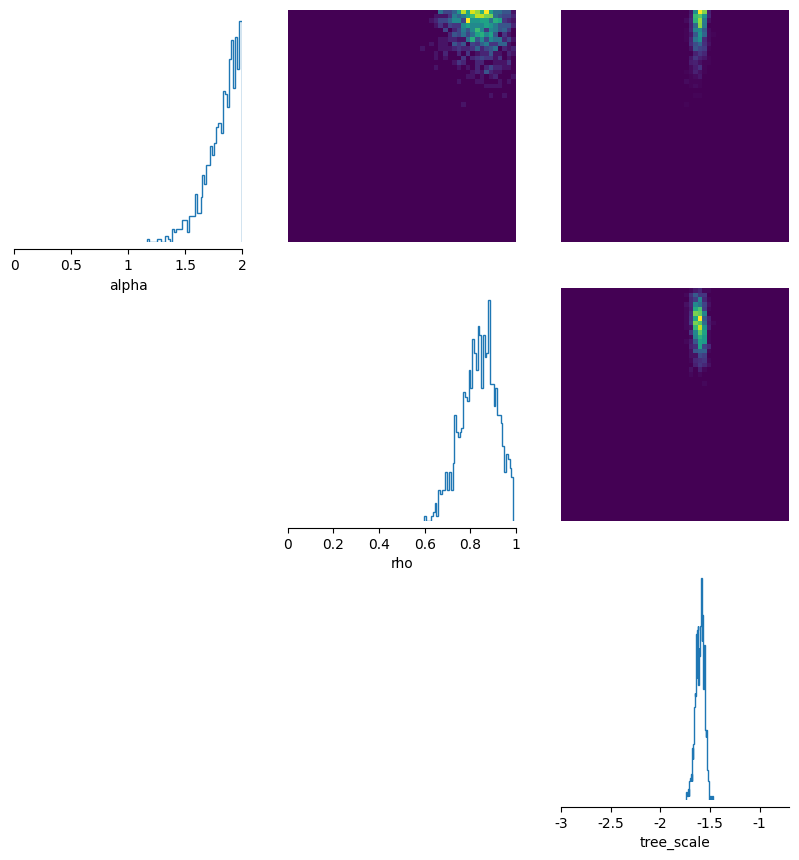

In [24]:
#infer posterior for empirical MSA
x_empirical = torch.tensor(list(empirical_features.values()), dtype=torch.float32)
empirical_posterior_samples = posterior.sample((1000,), x=x_empirical)
print("Empirical posterior samples:", empirical_posterior_samples.median(0))

_ = pairplot(empirical_posterior_samples.numpy(),
              limits=[[0, 2], [0, 1], [np.log10(0.001), np.log10(0.2)]],
              labels=["alpha", "rho", "tree_scale"], show_titles=True)